# Datathon Project  
### 앱의 성공 공식 - 다운로드, 평점, 업데이트, 가격 정책으로 보는 진짜 성공 요인

#### 팀명: 데이터덕후들
#### 데이터셋: Google-Playstore.csv

#### 분석 목표
앱의 **다운로드 수(Installs)**, **평점(Rating)**, **업데이트/가격 정책**을 중심으로 성공 앱의 공통적인 패턴을 찾고, 카테고리 및 앱 특성에 따른 성공/비성공 요인을 도출한다.

---

#### 1. 전처리 파이프라인 개요
1. 데이터 로드 및 기본 정보 확인 후 분석에 불필요한 컬럼 제거
2. 타깃 변수(Rating, Installs) 결측 제거  
3. Installs 문자열 → 정수형 변환 및 로그/구간 파생변수 생성  
4. Size 문자열 → 바이트 단위 숫자(Size_Bytes) 변환  
5. 날짜 컬럼(datetime) 변환 및 앱 나이/업데이트 경과일 파생변수 생성   
6. Boolean 컬럼(Free, Ad, IAP, Editors Choice) → 0/1 변환  
7. 가격/수익화 관련 파생변수 생성 (Price_clean, is_free, has_ads 등)  
8. 이상치 점검 (시각화로 함께 검토) 및 중간 점검
9. 추가 파생변수 생성 (평점/설치/사이즈/업데이트 빈도/참여도 등)  
10. 중복 제거(App Id 기준)  
11. 데이터 품질 검증 및 1단계 csv 파일 저장

#### 2. 테마별 EDA 시행 (필요 시 추가 Feature Engineering)

#### 3. 머신러닝 분석
 
---

In [342]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지


# 🔹 맥북용 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'  # 맥 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 깨짐 방지

print("✅ 한글 폰트 설정 완료: AppleGothic")

print("라이브러리 로드 완료")


✅ 한글 폰트 설정 완료: AppleGothic
라이브러리 로드 완료


In [343]:
df_raw = pd.read_csv('Google-Playstore.csv')

In [344]:
df = df_raw.copy()

In [345]:
df.head()

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,...,Developer Website,Developer Email,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,0.0,...,https://beniyizibyose.tk/#/,jean21101999@gmail.com,"Feb 26, 2020","Feb 26, 2020",Everyone,https://beniyizibyose.tk/projects/,False,False,False,2021-06-15 20:19:35
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,0.0,...,https://webserveis.netlify.app/,webserveis@gmail.com,"May 21, 2020","May 06, 2021",Everyone,https://dev4phones.wordpress.com/licencia-de-uso/,True,False,False,2021-06-15 20:19:35
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,0.0,...,NaN,vnacrewit@gmail.com,"Aug 9, 2019","Aug 19, 2019",Everyone,https://www.vietnamairlines.com/vn/en/terms-an...,False,False,False,2021-06-15 20:19:35
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,0.0,...,http://www.climatesmarttech.com/,climatesmarttech2@gmail.com,"Sep 10, 2018","Oct 13, 2018",Everyone,NaN,True,False,False,2021-06-15 20:19:35
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,0.0,...,http://www.horodyski.com.pl,rmilekhorodyski@gmail.com,"Feb 21, 2020","Nov 12, 2018",Everyone,http://www.horodyski.com.pl,False,False,False,2021-06-15 20:19:35


---
## 1. 기본 정보 및 결측 요약

In [346]:
df.shape

(2312944, 24)

In [347]:
print("\n=== 데이터 정보 ===")
df.info()

print("\n=== 결측치 개요 ===")
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)
missing_summary


=== 데이터 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2312944 entries, 0 to 2312943
Data columns (total 24 columns):
 #   Column             Dtype  
---  ------             -----  
 0   App Name           object 
 1   App Id             object 
 2   Category           object 
 3   Rating             float64
 4   Rating Count       float64
 5   Installs           object 
 6   Minimum Installs   float64
 7   Maximum Installs   int64  
 8   Free               bool   
 9   Price              float64
 10  Currency           object 
 11  Size               object 
 12  Minimum Android    object 
 13  Developer Id       object 
 14  Developer Website  object 
 15  Developer Email    object 
 16  Released           object 
 17  Last Updated       object 
 18  Content Rating     object 
 19  Privacy Policy     object 
 20  Ad Supported       bool   
 21  In App Purchases   bool   
 22  Editors Choice     bool   
 23  Scraped Time       object 
dtypes: bool(4), float64(4), int64(1), 

,missing_count,missing_percent
Developer Website,760835,32.89
Privacy Policy,420953,18.20
Released,71053,3.07
Rating,22883,0.99
Rating Count,22883,0.99
Minimum Android,6530,0.28
Currency,135,0.01
Size,196,0.01
Editors Choice,0,0.00
In App Purchases,0,0.00


### 1-1. 결측치 처리 방향
결측이 제일 많은 Developer Website, Privacy Policy, Released는 앱 성과지표와의 상관관계가 불분명하므로 우선 처리 후순위로 미루고, 분석에서 사용하지 않을 컬럼은 미리 제거한다.

In [348]:
# 분석에서 사용하지 않기로 한 컬럼 미리 제거
drop_cols = ['Minimum Android', 'Developer Email']
df = df.drop(columns=drop_cols)

print("드랍 후 컬럼 수:", df.shape[1])

드랍 후 컬럼 수: 22


---
## 2. 타깃 변수(Rating, Installs) 결측 제거

In [349]:

before = len(df)
df = df.dropna(subset=["Rating", "Installs"])
after = len(df)
print(f"제거된 행: {before - after:,} ({(before-after)/before*100:.2f}%)")

df.shape


제거된 행: 22,883 (0.99%)


(2290061, 22)

In [350]:
#처리 확인 
(df.isnull().mean()).sort_values(ascending=False)

Developer Website    0.328096
Privacy Policy       0.180868
Released             0.021125
Developer Id         0.000014
Currency             0.000009
App Name             0.000002
Editors Choice       0.000000
In App Purchases     0.000000
Ad Supported         0.000000
Content Rating       0.000000
Last Updated         0.000000
Size                 0.000000
App Id               0.000000
Price                0.000000
Free                 0.000000
Maximum Installs     0.000000
Minimum Installs     0.000000
Installs             0.000000
Rating Count         0.000000
Rating               0.000000
Category             0.000000
Scraped Time         0.000000
dtype: float64

### 2-1. Rating 및 Installs 결측 제거 완료
- 제거 전: 2,312,944행
- 제거 후: 2,290,061행
- 제거된 행: 22,883행 (0.99%)

---
## 3. Installs 문자열 → 정수형 변환 및 로그/구간 파생

In [351]:
df["Installs"].head(10)

0        10+
1     5,000+
2        50+
3        10+
4       100+
5        50+
6     1,000+
7       500+
8        10+
9    50,000+
Name: Installs, dtype: object

In [352]:
# 문자열 정리 
df["Installs"] = (
    df["Installs"]
      .astype(str)
      .str.replace('[+,]', '', regex=True)  # +, , 제거
      .replace("nan", np.nan)
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

#결측치 제거 후 숫자 변환
df = df.dropna(subset=["Installs"])
df["Installs"] = df["Installs"].astype(int)

In [353]:
# Installs 정제 후 통계치
print(df["Installs"].describe())

count    2.290061e+06
mean     1.851085e+05
std      1.520634e+07
min      0.000000e+00
25%      5.000000e+01
50%      5.000000e+02
75%      5.000000e+03
max      1.000000e+10
Name: Installs, dtype: float64


In [354]:
# 로그 변환
df["Installs_log"] = np.log1p(df["Installs"])

In [355]:
# 구간(bin) 파생
bins = [0, 1_000, 10_000, 100_000, 1_000_000, 10_000_000, np.inf]
labels = ["0-1K", "1K-10K", "10K-100K", "100K-1M", "1M-10M", "10M+"]

#연속형 데이터를 구간으로 잘라 범주형으로 변환
df["Installs_bin"] = pd.cut(df["Installs"], bins=bins, labels=labels) 

In [356]:
df.head()

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,...,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time,Installs_log,Installs_bin
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10,10.0,15,True,0.0,...,"Feb 26, 2020","Feb 26, 2020",Everyone,https://beniyizibyose.tk/projects/,False,False,False,2021-06-15 20:19:35,2.397895,0-1K
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,5000,5000.0,7662,True,0.0,...,"May 21, 2020","May 06, 2021",Everyone,https://dev4phones.wordpress.com/licencia-de-uso/,True,False,False,2021-06-15 20:19:35,8.517393,1K-10K
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50,50.0,58,True,0.0,...,"Aug 9, 2019","Aug 19, 2019",Everyone,https://www.vietnamairlines.com/vn/en/terms-an...,False,False,False,2021-06-15 20:19:35,3.931826,0-1K
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10,10.0,19,True,0.0,...,"Sep 10, 2018","Oct 13, 2018",Everyone,NaN,True,False,False,2021-06-15 20:19:35,2.397895,0-1K
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100,100.0,478,True,0.0,...,"Feb 21, 2020","Nov 12, 2018",Everyone,http://www.horodyski.com.pl,False,False,False,2021-06-15 20:19:35,4.615121,0-1K


In [357]:
# 구간파생 분포 확인 
print((df["Installs_bin"].value_counts(normalize=True) * 100).round(2))

Installs_bin
0-1K        71.11
1K-10K      17.49
10K-100K     8.11
100K-1M      2.65
1M-10M       0.56
10M+         0.07
Name: proportion, dtype: float64


---
## 4. Size → Size_Bytes (바이트 단위 숫자) 변환

In [358]:
#size는 현재 문자열 (M, K 섞여있음 또한 콤마 제거 소/대문자/ 단위없는 숫자까리 처리 필요) 이므로 계산 그래프가 가능하도록 숫자 (단위 byte)로 변환 

# size는 현재 문자열 (M, k, 콤마 섞여있음) → 계산 가능하도록 byte 단위 숫자로 변환
def size_to_bytes(x):
    # 0) NaN / None이면 바로 NaN
    if pd.isna(x):
        return np.nan

    # 1) 문자열이 아니어도 일단 문자열로 변환
    x = str(x).strip()

    # 2) 콤마/공백 제거 (예: '1,019k', ' 2.5M ')
    x = x.replace(',', '').replace(' ', '')

    # 3) 'M' (메가바이트)로 끝나는 경우
    if x.endswith(('M', 'm')):
        try:
            # '19M' → '19' → float(19) * 1,000,000
            return float(x[:-1]) * 1_000_000
        except ValueError:
            return np.nan

    # 4) 'k' 혹은 'K' (킬로바이트)로 끝나는 경우
    if x.endswith(('k', 'K')):
        try:
            # '580k' → '580' → float(580) * 1,000
            return float(x[:-1]) * 1_000
        except ValueError:
            return np.nan

    # 5) 단위가 없지만 숫자처럼 생긴 경우 (예: '1024')
    try:
        return float(x)
    except ValueError:
        # 6) 그 외 문자열 (Varies with device 등)은 NaN
        return np.nan

# 7) 새로 함수 적용해서 다시 생성 (덮어쓰기)
df['Size_Bytes'] = df['Size'].apply(size_to_bytes)

In [359]:
#단위 통일 변환 처리 검증
df[['Size','Size_Bytes']].head(20)

,Size,Size_Bytes
0,10M,10000000.0
1,2.9M,2900000.0
2,3.7M,3700000.0
3,1.8M,1800000.0
4,6.2M,6200000.0
5,46M,46000000.0
6,2.5M,2500000.0
7,16M,16000000.0
8,1.3M,1300000.0
9,3.5M,3500000.0


In [360]:
df['Size_Bytes'].describe()

count    2.237000e+06
mean     1.919658e+07
std      2.387836e+07
min      3.200000e+03
25%      4.900000e+06
50%      1.000000e+07
75%      2.500000e+07
max      1.020000e+09
Name: Size_Bytes, dtype: float64

In [361]:
#결측치 확인
print(df['Size_Bytes'].isnull().sum()) #결측치 수 
print(df['Size_Bytes'].isnull().mean() * 100) #결축율 2.3%

53061
2.3170125162604838


In [362]:
df[df['Size_Bytes'].isnull()]['Size'].value_counts().head(20)

Size
Varies with device    53048
1.1G                      8
1.0G                      3
1.5G                      2
Name: count, dtype: int64

In [363]:
df[df['Size_Bytes'].isnull()][['Size']].sample(20)

,Size
2112710,Varies with device
318803,Varies with device
1666219,Varies with device
2203453,Varies with device
794845,Varies with device
1361841,Varies with device
1957201,Varies with device
1078165,Varies with device
729438,Varies with device
206344,Varies with device


In [364]:
# 위에 행들은 NaN으로 두고 size 피처로 사용 시 분석에서 제외함 - 전체 데이터에서 2.3% 수준이므로 영향 미미할 것으로 판단 
df_size = df.dropna(subset=['Size_Bytes'])

In [365]:
print(df['Size'].isnull().sum())

0


In [366]:
df[['Size','Size_Bytes']].head(20)

,Size,Size_Bytes
0,10M,10000000.0
1,2.9M,2900000.0
2,3.7M,3700000.0
3,1.8M,1800000.0
4,6.2M,6200000.0
5,46M,46000000.0
6,2.5M,2500000.0
7,16M,16000000.0
8,1.3M,1300000.0
9,3.5M,3500000.0


### 4-1. Size 변환 완료
Size는 bytes 단위로 통일하여 숫자형으로 변환한 Size_bytes를 생성하였다. 숫자로 변환할 수 없는 문자열 형태의 행들은 NaN으로 처리하여 분석에서 제외하였다.

---
## 5. 날짜 컬럼 처리 및 앱 나이/업데이트 경과일 파생

In [367]:
# 5. 날짜 컬럼을 datetime 으로 변환
date_cols = ['Released', 'Last Updated', 'Scraped Time']

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# 5-1. 앱 나이 (출시 후 경과 일수)
if {'Scraped Time', 'Released'}.issubset(df.columns):
    df['app_age_days'] = (df['Scraped Time'] - df['Released']).dt.days
    # 잘못된 음수 값은 NaN 처리
    df.loc[df['app_age_days'] < 0, 'app_age_days'] = np.nan

# 5-2. 업데이트 방치 기간 (마지막 업데이트 이후 경과 일수)
if {'Scraped Time', 'Last Updated'}.issubset(df.columns):
    df['days_since_update'] = (df['Scraped Time'] - df['Last Updated']).dt.days
    df.loc[df['days_since_update'] < 0, 'days_since_update'] = np.nan

# 간단히 확인
df[['Released', 'Last Updated', 'Scraped Time', 'app_age_days', 'days_since_update']].head()

,Released,Last Updated,Scraped Time,app_age_days,days_since_update
0,2020-02-26,2020-02-26,2021-06-15 20:19:35,475.0,475.0
1,2020-05-21,2021-05-06,2021-06-15 20:19:35,390.0,40.0
2,2019-08-09,2019-08-19,2021-06-15 20:19:35,676.0,666.0
3,2018-09-10,2018-10-13,2021-06-15 20:19:35,1009.0,976.0
4,2020-02-21,2018-11-12,2021-06-15 20:19:35,480.0,946.0


In [368]:
df[['app_age_days', 'days_since_update']].describe()

,app_age_days,days_since_update
count,2.241683e+06,2.290061e+06
mean,1.020940e+03,5.587255e+02
std,7.736866e+02,5.561051e+02
min,0.000000e+00,0.000000e+00
25%,4.260000e+02,1.310000e+02
50%,8.180000e+02,3.960000e+02
75%,1.444000e+03,7.910000e+02
max,4.157000e+03,4.510000e+03


### 5-1. 날짜 변수 처리 및 파생변수 생성
`Released`, `Last Updated`, `Scraped Time`을 `datetime` 타입으로 변환하였다.  
- `Scraped Time - Released` → `app_age_days` (앱 출시 이후 경과 일수)  
- `Scraped Time - Last Updated` → `days_since_update` (마지막 업데이트 이후 경과 일수)  
- 날짜 계산 과정에서 잘못된 음수 값은 데이터 오류로 보고 `NaN` 처리

**파생 변수의 활용**  
앱 나이 `app_age_days`와 업데이트 방치 기간 `days_since_update`는 이후 EDA에서 오래된 앱 vs 최근 앱, 업데이트를 자주 하는 앱 vs 방치된 앱의 다운로드 및 평점 차이를 비교할 수 있는 기반으로 사용한다.

---
## 6. Boolean 및 범주형 컬럼 정리
Currency 통화코드 중 이상치(XXX)가 발견되어 처리하였다(나중에 가격 계산 시 문제가 될 수 있음). Boolean 컬럼 4개를 모두 0/1로 통일하여 집계 및 모델링 시 사용하기 편한 형태로 만들었고, 주요 문자열 컬럼을 `category`로 변환하여 대용량 데이터에서도 분석 속도가 개선될 수 있도록 하였다.

In [369]:
df['Currency'].head(30)

0     USD
1     USD
2     USD
3     USD
4     USD
5     USD
6     USD
7     USD
8     USD
9     USD
10    USD
11    USD
12    USD
13    USD
14    USD
15    USD
16    USD
17    USD
18    USD
19    XXX
20    USD
21    USD
22    USD
23    USD
24    USD
25    USD
26    USD
27    USD
28    USD
29    USD
Name: Currency, dtype: object

In [370]:
# 6. Currency 이상치(XXX) 처리 + Boolean / 범주형 정리

# 6-0. Currency를 일단 object로 풀어두기 (category였으면 에러 방지)
if 'Currency' in df.columns:
    df['Currency'] = df['Currency'].astype('object')

    # 6-0-1. Price = 0 & Currency = 'XXX' → 'Free' 로 변경
    mask_free = (df['Currency'] == 'XXX') & (df['Price'] == 0)
    df.loc[mask_free, 'Currency'] = 'Free'

    # 6-0-2. Price > 0 & Currency = 'XXX' → 'Unknown' 으로 태깅
    mask_unknown = (df['Currency'] == 'XXX') & (df['Price'] > 0)
    df.loc[mask_unknown, 'Currency'] = 'Unknown'

    # (선택) 변경 결과 확인하고 싶으면:
    # print(df['Currency'].value_counts())

# 6-1. Boolean 컬럼 → 0/1 (int)로 통일
bool_cols = ['Free', 'Ad Supported', 'In App Purchases', 'Editors Choice']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(int)

# 6-2. 주요 범주형 컬럼은 category 타입으로 변경 (Currency는 이상치 정리 후 변환)
cat_cols = ['Category', 'Content Rating', 'Currency']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# 확인
df[bool_cols + [c for c in cat_cols if c in df.columns]].head(30)

,Free,Ad Supported,In App Purchases,Editors Choice,Category,Content Rating,Currency
0,1,0,0,0,Adventure,Everyone,USD
1,1,1,0,0,Tools,Everyone,USD
2,1,0,0,0,Productivity,Everyone,USD
3,1,1,0,0,Communication,Everyone,USD
4,1,0,0,0,Tools,Everyone,USD
5,1,0,1,0,Social,Teen,USD
6,1,1,0,0,Libraries & Demo,Everyone,USD
7,1,0,0,0,Lifestyle,Everyone,USD
8,1,0,0,0,Communication,Teen,USD
9,1,1,0,0,Personalization,Everyone,USD


In [371]:
#통화정보 요약
df['Currency'].value_counts()

Currency
USD     2288801
Free       1217
EUR           6
INR           5
GBP           3
CAD           2
AUD           1
BRL           1
KRW           1
SGD           1
TRY           1
VND           1
ZAR           1
Name: count, dtype: int64

### 6-1. Boolean 및 범주형 변수 정리 완료
- Currency 이상값을 의미있는 값으로 변환하였다(가격정보와 매칭하여 처리)
- `Free`, `Ad Supported`, `In App Purchases`, `Editors Choice`는 True/False 대신 **0/1 정수형**으로 통일  
- `Category`, `Content Rating`, `Currency`는 문자열이 반복되는 범주형이라 **`category` 타입으로 변환**하여 메모리 사용을 줄여 분석 속도에 도움이 되도록 하였다.

---
## 7. 가격 및 수익화 관련 파생변수 생성
가격의 경우 통화 기호를 제거하고 숫자형으로 변환이 필요하다. 무료 여부, 광고 여부, 인앱 결제 유무 등은 평점 및 다운로드 차이에 영향을 줄 수 있는 변수들이므로 0/1 변수로 정리해 둔다.

In [372]:
# 7-1. Price 문자열 정리 → 숫자형 Price_clean
if 'Price' in df.columns:
    df['Price_clean'] = (
        df['Price']
        .astype(str)
        .str.replace('[$₩€£]', '', regex=True)  # 통화기호 제거
        .replace('nan', '0')
    )
    df['Price_clean'] = pd.to_numeric(df['Price_clean'], errors='coerce').fillna(0)

# 7-2. 무료 여부 is_free (중복이지만 해석 편의를 위해 별도 생성)
if 'Free' in df.columns:
    df['is_free'] = df['Free'].astype(int)
elif 'Price_clean' in df.columns:
    df['is_free'] = (df['Price_clean'] == 0).astype(int)

# 7-3. 광고 / 인앱결제 / 에디터추천 여부 파생
mapping_cols = [
    ('Ad Supported', 'has_ads'),
    ('In App Purchases', 'has_iap'),
    ('Editors Choice', 'is_editors_choice')
]

for src, new in mapping_cols:
    if src in df.columns:
        df[new] = df[src].astype(int)

df[['Price', 'Price_clean', 'is_free'] + [m[1] for m in mapping_cols if m[0] in df.columns]].head(30)

,Price,Price_clean,is_free,has_ads,has_iap,is_editors_choice
0,0.0,0.0,1,0,0,0
1,0.0,0.0,1,1,0,0
2,0.0,0.0,1,0,0,0
3,0.0,0.0,1,1,0,0
4,0.0,0.0,1,0,0,0
5,0.0,0.0,1,0,1,0
6,0.0,0.0,1,1,0,0
7,0.0,0.0,1,0,0,0
8,0.0,0.0,1,0,0,0
9,0.0,0.0,1,1,0,0


In [373]:
cols = ['is_free', 'has_ads', 'has_iap', 'is_editors_choice']

In [374]:
df[cols].apply(lambda x: x.value_counts(normalize=True)).round(5)

,is_free,has_ads,has_iap,is_editors_choice
0,0.01958,0.50048,0.91583,0.99963
1,0.98042,0.49952,0.08417,0.00037


### 7-1. 수익화 변수 분포 확인
- 유료 앱은 단 2%, 무료 앱이 98%로 앱 시장은 대부분 무료 기반이다
- 광고가 있는 앱과 없는 앱은 반반 비율이다
- 인앱결제 기능이 대부분 없고(91.6%) 있는 것은 8.4% 정도이다
- 에디터 초이스 앱은 전체 데이터 중 0.04% 수준으로 극소수 앱에만 해당되며 거의 없는 수준이다

---
## 8. 중간 점검

In [376]:
#중간 과정에서 생성된 전체 컬럼 다시 한번 점검
# count 는 NaN 제외한 행수 , unique는 서로 다른 값들이 몇종있는지, top은 문자형 컬럼 중 최빈값, freq도 문자형 컬럼에서 최빈값이 몇번 등장했는지
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
App Name,2290056,2157096,Tic Tac Toe,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
App Id,2290061,2290061,com.ishakwe.gakondo,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,2290061,48,Education,239786,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,2290061.0,NaN,NaN,NaN,2.203152,0.0,0.0,2.9,4.3,5.0,2.106223
Rating Count,2290061.0,NaN,NaN,NaN,2864.838877,0.0,0.0,6.0,42.0,138557570.0,212162.571036
Installs,2290061.0,NaN,NaN,NaN,185108.491531,0.0,50.0,500.0,5000.0,10000000000.0,15206338.268191
Minimum Installs,2290061.0,NaN,NaN,NaN,185108.491531,0.0,50.0,500.0,5000.0,10000000000.0,15206338.268191
Maximum Installs,2290061.0,NaN,NaN,NaN,323040.881552,0.0,86.0,710.0,7477.0,12057627016.0,23671292.743131
Price,2290061.0,NaN,NaN,NaN,0.104377,0.0,0.0,0.0,0.0,400.0,2.645935
Currency,2290041,13,USD,2288801,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 9. 이상치 점검

In [377]:
#Rating 이상치 (0-5 벗어난 값)
df[(df['Rating'] < 0) | (df['Rating'] > 5)]

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Price,Currency,...,Installs_log,Installs_bin,Size_Bytes,app_age_days,days_since_update,Price_clean,is_free,has_ads,has_iap,is_editors_choice


In [378]:
# --- Rating Count 이상치 논리 점검 (설치수 대비 리뷰 수가 더 많은지) ---

# 논리상 Rating Count > Installs 는 있을 수 없음
invalid_reviews = df[df['Rating Count'] > df['Installs']]

print("설치수보다 리뷰가 많은 앱 수:", len(invalid_reviews))

# 존재한다면 → 데이터 오류로 판단하여 NaN 처리 또는 제거
if len(invalid_reviews) > 0:
    print("⚠️ 논리적 이상치 발견 → Rating Count 값을 NaN 처리합니다.")
    df.loc[df['Rating Count'] > df['Installs'], 'Rating Count'] = np.nan

# 처리 후 최종 점검
print(df['Rating Count'].describe())

설치수보다 리뷰가 많은 앱 수: 4950
⚠️ 논리적 이상치 발견 → Rating Count 값을 NaN 처리합니다.
count    2.285111e+06
mean     2.870476e+03
std      2.123918e+05
min      0.000000e+00
25%      0.000000e+00
50%      6.000000e+00
75%      4.200000e+01
max      1.385576e+08
Name: Rating Count, dtype: float64


In [379]:
#Installs 이상치 (음수 등)
df[df['Installs'] < 0]

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Price,Currency,...,Installs_log,Installs_bin,Size_Bytes,app_age_days,days_since_update,Price_clean,is_free,has_ads,has_iap,is_editors_choice


In [380]:
#너무 튀는 극단값 유무
df['Installs'].max()

10000000000

In [381]:
df['Installs'].quantile([0.99, 0.995, 0.999, 0.9999])

0.9900      1000000.0
0.9950      5000000.0
0.9990     10000000.0
0.9999    100000000.0
Name: Installs, dtype: float64

In [382]:
# 옵션: Installs 클리핑한 거 컬럼 추가 (원본 보존)
# EDA에서 인스톨 분포를 보기 좋게 만들 때만 사용하기
cap = df['Installs'].quantile(0.9999)
df['Installs_clipped'] = df['Installs'].clip(upper=cap)

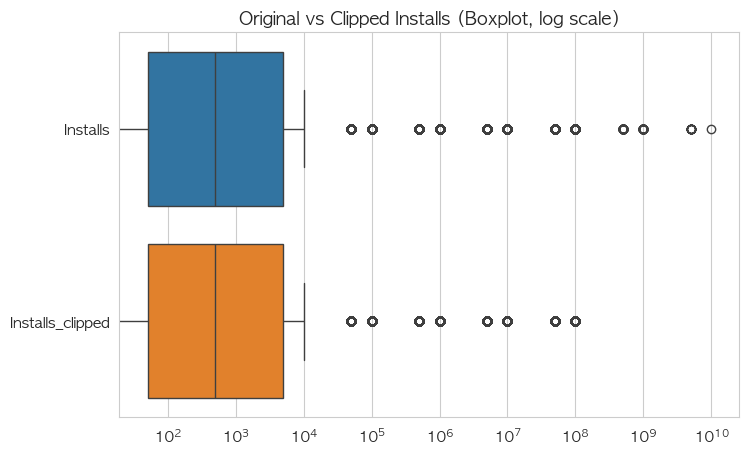

In [383]:
#boxplot으로 인스톨 값 이상치 점검
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Installs','Installs_clipped']], orient='h')
plt.xscale('log')
plt.title("Original vs Clipped Installs (Boxplot, log scale)")
plt.show()

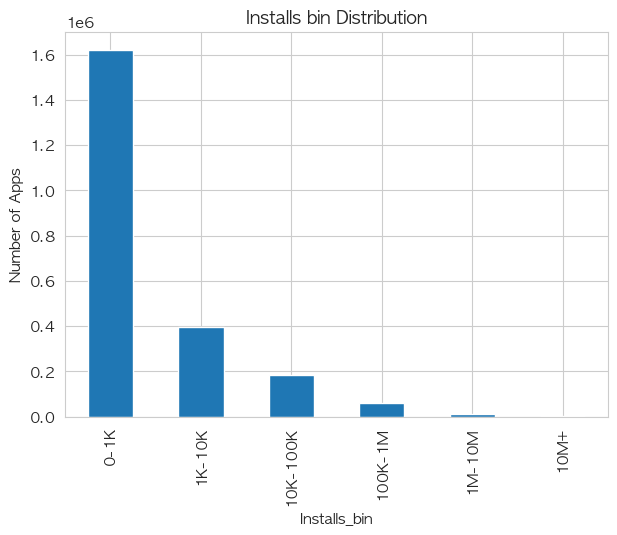

In [384]:
##구간별 Installs_bin 분포 확인
df['Installs_bin'].value_counts().sort_index().plot(kind='bar', figsize=(7,5))
plt.title("Installs bin Distribution")
plt.ylabel("Number of Apps")
plt.show()

In [385]:
#install 구간 분포율
(df['Installs_bin'].value_counts(normalize=True) * 100).round(2)

Installs_bin
0-1K        71.11
1K-10K      17.49
10K-100K     8.11
100K-1M      2.65
1M-10M       0.56
10M+         0.07
Name: proportion, dtype: float64

### 9-1. Installs 데이터 패턴 분석
앱 시장은 극단적 롱테일 구조다. 전체 앱의 71%가 0-1K 구간(1,000 다운로드 이하)에 집중되어 있다.
- 전체 앱의 99%는 설치 수가 100만 미만이다
- 상위 0.1%만 천만+ 다운로드를 기록한다
- 상위 0.01%만 1억+ 다운로드를 기록한다

**다음 단계에서 고려할 점**
- 극단값의 영향력을 줄이기 위해 Install_log를 유지한다
- Install 원본은 EDA 시장구조 설명용으로만 사용하고, 모델 입력값은 로그변환값을 사용한다
- 참고사항:
  - `Installs_log` → 분석 및 모델용 숫자 스케일 안정화
  - `Installs_bin` → 각 구간이 몇 %인지 설명용 수치 및 막대그래프
  - `Installs_clipped` → 그래프가 덜 찌그러지게 해주는 시각화용 버전

In [386]:
#Price_clean 음수 또는 터무니없이 큰 값 파악
df[df['Price_clean'] > 200][['App Name', 'Price_clean']].head()

,App Name,Price_clean
20127,TEST EGY,399.99
63733,1800secs,209.99
203217,MOST EXPENSIVE FALLING GAME,264.99
242559,NEET PG/NEXT Question Bank,349.99
268776,Taxes,399.99


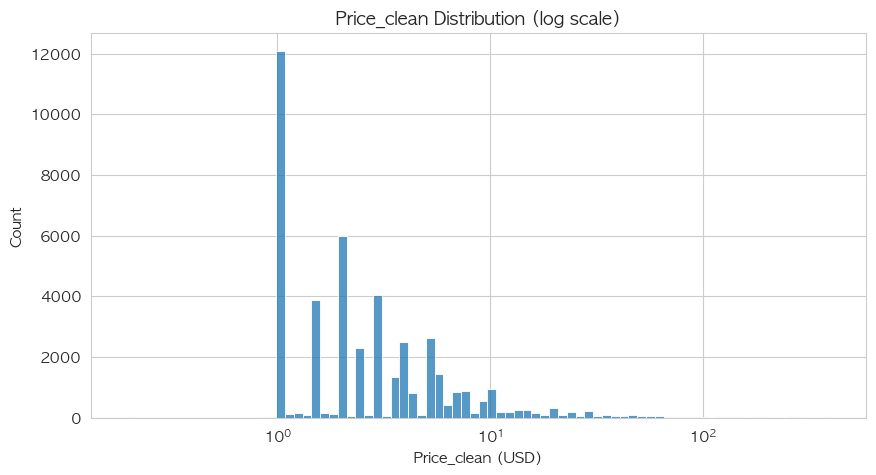

In [387]:
# 가격분포 - 로그 스케일 히스토그램 
plt.figure(figsize=(10,5))
sns.histplot(df['Price_clean'], bins=80, log_scale=True)
plt.title("Price_clean Distribution (log scale)")
plt.xlabel("Price_clean (USD)")
plt.ylabel("Count")
plt.show()

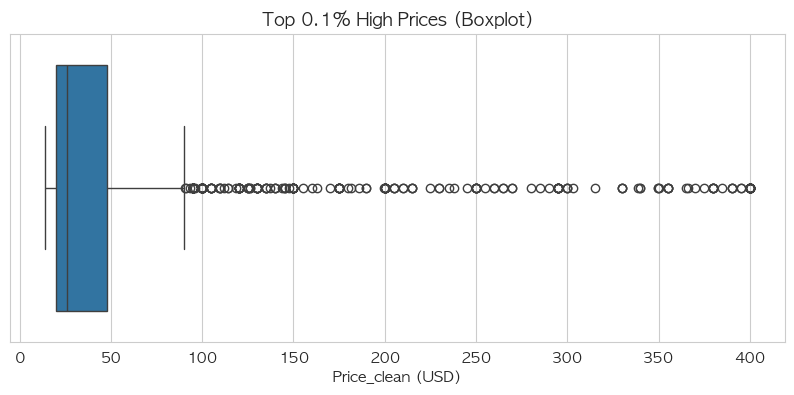

In [388]:
# 가격 상위값 집중 보기
top_price = df[df['Price_clean'] > df['Price_clean'].quantile(0.999)]

plt.figure(figsize=(10,4))
sns.boxplot(x=top_price['Price_clean'])
plt.title("Top 0.1% High Prices (Boxplot)")
plt.xlabel("Price_clean (USD)")
plt.show()

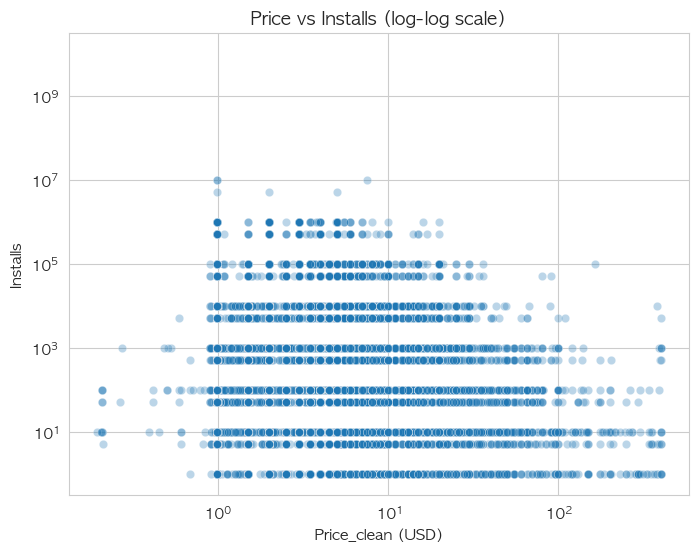

In [389]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Price_clean'], y=df['Installs'], alpha=0.3)
plt.yscale('log')
plt.xscale('log')
plt.title("Price vs Installs (log-log scale)")
plt.xlabel("Price_clean (USD)")
plt.ylabel("Installs")
plt.show()

### 9-2. 가격 데이터 패턴 분석
가격 데이터는 오른쪽 꼬리(롱테일 분포)를 보이며 압도적인 저가 시장 구조를 나타낸다.
- 앱 가격에서 일부 고가 전략을 취하는 앱들이 보이며 outlier가 아니라 시장 분리 현상으로 생각된다(다운로드 수가 적은 틈새 시장 가능성)
- 구글플레이 개발자 정책에 따르면 가격은 국가/통화별로 상한이 다르나, 미국 최대가격은 약 $399.99까지 허용된다. 해당 앱들은 주로 교육, 의료, 전문직 시장 앱들로 확인되었다
- 가격이 올라갈수록 설치수는 떨어지는 역상관 관계를 보인다

In [390]:
#Rating Count 이상치 점검
df['Rating Count'].describe()

count    2.285111e+06
mean     2.870476e+03
std      2.123918e+05
min      0.000000e+00
25%      0.000000e+00
50%      6.000000e+00
75%      4.200000e+01
max      1.385576e+08
Name: Rating Count, dtype: float64

In [391]:
(df['Rating Count'] > df['Installs']).sum()

np.int64(0)

In [392]:
df['Rating Count'].quantile([0.99, 0.995, 0.999, 0.9999])

0.9900    2.155600e+04
0.9950    5.667180e+04
0.9990    3.672424e+05
0.9999    3.120357e+06
Name: Rating Count, dtype: float64

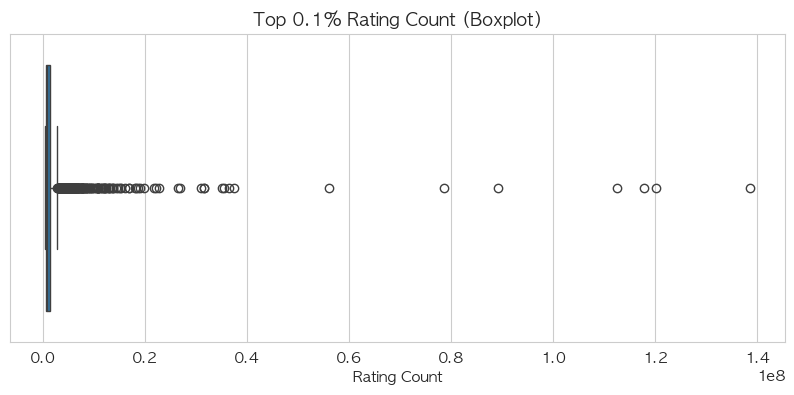

In [393]:
# 박스플롯으로 분포 보기
top_rc = df[df['Rating Count'] > df['Rating Count'].quantile(0.999)]

plt.figure(figsize=(10,4))
sns.boxplot(x=top_rc['Rating Count'])
plt.title("Top 0.1% Rating Count (Boxplot)")
plt.xlabel("Rating Count")
plt.show()

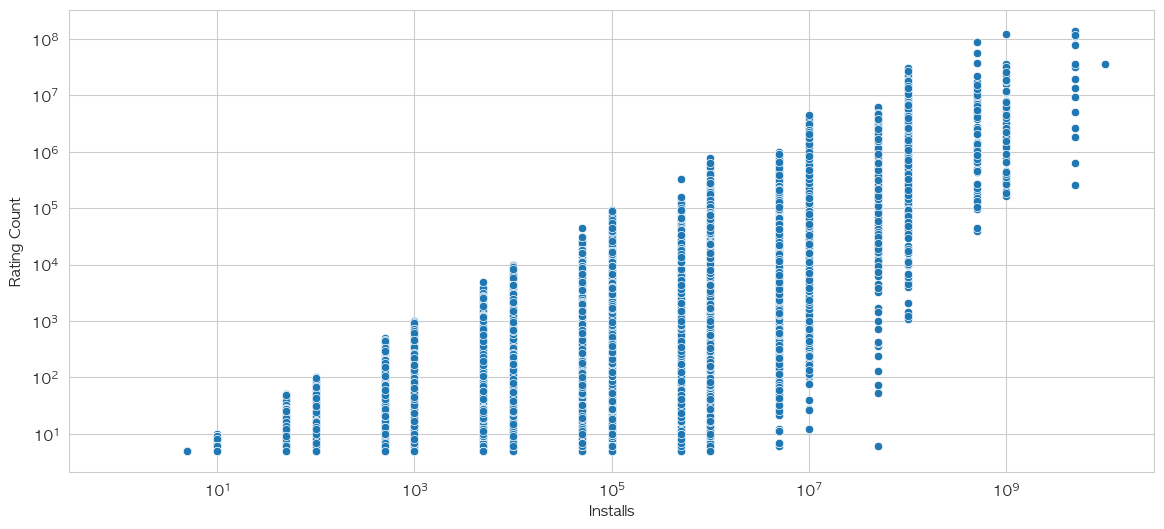

In [394]:
sns.scatterplot(x=df['Installs'], y=df['Rating Count'])
plt.xscale('log')
plt.yscale('log')

### 9-3. 평점 리뷰수와 다운로드 상관관계
평점 리뷰수와 다운로드 상관관계는 명확한 우상향 구조를 보인다. 설치수보다 리뷰가 많은 앱은 없으므로 이상치는 발견되지 않았다.

In [395]:
#날짜 기반 이상치 점검
df[df['app_age_days'] < 0]

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Price,Currency,...,Installs_bin,Size_Bytes,app_age_days,days_since_update,Price_clean,is_free,has_ads,has_iap,is_editors_choice,Installs_clipped


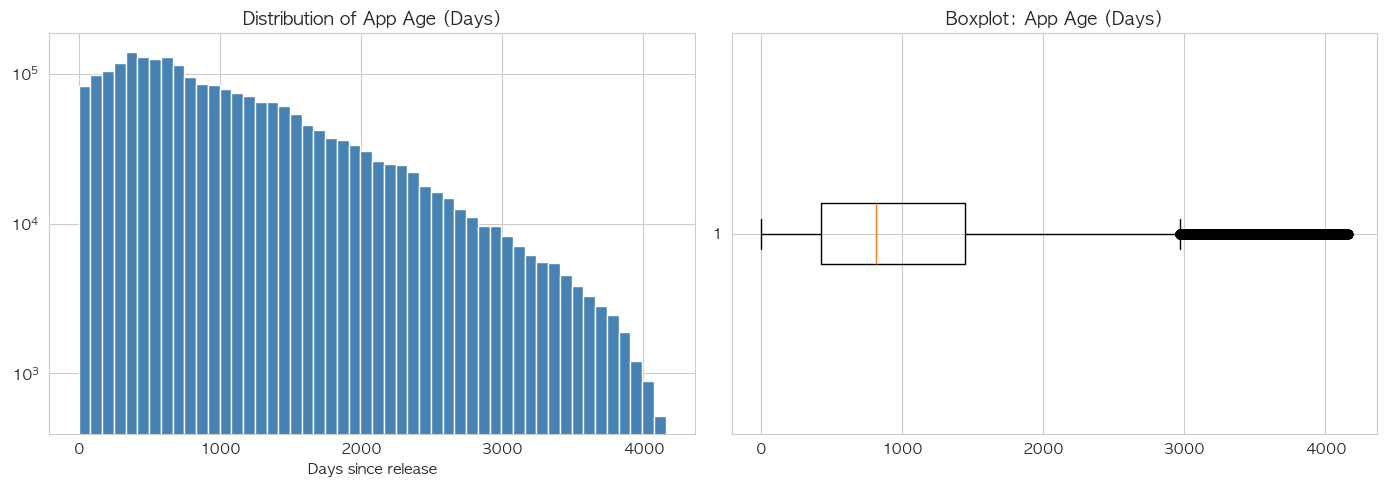

In [396]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Histogram (로그 스케일)
axes[0].hist(df['app_age_days'].dropna(), bins=50, color='steelblue')
axes[0].set_title("Distribution of App Age (Days)")
axes[0].set_xlabel("Days since release")
axes[0].set_yscale('log')

# Boxplot
axes[1].boxplot(df['app_age_days'].dropna(), vert=False)
axes[1].set_title("Boxplot: App Age (Days)")

plt.tight_layout()
plt.show()

### 9-4. 앱 나이(app_age_days) 분포
중앙값이 약 800일 수준이며, 오른쪽 꼬리가 길수록 오래된 앱이 많다는 것을 의미한다. 0과 매우 작은 값이 몰려있는 것은 출시일 오류 또는 최근 출시 앱 몰림 현상을 의미한다.

In [397]:
df[df['days_since_update'] < 0]

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Price,Currency,...,Installs_bin,Size_Bytes,app_age_days,days_since_update,Price_clean,is_free,has_ads,has_iap,is_editors_choice,Installs_clipped


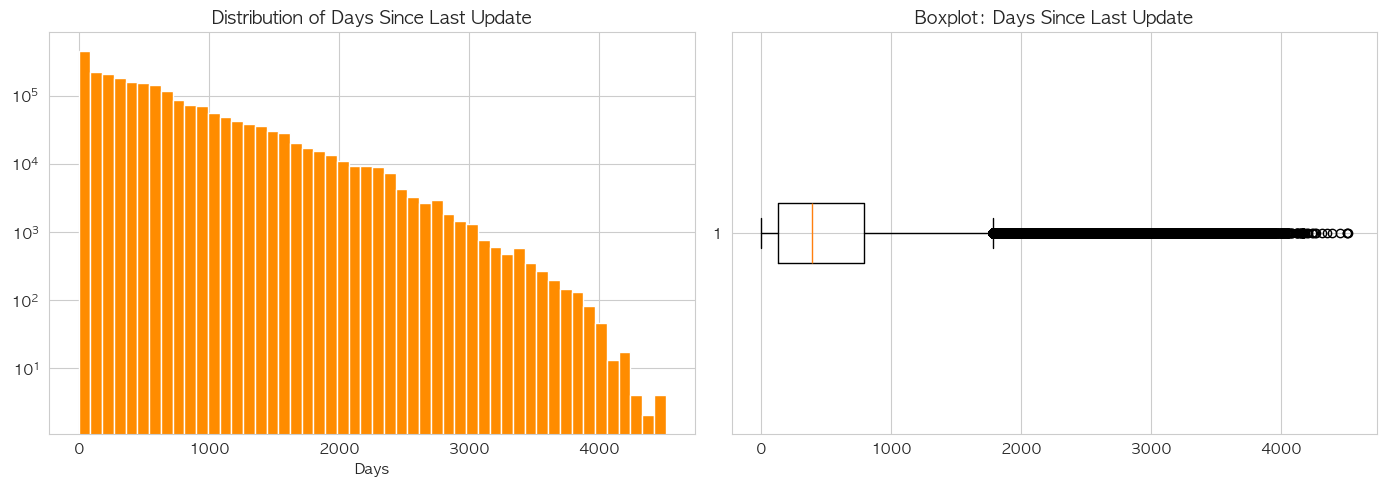

In [398]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Histogram (로그 스케일)
axes[0].hist(df['days_since_update'].dropna(), bins=50, color='darkorange')
axes[0].set_title("Distribution of Days Since Last Update")
axes[0].set_xlabel("Days")
axes[0].set_yscale('log')

# Boxplot
axes[1].boxplot(df['days_since_update'].dropna(), vert=False)
axes[1].set_title("Boxplot: Days Since Last Update")

plt.tight_layout()
plt.show()

### 9-5. 업데이트 경과일(days_since_update) 분포
최근 6개월 이내 업데이트한 앱들이 많다(왼쪽에 몰림). 수천일간 업데이트하지 않은 앱들은 방치된 앱들일 가능성이 높다. 극단적으로 큰 값(3,000-4,500일: 8-12년간 업데이트 없음)은 플랫폼 정책상 이런 앱은 보이기 힘들기 때문에 데이터 오류 또는 방치일 가능성이 있다. EDA에서 별도 필터링 또는 태깅이 필요하다(예: is_abandoned = days_since_update > 365*3).

In [399]:
#통화 값 이상치
df['Currency'].value_counts()

Currency
USD     2288801
Free       1217
EUR           6
INR           5
GBP           3
CAD           2
AUD           1
BRL           1
KRW           1
SGD           1
TRY           1
VND           1
ZAR           1
Name: count, dtype: int64

In [400]:
# 카테고리 컬럼 빈공백이나 이상한 값 확인 
df[df['Category'].isin(['', ' ', None])]

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Price,Currency,...,Installs_bin,Size_Bytes,app_age_days,days_since_update,Price_clean,is_free,has_ads,has_iap,is_editors_choice,Installs_clipped


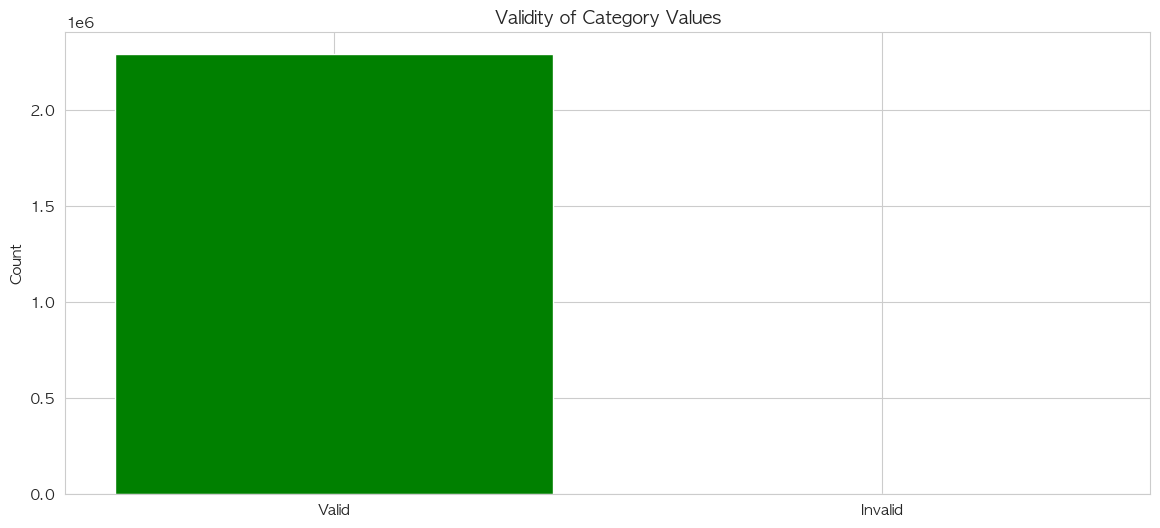

In [401]:
#잘못된 값 누락 여부 확인

invalid = df['Category'].isin(['', ' ', None]).sum()

plt.bar(['Valid', 'Invalid'], [len(df) - invalid, invalid], color=['green', 'red'])
plt.title("Validity of Category Values")
plt.ylabel("Count")
plt.show()

### 9-6. 결측 및 비정상 값 점검
결측 및 비정상 값 문제는 발견되지 않았다.

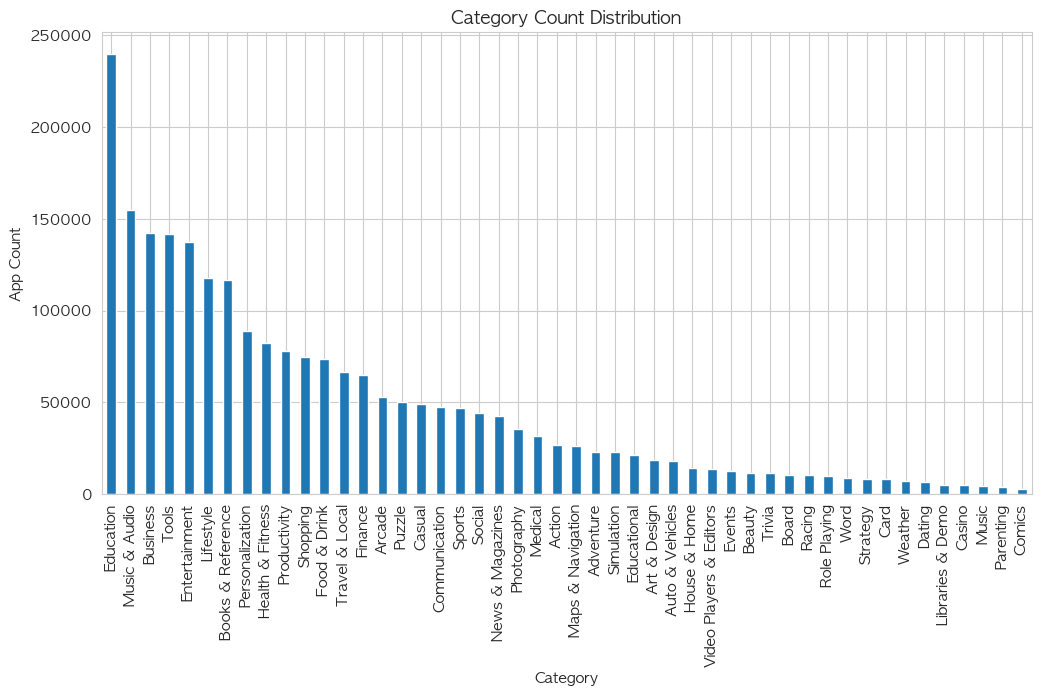

In [402]:
# 카테고리 분포 확인
plt.figure(figsize=(12, 6))
df['Category'].value_counts().plot(kind='bar')
plt.title("Category Count Distribution")
plt.xlabel("Category")
plt.ylabel("App Count")
plt.show()

### 9-7. 앱 카테고리 분포
상위 몇 개 카테고리가 전체 앱의 절반 이상을 차지하며, 극소수 카테고리도 존재한다. 희귀 카테고리는 나중에 모델링에서 One-hot Encoding 시 문제가 될 수 있다. 대부분 0으로 채워진 컬럼은 모델 학습 기여도가 거의 없고, 48개 카테고리의 원-핫 생성 시 48개 컬럼이 생성되어 메모리 폭발 가능성이 있으며, 소수 카테고리에 집중하면 과적합 가능성도 증가한다.

---
### 주요 변수들 이상치 점검 완료

---
## 10. 추가 파생 변수 생성
평점 구간, 사이즈 구간, 사용자 참여도(engagement) 등 분석에 필요한 추가 파생 변수를 생성한다.

In [403]:
# 8. 추가 파생 변수 생성

# 8-1. 평점 구간화
df['rating_category'] = pd.cut(
    df['Rating'],
    bins=[0, 2.0, 3.0, 4.0, 4.5, 5.0],
    labels=['매우낮음(~2)', '낮음(2~3)', '보통(3~4)', '높음(4~4.5)', '매우높음(4.5~5)']
)

# 8-2. 사이즈 구간화
df['size_category'] = pd.cut(
    df['Size_Bytes'],
    bins=[0, 10e6, 50e6, 100e6, float('inf')],
    labels=['소형(~10MB)', '중형(10~50MB)', '대형(50~100MB)', '초대형(100MB+)']
)

# 8-3. 설치수 구간(이미 있지만, 유지)
# df['Installs_bin'] 그대로 사용

# 8-4. 최근 업데이트 여부 (90일 기준)
df['recently_updated'] = (df['days_since_update'] <= 90).astype(int)

# 8-5. 참여도(engagement score): 리뷰 수 / 설치수
df['engagement_score'] = df['Rating Count'] / (df['Installs'] + 1)
df['engagement_score'] = df['engagement_score'].clip(upper=1.0)

---
## 11. 중복 제거 (App Id 기준)

In [404]:
# 9. 중복 제거
before = len(df)
df = df.drop_duplicates(subset=['App Id'], keep='first')
after = len(df)

print(f"중복 제거: {before - after}개 제거 (최종 {after}개)")

중복 제거: 0개 제거 (최종 2290061개)


In [405]:
# 결측 5개행 제거 
df = df.dropna(subset=['App Name'])

---
## 12. 최종 점검

In [406]:
# 10-1. 품질 검증
print(df[['Rating', 'Installs', 'Size_Bytes']].describe())
print(df.isnull().sum().sort_values(ascending=False).head(20))


             Rating      Installs    Size_Bytes
count  2.290056e+06  2.290056e+06  2.236995e+06
mean   2.203148e+00  1.851089e+05  1.919659e+07
std    2.106223e+00  1.520635e+07  2.387838e+07
min    0.000000e+00  0.000000e+00  3.200000e+03
25%    0.000000e+00  5.000000e+01  4.900000e+06
50%    2.900000e+00  5.000000e+02  1.000000e+07
75%    4.300000e+00  5.000000e+03  2.500000e+07
max    5.000000e+00  1.000000e+10  1.020000e+09
rating_category      1059762
Developer Website     751356
Privacy Policy        414195
Size_Bytes             53061
size_category          53061
app_age_days           48378
Released               48378
Installs_bin           11313
engagement_score        4950
Rating Count            4950
Developer Id              32
Currency                  20
Installs_log               0
has_iap                    0
is_editors_choice          0
is_free                    0
Price_clean                0
Installs_clipped           0
days_since_update          0
recently_updated 

### 12-1. 점검 결과
전처리 결과 남아있는 결측들은 문제가 있는 것이 아니라 원본 특성, 파생변수 특성, 분석용 유지 목적 때문이므로 모델링 단계에서 필요한 컬럼만 선택하면 된다.

---
## 전처리 v1 요약

- 분석에 불필요한 컬럼 우선 제거
- Rating, Installs 결측 행 제거 (~1%)
- Installs 문자열(+, ,) 제거 후 정수형 변환
- Installs_log, Installs_bin 생성
- Size → Size_Bytes (byte 단위) 변환
- 날짜 컬럼 datetime 변환 (Released / Last Updated / Scraped Time)
- 앱 나이(app_age_days), 업데이트 경과일(days_since_update) 생성
- Boolean 컬럼 0/1 정수형 통일
- Currency 'XXX' 처리 (Free / Unknown)
- Price_clean, is_free, has_ads, has_iap, is_editors_choice 생성
- 주요 이상치 점검 → 시각화로 이상치 및 데이터 패턴 동시 확인
- 분석에 필요한 파생 변수 생성

---

In [407]:
# 최종 csv 파일 저장
df.to_csv("google_play_preprocessed_v2.csv", index=False, encoding='utf-8-sig')
print("저장 완료 → google_play_preprocessed_v2.csv")

저장 완료 → google_play_preprocessed_v2.csv


---
# 테마별 EDA + Feature Engineering

---

## 테마 1: 카테고리별 성공 요인 분석
**목표:** 카테고리별 평균 Rating과 Installs를 분석하여 성공 요인 파악

**분석 항목:**
- 카테고리별 평균 Rating 비교
- 카테고리별 평균 Installs 비교  
- 카테고리별 앱 개수 분포

**시각화 계획:**
- Bar chart (카테고리 순) - 평균 Rating  
- Bar chart (Rating 평균) - Installs 총합

---

## 테마 2: 평점 구조 및 리뷰 참여도 분석
**목표:** Rating 분포와 Rating Count, Installs의 관계 분석

**분석 항목:**
- Rating 분포 분석
- Rating Count와 Installs의 관계
- Rating과 Installs의 상관관계

**시각화 계획:**
- Histogram (Rating 분포)
- Boxplot (Rating Count)
- Scatter plot (Installs vs Rating Count)

---

In [408]:
df = pd.read_csv('google_play_preprocessed_v2.csv')

### 1-1. 카테고리별 앱 개수 분포

In [409]:
# 카테고리별 앱 개수
category_counts = df['Category'].value_counts()

print("="*70)
print("📱 카테고리별 앱 개수 (전체)")
print("="*70)
print(f"\n총 카테고리 수: {len(category_counts)}개\n")
print("상위 15개 카테고리:")
print(category_counts.head(15))

print("\n하위 5개 카테고리:")
print(category_counts.tail(5))

📱 카테고리별 앱 개수 (전체)

총 카테고리 수: 48개

상위 15개 카테고리:
Category
Education            239786
Music & Audio        154589
Business             142151
Tools                141972
Entertainment        137576
Lifestyle            117764
Books & Reference    116493
Personalization       89012
Health & Fitness      82598
Productivity          78244
Shopping              74753
Food & Drink          73444
Travel & Local        66667
Finance               64730
Arcade                52705
Name: count, dtype: int64

하위 5개 카테고리:
Category
Libraries & Demo    5068
Casino              5035
Music               4143
Parenting           3764
Comics              2821
Name: count, dtype: int64


### 1-2. 카테고리별 평균 Rating 분석

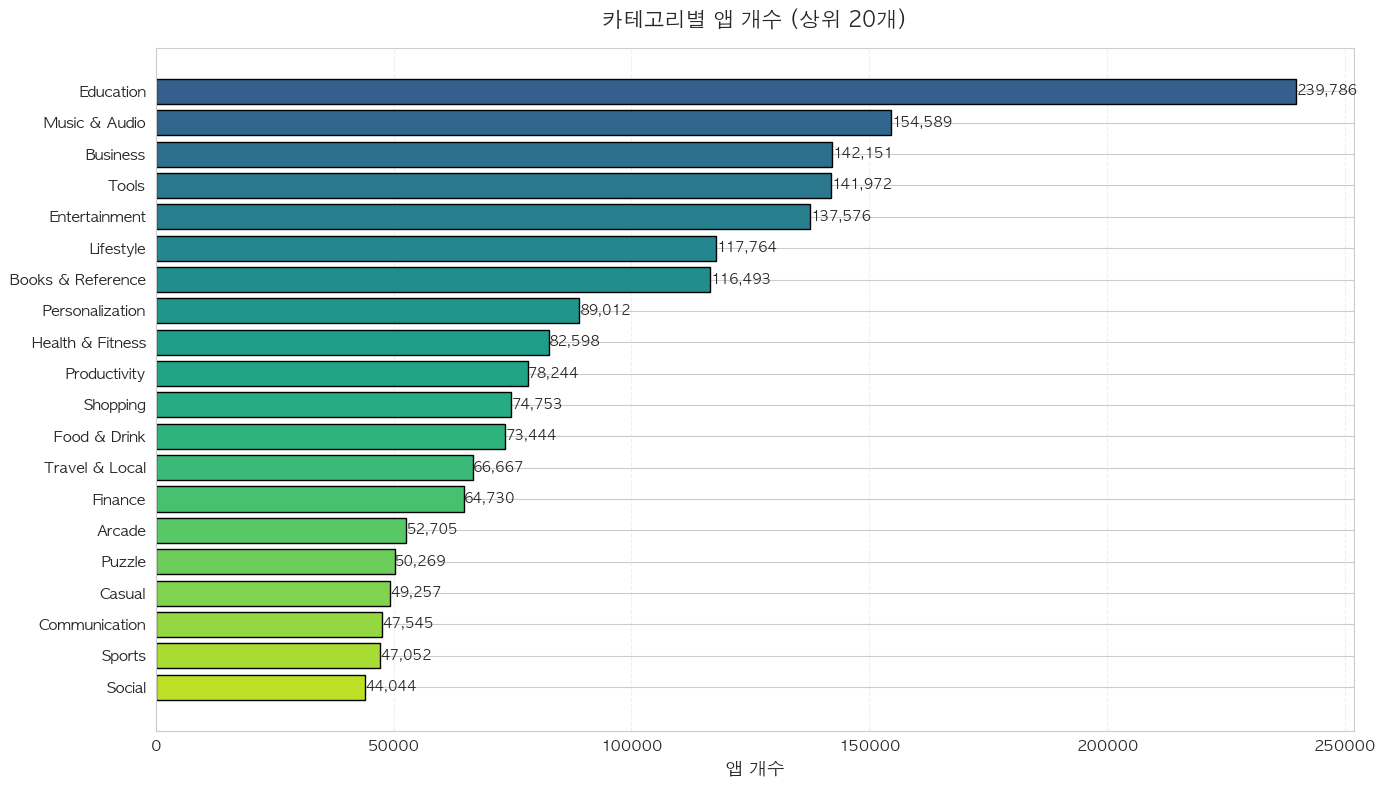


💡 인사이트: 'Education' 카테고리가 239,786개로 가장 많습니다.


In [410]:
# 시각화: 카테고리별 앱 개수 (상위 20개)
plt.figure(figsize=(14, 8))

top20_cats = category_counts.head(20)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top20_cats)))

bars = plt.barh(range(len(top20_cats)), top20_cats.values, color=colors, edgecolor='black', linewidth=1)
plt.yticks(range(len(top20_cats)), top20_cats.index)
plt.xlabel('앱 개수', fontsize=13, fontweight='bold')
plt.title('카테고리별 앱 개수 (상위 20개)', fontsize=15, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# 값 표시
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 50, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}',
             ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 인사이트: '{top20_cats.index[0]}' 카테고리가 {top20_cats.values[0]:,}개로 가장 많습니다.")

In [411]:
cat_rating = df.groupby('Category')['Rating'].agg(['mean', 'median', 'std', 'count']).round(2)
cat_rating.columns = ['평균Rating', '중앙값Rating', '표준편차', '앱개수']
cat_rating = cat_rating.sort_values('평균Rating', ascending=False)

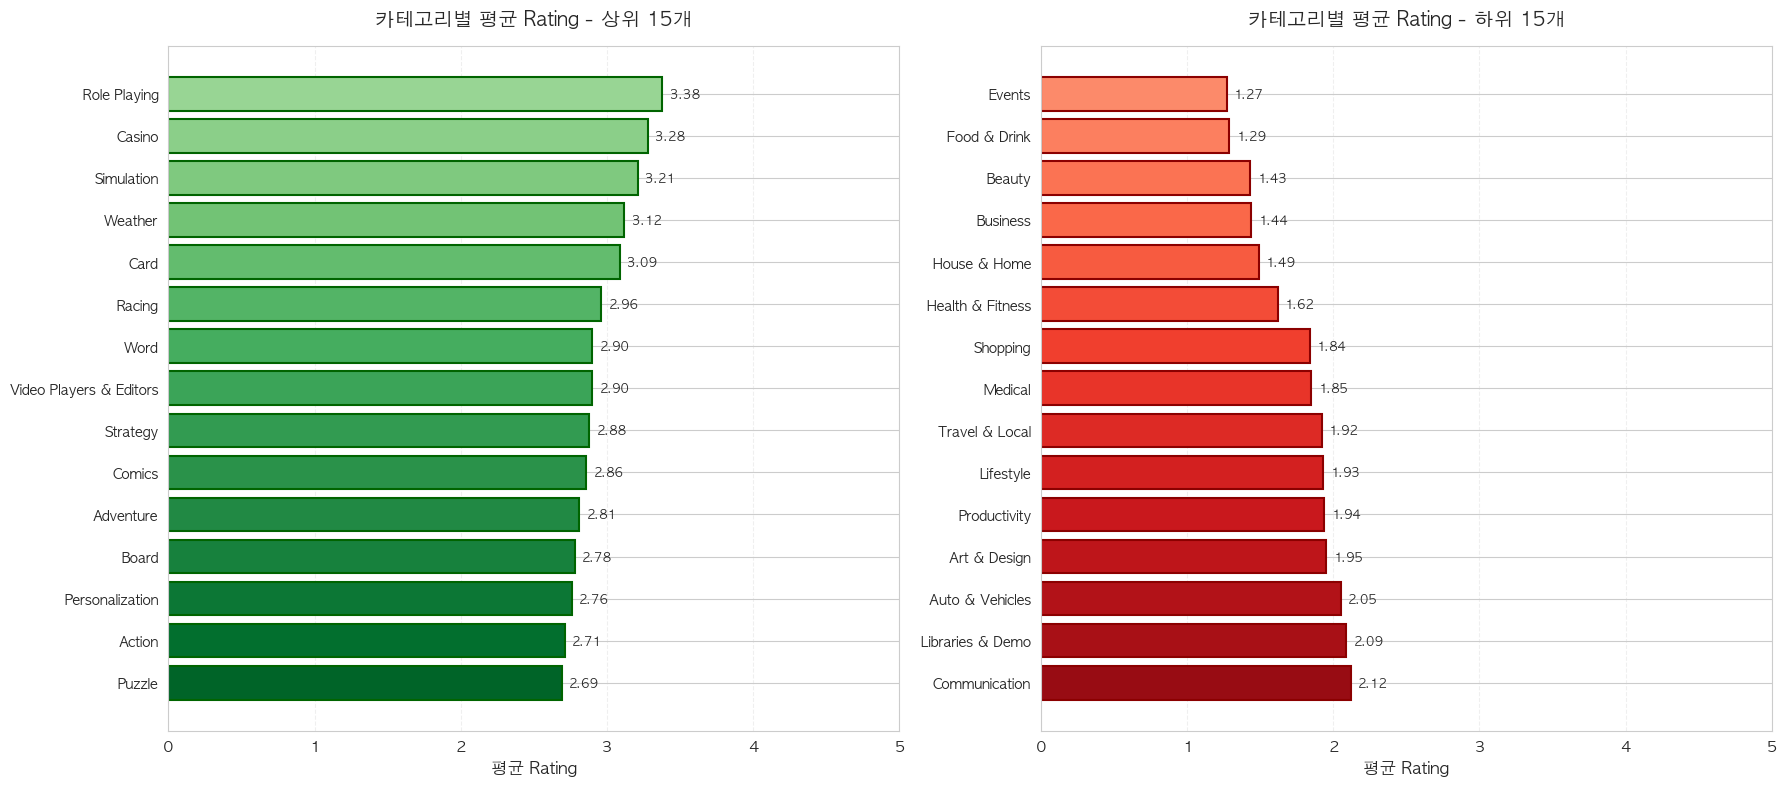


💡 인사이트:
   🥇 최고 평점: Role Playing (3.38)
   📉 최저 평점: Events (1.27)


In [412]:
# 시각화: 카테고리별 평균 Rating
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 왼쪽: 상위 15개
top15_rating = cat_rating.head(15)
colors_top = plt.cm.Greens(np.linspace(0.4, 0.9, len(top15_rating)))
bars1 = axes[0].barh(range(len(top15_rating)), top15_rating['평균Rating'].values, 
                     color=colors_top, edgecolor='darkgreen', linewidth=1.5)
axes[0].set_yticks(range(len(top15_rating)))
axes[0].set_yticklabels(top15_rating.index, fontsize=10)
axes[0].set_xlabel('평균 Rating', fontsize=12, fontweight='bold')
axes[0].set_title('카테고리별 평균 Rating - 상위 15개', fontsize=14, fontweight='bold', pad=15)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].set_xlim(0, 5)

# 값 표시
for i, bar in enumerate(bars1):
    width = bar.get_width()
    axes[0].text(width + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{width:.2f}',
                 ha='left', va='center', fontsize=9, fontweight='bold')

# 오른쪽: 하위 15개
bottom15_rating = cat_rating.tail(15).sort_values('평균Rating')
colors_bottom = plt.cm.Reds(np.linspace(0.4, 0.9, len(bottom15_rating)))
bars2 = axes[1].barh(range(len(bottom15_rating)), bottom15_rating['평균Rating'].values,
                     color=colors_bottom, edgecolor='darkred', linewidth=1.5)
axes[1].set_yticks(range(len(bottom15_rating)))
axes[1].set_yticklabels(bottom15_rating.index, fontsize=10)
axes[1].set_xlabel('평균 Rating', fontsize=12, fontweight='bold')
axes[1].set_title('카테고리별 평균 Rating - 하위 15개', fontsize=14, fontweight='bold', pad=15)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].set_xlim(0, 5)

# 값 표시
for i, bar in enumerate(bars2):
    width = bar.get_width()
    axes[1].text(width + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{width:.2f}',
                 ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 인사이트:")
print(f"   🥇 최고 평점: {cat_rating.index[0]} ({cat_rating.iloc[0]['평균Rating']:.2f})")
print(f"   📉 최저 평점: {cat_rating.index[-1]} ({cat_rating.iloc[-1]['평균Rating']:.2f})")

### 1-3. 카테고리별 Installs(다운로드 수) 분석

In [413]:
# 카테고리별 Installs 집계
cat_installs = df.groupby('Category')['Installs'].agg(['sum', 'mean', 'median', 'count'])
cat_installs.columns = ['총Installs', '평균Installs', '중앙값Installs', '앱개수']
cat_installs = cat_installs.sort_values('평균Installs', ascending=False)

print("="*70)
print("📥 카테고리별 다운로드 수 (평균 기준 상위 15개)")
print("="*70)
print(cat_installs.head(15))

print("\n" + "="*70)
print("📥 카테고리별 다운로드 수 (총합 기준 상위 15개)")
print("="*70)
cat_installs_sum = cat_installs.sort_values('총Installs', ascending=False)
print(cat_installs_sum.head(15))

📥 카테고리별 다운로드 수 (평균 기준 상위 15개)
                           총Installs    평균Installs  중앙값Installs     앱개수
Category                                                               
Video Players & Editors  18584144648  1.334588e+06       5000.0   13925
Communication            43208370129  9.087889e+05        500.0   47545
Racing                    9203644133  9.042684e+05       5000.0   10178
Action                   17374827453  6.476620e+05       1000.0   26827
Photography              18889473069  5.338120e+05       1000.0   35386
Simulation               11669579430  5.135354e+05      10000.0   22724
Strategy                  4151758175  5.040377e+05       1000.0    8237
Tools                    71423468364  5.030814e+05       1000.0  141972
Role Playing              4754489813  4.923361e+05      10000.0    9657
Music                     1630112041  3.934618e+05       1000.0    4143
Social                   17163737104  3.896952e+05        500.0   44044
Weather                   27731385

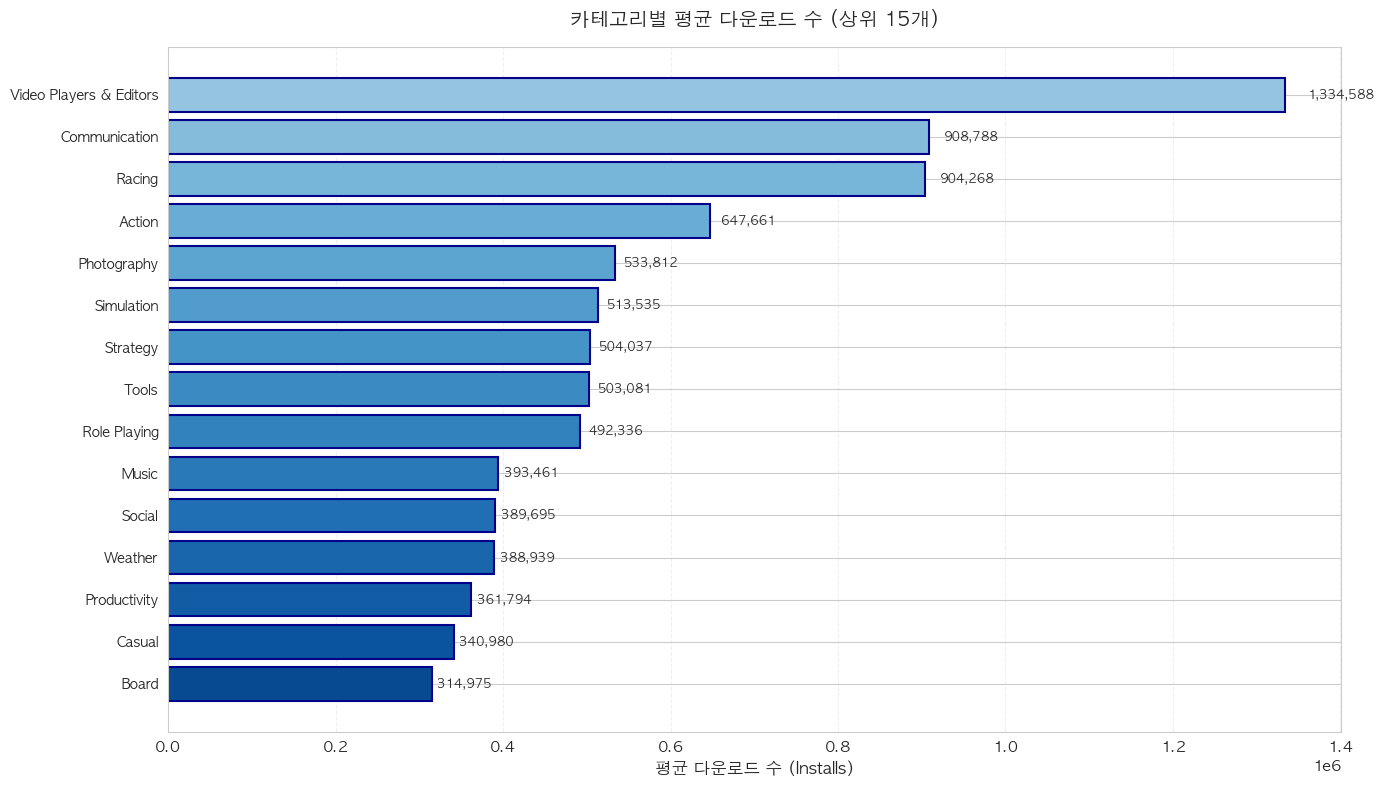


💡 인사이트: 'Video Players & Editors' 카테고리가 평균 1,334,588회로 최고입니다.


In [414]:
# 시각화: 카테고리별 평균 Installs (상위 15개)
plt.figure(figsize=(14, 8))

top15_installs = cat_installs.head(15)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top15_installs)))

bars = plt.barh(range(len(top15_installs)), top15_installs['평균Installs'].values,
                color=colors, edgecolor='darkblue', linewidth=1.5)
plt.yticks(range(len(top15_installs)), top15_installs.index, fontsize=10)
plt.xlabel('평균 다운로드 수 (Installs)', fontsize=12, fontweight='bold')
plt.title('카테고리별 평균 다운로드 수 (상위 15개)', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# 값 표시
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + width*0.02, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}',
             ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 인사이트: '{top15_installs.index[0]}' 카테고리가 평균 {int(top15_installs.iloc[0]['평균Installs']):,}회로 최고입니다.")

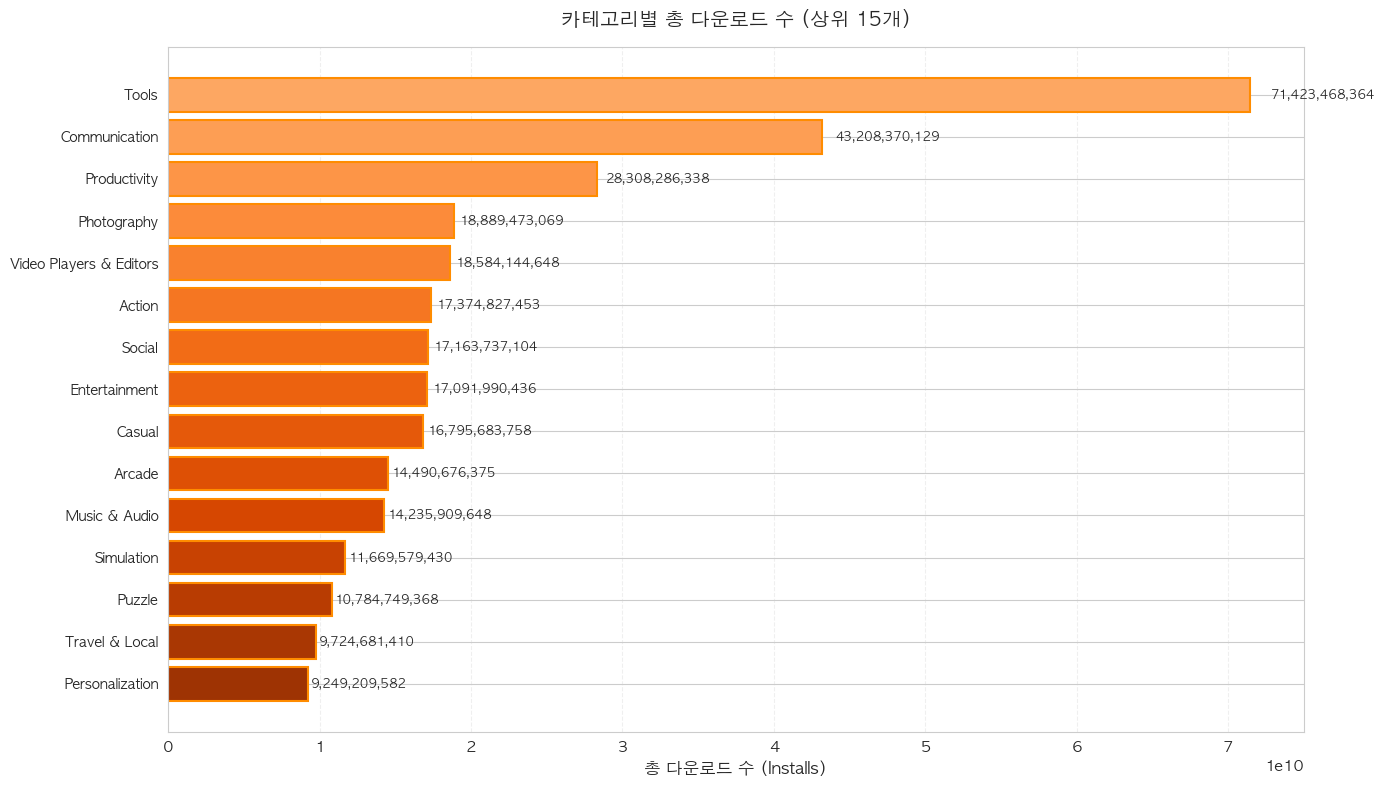


💡 인사이트: 'Tools' 카테고리의 총 다운로드가 71,423,468,364회로 압도적입니다.


In [415]:
# 시각화: 카테고리별 총 Installs (상위 15개)
plt.figure(figsize=(14, 8))

top15_sum = cat_installs_sum.head(15)
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(top15_sum)))

bars = plt.barh(range(len(top15_sum)), top15_sum['총Installs'].values,
                color=colors, edgecolor='darkorange', linewidth=1.5)
plt.yticks(range(len(top15_sum)), top15_sum.index, fontsize=10)
plt.xlabel('총 다운로드 수 (Installs)', fontsize=12, fontweight='bold')
plt.title('카테고리별 총 다운로드 수 (상위 15개)', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# 값 표시
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + width*0.02, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}',
             ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 인사이트: '{top15_sum.index[0]}' 카테고리의 총 다운로드가 {int(top15_sum.iloc[0]['총Installs']):,}회로 압도적입니다.")

### 1-4. 카테고리별 Rating vs Installs 종합 비교

In [416]:
# 카테고리별 Rating과 Installs 종합 테이블
cat_summary = pd.DataFrame({
    '평균Rating': df.groupby('Category')['Rating'].mean(),
    '평균Installs': df.groupby('Category')['Installs'].mean(),
    '총Installs': df.groupby('Category')['Installs'].sum(),
    '앱개수': df.groupby('Category').size()
}).round(2)

# 앱이 50개 이상인 카테고리만 필터링 (신뢰도 향상)
cat_summary_filtered = cat_summary[cat_summary['앱개수'] >= 50].copy()

print("="*70)
print("📊 카테고리별 종합 분석 (앱 50개 이상 카테고리)")
print("="*70)
print(f"\n분석 대상 카테고리: {len(cat_summary_filtered)}개")
print("\nRating 기준 상위 10개:")
print(cat_summary_filtered.sort_values('평균Rating', ascending=False).head(10))

print("\n평균 Installs 기준 상위 10개:")
print(cat_summary_filtered.sort_values('평균Installs', ascending=False).head(10))

📊 카테고리별 종합 분석 (앱 50개 이상 카테고리)

분석 대상 카테고리: 48개

Rating 기준 상위 10개:
                         평균Rating  평균Installs    총Installs    앱개수
Category                                                         
Role Playing                 3.38   492336.11   4754489813   9657
Casino                       3.28   248090.82   1249137278   5035
Simulation                   3.21   513535.44  11669579430  22724
Weather                      3.12   388939.49   2773138546   7130
Card                         3.09   247117.64   1988308545   8046
Racing                       2.96   904268.44   9203644133  10178
Word                         2.90   237999.16   2028942865   8525
Video Players & Editors      2.90  1334588.48  18584144648  13925
Strategy                     2.88   504037.66   4151758175   8237
Comics                       2.86   140866.14    397383379   2821

평균 Installs 기준 상위 10개:
                         평균Rating  평균Installs    총Installs     앱개수
Category                                           

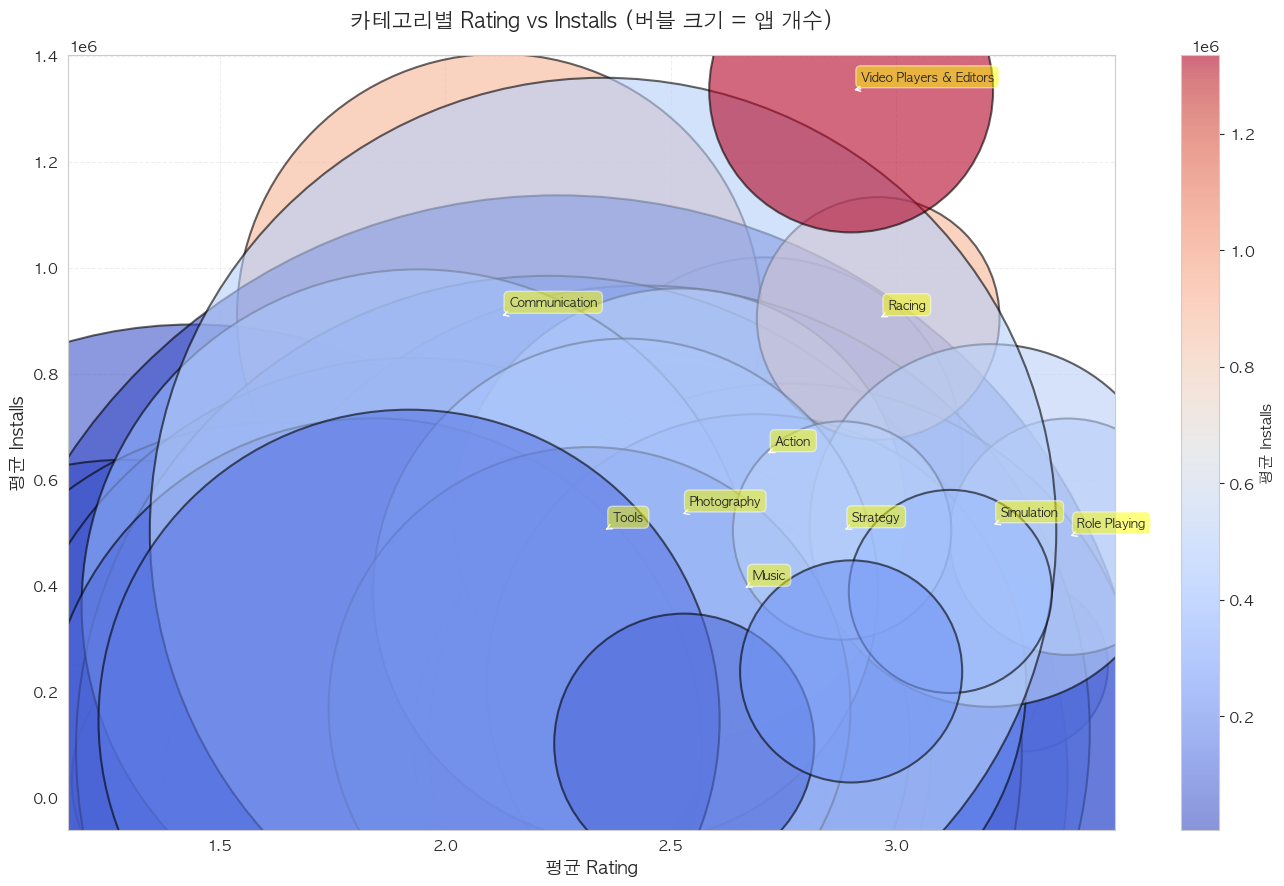


💡 해석 가이드:
   - 오른쪽 위에 위치할수록 Rating과 Installs가 모두 높음 (성공적인 카테고리)
   - 버블이 클수록 해당 카테고리의 앱이 많음


In [417]:
# 시각화: Rating vs Installs 산점도
plt.figure(figsize=(14, 9))

# 버블 크기 = 앱 개수
sizes = cat_summary_filtered['앱개수'] * 3

scatter = plt.scatter(cat_summary_filtered['평균Rating'],
                     cat_summary_filtered['평균Installs'],
                     s=sizes, alpha=0.6,
                     c=cat_summary_filtered['평균Installs'],
                     cmap='coolwarm', edgecolors='black', linewidth=1.5)

# 상위 카테고리 라벨링
top10_label = cat_summary_filtered.nlargest(10, '평균Installs')
for idx in top10_label.index:
    plt.annotate(idx,
                xy=(cat_summary_filtered.loc[idx, '평균Rating'],
                    cat_summary_filtered.loc[idx, '평균Installs']),
                xytext=(7, 7), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.5),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1))

plt.colorbar(scatter, label='평균 Installs')
plt.xlabel('평균 Rating', fontsize=13, fontweight='bold')
plt.ylabel('평균 Installs', fontsize=13, fontweight='bold')
plt.title('카테고리별 Rating vs Installs (버블 크기 = 앱 개수)',
         fontsize=15, fontweight='bold', pad=20)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\n💡 해석 가이드:")
print("   - 오른쪽 위에 위치할수록 Rating과 Installs가 모두 높음 (성공적인 카테고리)")
print("   - 버블이 클수록 해당 카테고리의 앱이 많음")

### 1-5. 테마 1 결론: 카테고리별 성공 요인 정리

In [418]:
print("="*70)
print("🎯 테마 1 핵심 인사이트: 카테고리별 성공 요인")
print("="*70)

# 최고 평점 카테고리
best_rating_cat = cat_rating.index[0]
best_rating_score = cat_rating.iloc[0]['평균Rating']

# 최다 다운로드 카테고리 (평균)
best_installs_cat = cat_installs.index[0]
best_installs_score = cat_installs.iloc[0]['평균Installs']

# 총 다운로드 최다
best_total_cat = cat_installs_sum.index[0]
best_total_score = cat_installs_sum.iloc[0]['총Installs']

# 가장 많은 앱 보유
most_apps_cat = category_counts.index[0]
most_apps_count = category_counts.values[0]

print(f"\n1️⃣  최고 평점 카테고리")
print(f"   → {best_rating_cat}: 평균 {best_rating_score:.2f}점")

print(f"\n2️⃣  평균 다운로드 최다 카테고리")
print(f"   → {best_installs_cat}: 평균 {int(best_installs_score):,}회")

print(f"\n3️⃣  총 다운로드 최다 카테고리")
print(f"   → {best_total_cat}: 총 {int(best_total_score):,}회")

print(f"\n4️⃣  앱 개수 최다 카테고리")
print(f"   → {most_apps_cat}: {most_apps_count:,}개")

print("\n" + "="*70)
print("💡 종합 결론")
print("="*70)
print("  • Rating이 높다고 해서 Installs가 많은 것은 아님")
print("  • 일부 카테고리는 Rating은 낮지만 Installs가 매우 높음")
print("  • 앱 개수가 많은 카테고리 = 경쟁이 치열한 시장")
print("  • 성공 전략은 카테고리별 특성에 따라 다를 수 있음")
print("="*70)

🎯 테마 1 핵심 인사이트: 카테고리별 성공 요인

1️⃣  최고 평점 카테고리
   → Role Playing: 평균 3.38점

2️⃣  평균 다운로드 최다 카테고리
   → Video Players & Editors: 평균 1,334,588회

3️⃣  총 다운로드 최다 카테고리
   → Tools: 총 71,423,468,364회

4️⃣  앱 개수 최다 카테고리
   → Education: 239,786개

💡 종합 결론
  • Rating이 높다고 해서 Installs가 많은 것은 아님
  • 일부 카테고리는 Rating은 낮지만 Installs가 매우 높음
  • 앱 개수가 많은 카테고리 = 경쟁이 치열한 시장
  • 성공 전략은 카테고리별 특성에 따라 다를 수 있음


### 2-1. Rating 분포 분석

In [419]:
# Rating 기본 통계
print("="*70)
print("⭐ Rating 기본 통계")
print("="*70)
print(df['Rating'].describe())

# Rating 구간별 분포
rating_bins = pd.cut(df['Rating'],
                     bins=[0, 2, 3, 4, 4.5, 5],
                     labels=['0-2점', '2-3점', '3-4점', '4-4.5점', '4.5-5점'])

print("\n" + "="*70)
print("⭐ Rating 구간별 앱 개수")
print("="*70)
rating_bin_counts = rating_bins.value_counts().sort_index()
print(rating_bin_counts)
print(f"\n비율(%):\n{(rating_bin_counts / len(df) * 100).round(2)}")

⭐ Rating 기본 통계
count    2.290056e+06
mean     2.203148e+00
std      2.106223e+00
min      0.000000e+00
25%      0.000000e+00
50%      2.900000e+00
75%      4.300000e+00
max      5.000000e+00
Name: Rating, dtype: float64

⭐ Rating 구간별 앱 개수
Rating
0-2점       17148
2-3점       86480
3-4점      376359
4-4.5점    404047
4.5-5점    346260
Name: count, dtype: int64

비율(%):
Rating
0-2점       0.75
2-3점       3.78
3-4점      16.43
4-4.5점    17.64
4.5-5점    15.12
Name: count, dtype: float64


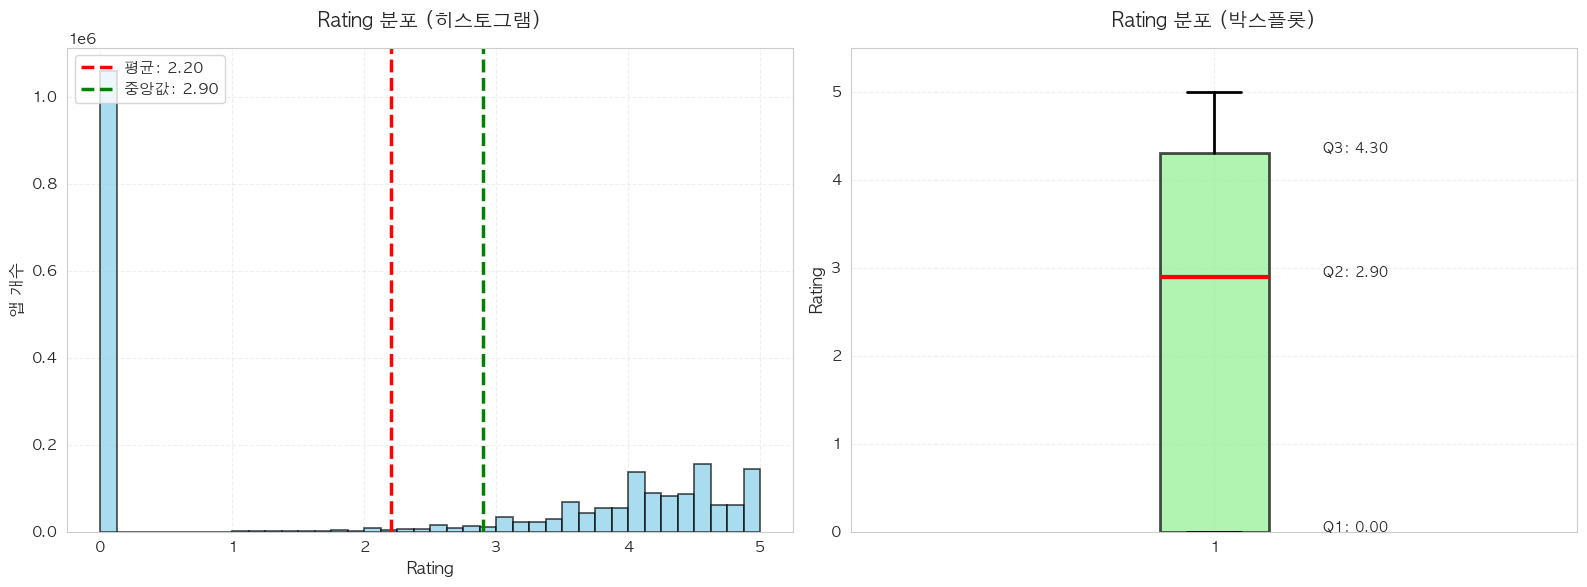


💡 인사이트:
   - 평균 Rating: 2.20점
   - 중앙값: 2.90점
   - 50% 앱들이 0.00~4.30점 사이에 분포


In [420]:
# 시각화: Rating 분포
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 히스토그램
axes[0].hist(df['Rating'], bins=40, color='skyblue', edgecolor='black', alpha=0.7, linewidth=1.2)
axes[0].axvline(df['Rating'].mean(), color='red', linestyle='--', linewidth=2.5,
               label=f'평균: {df["Rating"].mean():.2f}')
axes[0].axvline(df['Rating'].median(), color='green', linestyle='--', linewidth=2.5,
               label=f'중앙값: {df["Rating"].median():.2f}')
axes[0].set_xlabel('Rating', fontsize=12, fontweight='bold')
axes[0].set_ylabel('앱 개수', fontsize=12, fontweight='bold')
axes[0].set_title('Rating 분포 (히스토그램)', fontsize=14, fontweight='bold', pad=15)
axes[0].legend(fontsize=11, loc='upper left')
axes[0].grid(alpha=0.3, linestyle='--')

# 오른쪽: 박스플롯
bp = axes[1].boxplot(df['Rating'], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightgreen', alpha=0.7, linewidth=2),
                     medianprops=dict(color='red', linewidth=3),
                     whiskerprops=dict(linewidth=2),
                     capprops=dict(linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))
axes[1].set_ylabel('Rating', fontsize=12, fontweight='bold')
axes[1].set_title('Rating 분포 (박스플롯)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylim(0, 5.5)
axes[1].grid(alpha=0.3, linestyle='--')

# 사분위수 표시
q1 = df['Rating'].quantile(0.25)
q3 = df['Rating'].quantile(0.75)
axes[1].text(1.15, q1, f'Q1: {q1:.2f}', fontsize=10, fontweight='bold')
axes[1].text(1.15, df['Rating'].median(), f'Q2: {df["Rating"].median():.2f}', fontsize=10, fontweight='bold')
axes[1].text(1.15, q3, f'Q3: {q3:.2f}', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 인사이트:")
print(f"   - 평균 Rating: {df['Rating'].mean():.2f}점")
print(f"   - 중앙값: {df['Rating'].median():.2f}점")
print(f"   - 50% 앱들이 {q1:.2f}~{q3:.2f}점 사이에 분포")

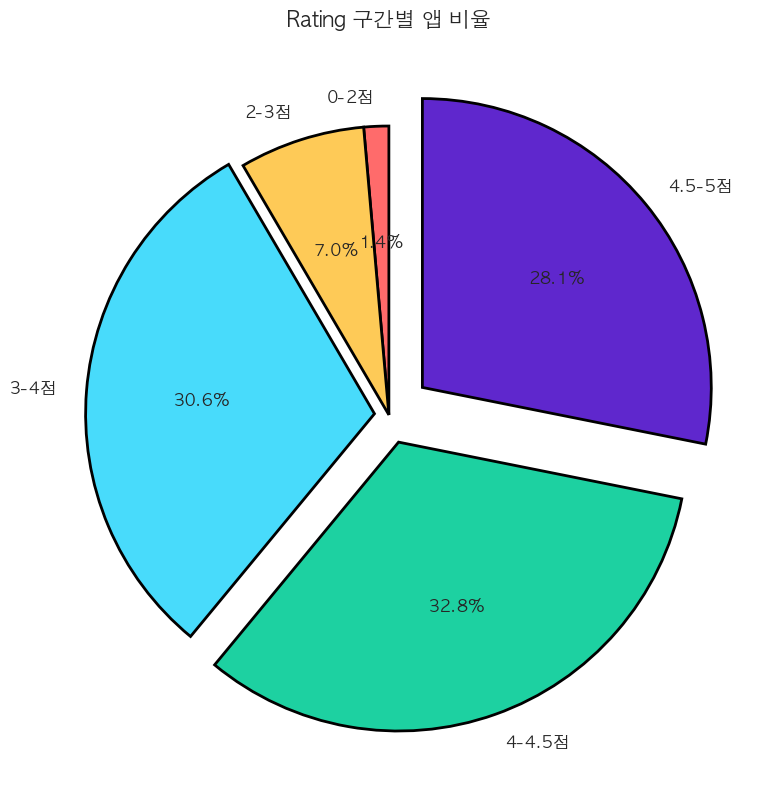


💡 인사이트: 4-4.5점 구간에 가장 많은 앱(404,047개)이 분포합니다.


In [421]:
# 시각화: Rating 구간별 비율 (파이 차트)
plt.figure(figsize=(10, 8))

colors = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1', '#5f27cd']
explode = (0, 0, 0.05, 0.1, 0.15)  # 높은 점수 강조

plt.pie(rating_bin_counts.values, labels=rating_bin_counts.index,
        autopct='%1.1f%%', startangle=90, colors=colors, explode=explode,
        textprops={'fontsize': 12, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 2})
plt.title('Rating 구간별 앱 비율', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"\n💡 인사이트: {rating_bin_counts.idxmax()} 구간에 가장 많은 앱({rating_bin_counts.max():,}개)이 분포합니다.")

### 2-2. Rating Count(리뷰 개수) 분포 분석

In [422]:
# Rating Count 컬럼 존재 여부 확인
if 'Rating Count' in df.columns:
    has_rating_count = True
    print("✅ Rating Count 컬럼 존재 - 리뷰 분석 진행")
else:
    has_rating_count = False
    print("⚠️ Rating Count 컬럼 없음 - 리뷰 분석 건너뜀")

✅ Rating Count 컬럼 존재 - 리뷰 분석 진행


In [423]:
if has_rating_count:
    # Rating Count 기본 통계
    print("="*70)
    print("💬 Rating Count 기본 통계")
    print("="*70)
    print(df['Rating Count'].describe())
    
    # Rating Count 구간 분류
    count_bins = pd.cut(df['Rating Count'],
                        bins=[0, 100, 1000, 10000, 100000, df['Rating Count'].max()],
                        labels=['0-100', '100-1K', '1K-10K', '10K-100K', '100K+'])
    
    print("\n" + "="*70)
    print("💬 Rating Count 구간별 앱 개수")
    print("="*70)
    count_bin_counts = count_bins.value_counts().sort_index()
    print(count_bin_counts)
else:
    print("⚠️ Rating Count 데이터가 없어 이 분석을 건너뜁니다.")

💬 Rating Count 기본 통계
count    2.285106e+06
mean     2.870482e+03
std      2.123921e+05
min      0.000000e+00
25%      0.000000e+00
50%      6.000000e+00
75%      4.200000e+01
max      1.385576e+08
Name: Rating Count, dtype: float64

💬 Rating Count 구간별 앱 개수
Rating Count
0-100       827156
100-1K      262526
1K-10K       98231
10K-100K     30230
100K+         7201
Name: count, dtype: int64


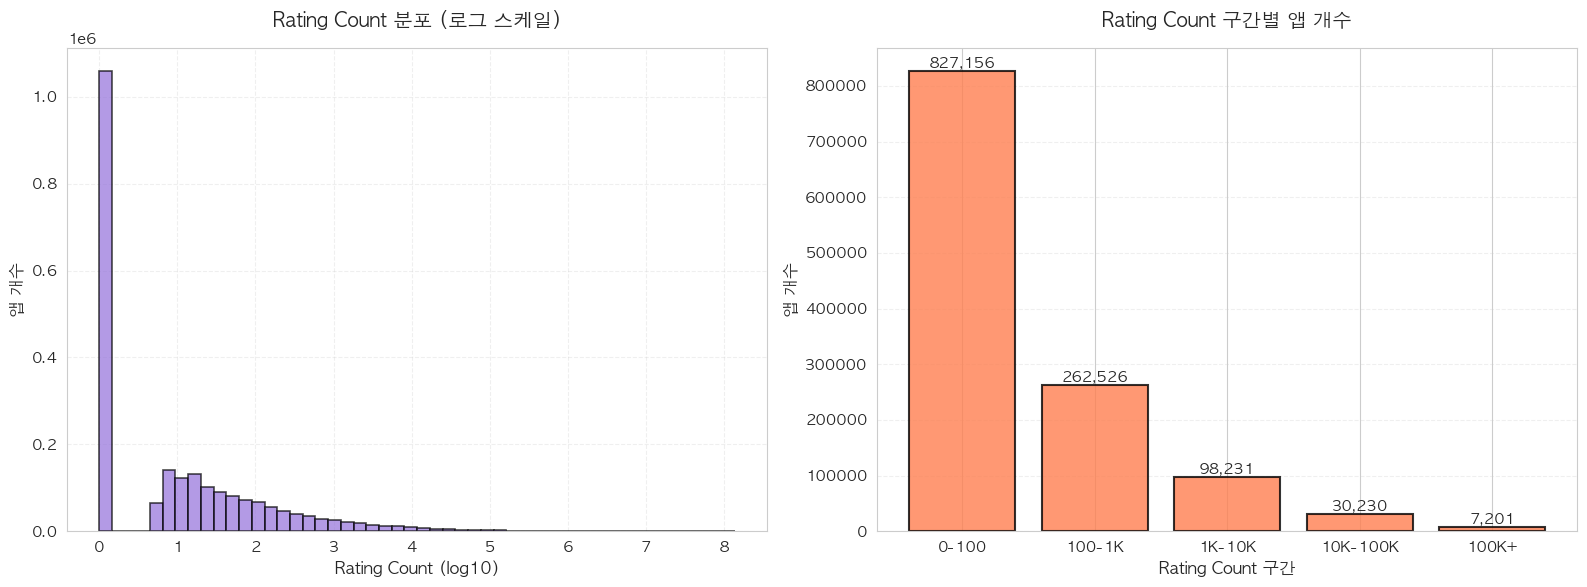


💡 인사이트: 대부분의 앱이 리뷰 개수가 적으며, 많은 리뷰를 받는 앱은 소수입니다.


In [424]:
if has_rating_count:
    # 시각화: Rating Count 분포
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 왼쪽: 히스토그램 (로그 스케일)
    axes[0].hist(np.log10(df['Rating Count'] + 1), bins=50,
                color='mediumpurple', edgecolor='black', alpha=0.7, linewidth=1.2)
    axes[0].set_xlabel('Rating Count (log10)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('앱 개수', fontsize=12, fontweight='bold')
    axes[0].set_title('Rating Count 분포 (로그 스케일)', fontsize=14, fontweight='bold', pad=15)
    axes[0].grid(alpha=0.3, linestyle='--')
    
    # 오른쪽: 구간별 막대 그래프
    bars = axes[1].bar(range(len(count_bin_counts)), count_bin_counts.values,
                       color='coral', alpha=0.8, edgecolor='black', linewidth=1.5)
    axes[1].set_xticks(range(len(count_bin_counts)))
    axes[1].set_xticklabels(count_bin_counts.index, fontsize=11)
    axes[1].set_xlabel('Rating Count 구간', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('앱 개수', fontsize=12, fontweight='bold')
    axes[1].set_title('Rating Count 구간별 앱 개수', fontsize=14, fontweight='bold', pad=15)
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')
    
    # 값 표시
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, height,
                    f'{int(height):,}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n💡 인사이트: 대부분의 앱이 리뷰 개수가 적으며, 많은 리뷰를 받는 앱은 소수입니다.")

### 2-3. Rating Count vs Installs 관계 분석

In [425]:
if has_rating_count:
    # 상관계수 계산
    correlation = df[['Rating Count', 'Installs']].corr().iloc[0, 1]
    
    print("="*70)
    print("📊 Rating Count와 Installs 상관관계")
    print("="*70)
    print(f"상관계수: {correlation:.4f}")
    
    if correlation > 0.7:
        print("✅ 강한 양의 상관관계 - 다운로드가 많을수록 리뷰도 많습니다.")
    elif correlation > 0.4:
        print("✅ 중간 정도의 양의 상관관계 - 다운로드와 리뷰가 어느 정도 관련됩니다.")
    else:
        print("⚠️ 약한 상관관계 - 다운로드와 리뷰의 관련성이 약합니다.")

📊 Rating Count와 Installs 상관관계
상관계수: 0.5453
✅ 중간 정도의 양의 상관관계 - 다운로드와 리뷰가 어느 정도 관련됩니다.


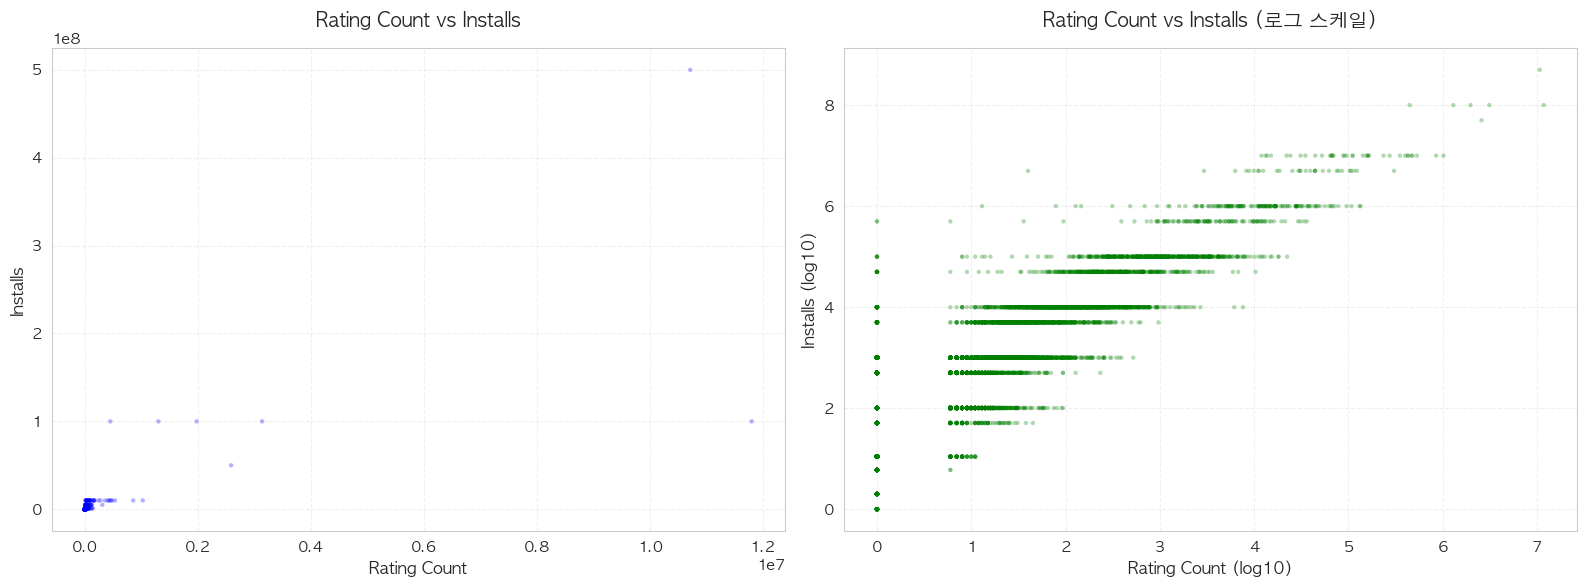


💡 인사이트: 다운로드 수가 많을수록 리뷰도 많은 경향이 있습니다.


In [426]:
if has_rating_count:
    # 시각화: Rating Count vs Installs 산점도
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 왼쪽: 일반 산점도 (샘플링)
    sample_df = df.sample(min(10000, len(df)), random_state=42)
    axes[0].scatter(sample_df['Rating Count'], sample_df['Installs'],
                   alpha=0.3, s=10, color='blue', edgecolors='none')
    axes[0].set_xlabel('Rating Count', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Installs', fontsize=12, fontweight='bold')
    axes[0].set_title('Rating Count vs Installs', fontsize=14, fontweight='bold', pad=15)
    axes[0].grid(alpha=0.3, linestyle='--')
    
    # 오른쪽: 로그 스케일 산점도
    axes[1].scatter(np.log10(sample_df['Rating Count'] + 1),
                   np.log10(sample_df['Installs'] + 1),
                   alpha=0.3, s=10, color='green', edgecolors='none')
    axes[1].set_xlabel('Rating Count (log10)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Installs (log10)', fontsize=12, fontweight='bold')
    axes[1].set_title('Rating Count vs Installs (로그 스케일)', fontsize=14, fontweight='bold', pad=15)
    axes[1].grid(alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n💡 인사이트: 다운로드 수가 많을수록 리뷰도 많은 경향이 있습니다.")

### 2-4. Rating vs Installs 상관관계

In [427]:
# Rating과 Installs 상관계수
rating_installs_corr = df[['Rating', 'Installs']].corr().iloc[0, 1]

print("="*70)
print("📊 Rating과 Installs 상관관계")
print("="*70)
print(f"상관계수: {rating_installs_corr:.4f}")

if abs(rating_installs_corr) < 0.3:
    print("⚠️ 약한 상관관계 - 평점이 높다고 다운로드가 많은 것은 아닙니다.")
elif abs(rating_installs_corr) < 0.7:
    print("✅ 중간 정도의 상관관계 - 평점과 다운로드가 어느 정도 관련됩니다.")
else:
    print("✅ 강한 상관관계 - 평점이 높을수록 다운로드도 많습니다.")

📊 Rating과 Installs 상관관계
상관계수: 0.0112
⚠️ 약한 상관관계 - 평점이 높다고 다운로드가 많은 것은 아닙니다.


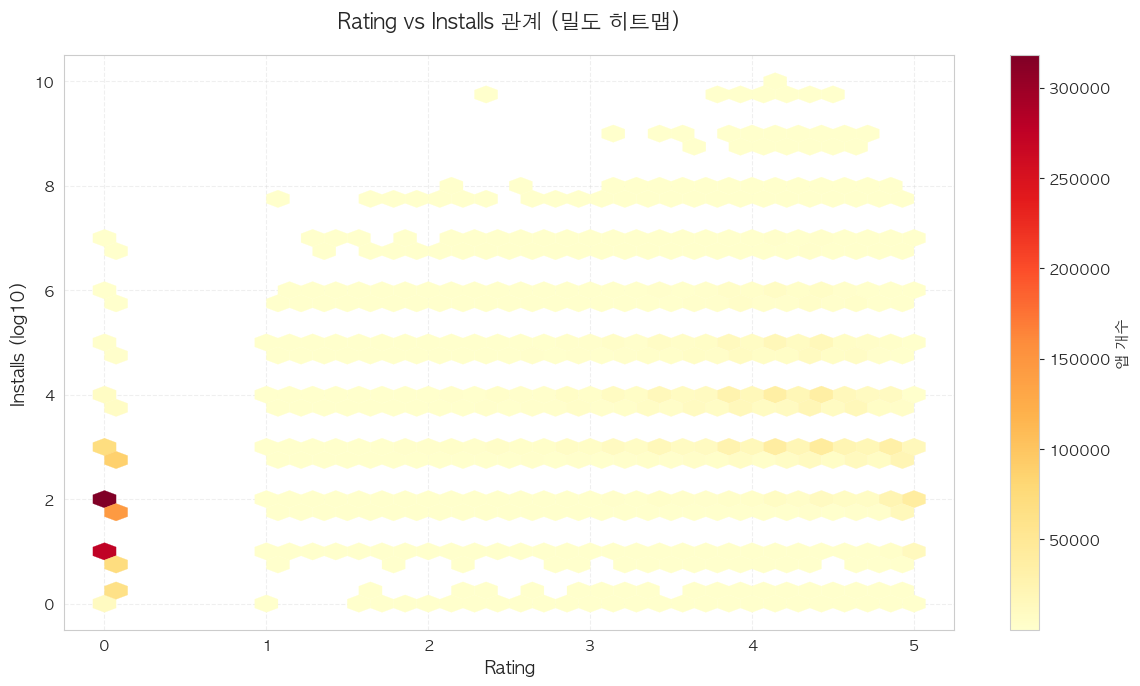


💡 인사이트: 색이 진할수록 해당 Rating-Installs 조합의 앱이 많습니다.


In [428]:
# 시각화: Rating vs Installs 헥스빈
plt.figure(figsize=(12, 7))

plt.hexbin(df['Rating'], np.log10(df['Installs'] + 1),
          gridsize=35, cmap='YlOrRd', mincnt=1, linewidths=0.2)
plt.colorbar(label='앱 개수')
plt.xlabel('Rating', fontsize=13, fontweight='bold')
plt.ylabel('Installs (log10)', fontsize=13, fontweight='bold')
plt.title('Rating vs Installs 관계 (밀도 히트맵)', fontsize=15, fontweight='bold', pad=20)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\n💡 인사이트: 색이 진할수록 해당 Rating-Installs 조합의 앱이 많습니다.")

### 2-5. Rating 구간별 평균 Installs 비교

In [429]:
# Rating 구간 생성
df['Rating_구간'] = pd.cut(df['Rating'],
                          bins=[0, 2, 3, 4, 4.5, 5],
                          labels=['0-2점', '2-3점', '3-4점', '4-4.5점', '4.5-5점'])

# 구간별 평균 Installs
rating_bin_installs = df.groupby('Rating_구간', observed=True).agg({
    'Installs': ['mean', 'median', 'count']
})
rating_bin_installs.columns = ['평균Installs', '중앙값Installs', '앱개수']

print("="*70)
print("📊 Rating 구간별 평균 Installs")
print("="*70)
print(rating_bin_installs)

📊 Rating 구간별 평균 Installs
              평균Installs  중앙값Installs     앱개수
Rating_구간                                    
0-2점        49739.560415       1000.0   17148
2-3점       124153.044958       5000.0   86480
3-4점       291550.848719      10000.0  376359
4-4.5점     652979.330568       5000.0  404047
4.5-5점     110038.917363       1000.0  346260


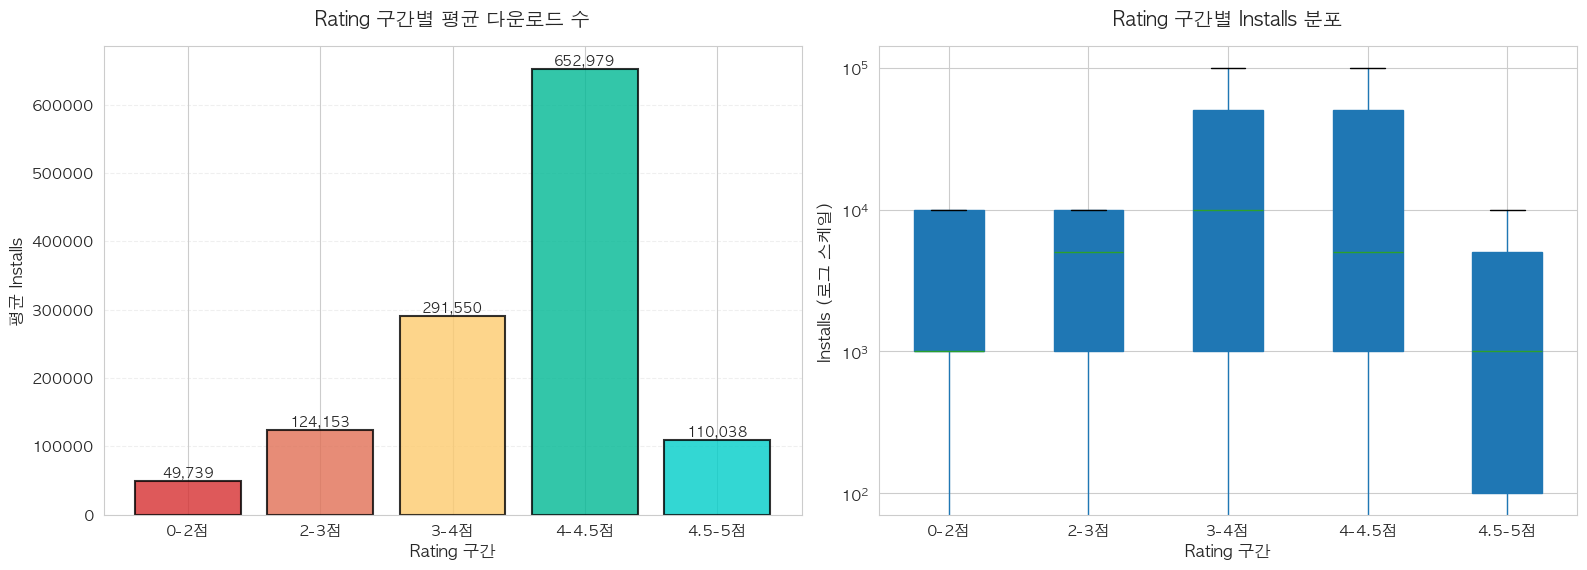


💡 인사이트: '4-4.5점' 구간 앱들의 평균 다운로드 수가 가장 많습니다.


In [430]:
# 시각화: Rating 구간별 평균 Installs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 막대 그래프
colors_gradient = ['#d63031', '#e17055', '#fdcb6e', '#00b894', '#00cec9']
bars = axes[0].bar(range(len(rating_bin_installs)),
                   rating_bin_installs['평균Installs'].values,
                   color=colors_gradient, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0].set_xticks(range(len(rating_bin_installs)))
axes[0].set_xticklabels(rating_bin_installs.index, fontsize=11)
axes[0].set_xlabel('Rating 구간', fontsize=12, fontweight='bold')
axes[0].set_ylabel('평균 Installs', fontsize=12, fontweight='bold')
axes[0].set_title('Rating 구간별 평균 다운로드 수', fontsize=14, fontweight='bold', pad=15)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# 값 표시
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 오른쪽: 박스플롯
df.boxplot(column='Installs', by='Rating_구간', ax=axes[1],
          patch_artist=True, grid=True, showfliers=False)
axes[1].set_xlabel('Rating 구간', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Installs (로그 스케일)', fontsize=12, fontweight='bold')
axes[1].set_title('Rating 구간별 Installs 분포', fontsize=14, fontweight='bold', pad=15)
axes[1].set_yscale('log')
plt.suptitle('')  # 상단 자동 제목 제거

plt.tight_layout()
plt.show()

best_bin = rating_bin_installs['평균Installs'].idxmax()
print(f"\n💡 인사이트: '{best_bin}' 구간 앱들의 평균 다운로드 수가 가장 많습니다.")

### 2-6. 리뷰 참여율 분석

In [431]:
if has_rating_count:
    # 리뷰 참여율 계산
    df['리뷰참여율(%)'] = (df['Rating Count'] / df['Installs'] * 100).round(2)
    df['리뷰참여율(%)'] = df['리뷰참여율(%)'].replace([np.inf, -np.inf], np.nan)
    
    print("="*70)
    print("💬 리뷰 참여율 통계")
    print("="*70)
    print(df['리뷰참여율(%)'].describe())
    
    # 참여율 상위 앱
    print("\n" + "="*70)
    print("💬 리뷰 참여율 상위 10개 앱")
    print("="*70)
    if 'App Name' in df.columns:
        top_part = df.nlargest(10, '리뷰참여율(%)')[['App Name', 'Category', 'Rating',
                                                      'Installs', 'Rating Count', '리뷰참여율(%)']]
        print(top_part)
    else:
        top_part = df.nlargest(10, '리뷰참여율(%)')[['Category', 'Rating',
                                                      'Installs', 'Rating Count', '리뷰참여율(%)']]
        print(top_part)

💬 리뷰 참여율 통계
count    2.273936e+06
mean     2.310397e+00
std      7.451112e+00
min      0.000000e+00
25%      0.000000e+00
50%      3.000000e-01
75%      1.550000e+00
max      1.000000e+02
Name: 리뷰참여율(%), dtype: float64

💬 리뷰 참여율 상위 10개 앱
                                                App Name       Category  \
3829                                            SomzIRIS  Entertainment   
4119                               Officials Information  Communication   
5197                                          meal ideas   Food & Drink   
5450                               Vertex Unit Converter          Tools   
6983                                  Sympl Productivity   Productivity   
7776                                    Fall Faster Ball         Arcade   
9608                                              McPAID      Lifestyle   
11032  Infinite 3D Game NO or With Internet Planet Darks         Arcade   
11907                                    Cosmic Fortunes         Arcade   
14409       

### 2-7. 테마 2 결론: 평점 구조 및 리뷰 참여도 정리

---

In [432]:
print("="*70)
print("⭐ 테마 2 핵심 인사이트: 평점 구조 및 리뷰 참여도")
print("="*70)

# Rating 분포 특성
print(f"\n1️⃣  Rating 분포 특성")
print(f"   • 평균 Rating: {df['Rating'].mean():.2f}점")
print(f"   • 중앙값: {df['Rating'].median():.2f}점")
print(f"   • 가장 많은 구간: {rating_bin_counts.idxmax()}")

# Rating-Installs 관계
print(f"\n2️⃣  Rating과 Installs 관계")
print(f"   • 상관계수: {rating_installs_corr:.4f}")
if abs(rating_installs_corr) < 0.3:
    print(f"   • 해석: 평점이 높다고 다운로드가 많은 것은 아님")
else:
    print(f"   • 해석: 평점과 다운로드는 어느 정도 관련성이 있음")

# Rating Count 관계 (있는 경우만)
if has_rating_count:
    print(f"\n3️⃣  Rating Count와 Installs 관계")
    print(f"   • 상관계수: {correlation:.4f}")
    print(f"   • 해석: 다운로드가 많을수록 리뷰도 많음")
    
    print(f"\n4️⃣  리뷰 참여율")
    print(f"   • 중앙값: {df['리뷰참여율(%)'].median():.2f}%")
    print(f"   • 대부분의 사용자는 리뷰를 작성하지 않음")

print("\n" + "="*70)
print("💡 종합 결론")
print("="*70)
print("  • 대부분의 앱이 4점 이상의 높은 평점을 받고 있음")
print("  • Rating과 Installs는 강한 상관관계를 보이지 않음")
print("  • 다운로드 수가 많아도 리뷰 참여율은 낮음")
print("  • 앱 성공에는 평점 외에도 다른 요인들이 중요")
print("="*70)

⭐ 테마 2 핵심 인사이트: 평점 구조 및 리뷰 참여도

1️⃣  Rating 분포 특성
   • 평균 Rating: 2.20점
   • 중앙값: 2.90점
   • 가장 많은 구간: 4-4.5점

2️⃣  Rating과 Installs 관계
   • 상관계수: 0.0112
   • 해석: 평점이 높다고 다운로드가 많은 것은 아님

3️⃣  Rating Count와 Installs 관계
   • 상관계수: 0.5453
   • 해석: 다운로드가 많을수록 리뷰도 많음

4️⃣  리뷰 참여율
   • 중앙값: 0.30%
   • 대부분의 사용자는 리뷰를 작성하지 않음

💡 종합 결론
  • 대부분의 앱이 4점 이상의 높은 평점을 받고 있음
  • Rating과 Installs는 강한 상관관계를 보이지 않음
  • 다운로드 수가 많아도 리뷰 참여율은 낮음
  • 앱 성공에는 평점 외에도 다른 요인들이 중요


---

## 테마 3: 다운로드 패턴 - 롱테일 구조 분석
**목표:** 앱 시장의 구조 분석

---

## 테마 4: 업데이트 주기 및 앱 나이 분석
**목표:** 업데이트 주기와 앱 나이가 다운로드 및 평점에 미치는 영향 분석

---

### 3-1. 다운로드 패턴 분석
Installs 분포(원본/로그), Installs_bin 비율 분석, 다운로드 상·하위 그룹 특성을 확인한다.

<Axes: xlabel='Installs', ylabel='Count'>

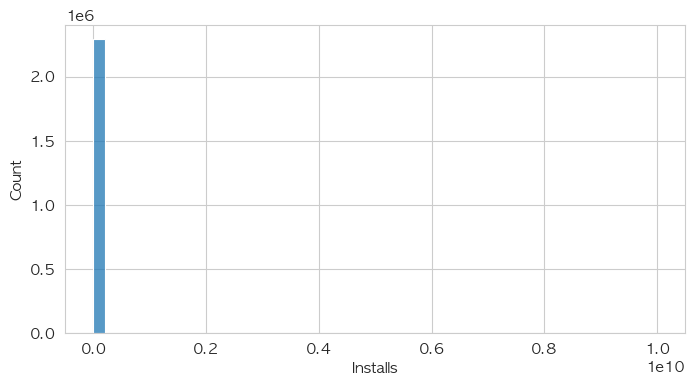

In [433]:
#Installs 분포(원본)
plt.figure(figsize=(8,4))
sns.histplot(df, x="Installs", bins=50, stat="count")

<Axes: xlabel='Installs_log', ylabel='Count'>

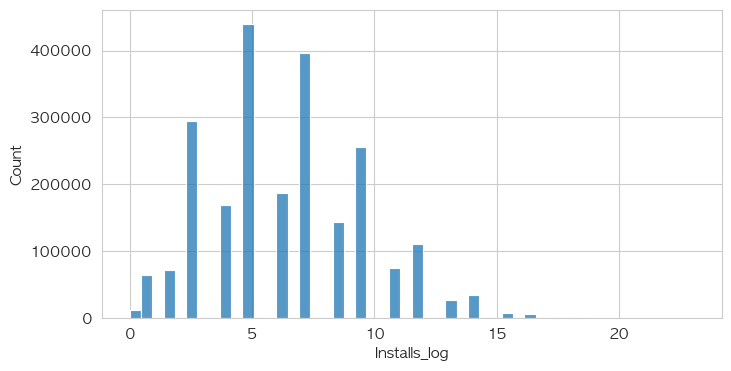

In [434]:
#install 분포 (로그)
plt.figure(figsize=(8,4))
sns.histplot(df, x = 'Installs_log' , bins= 50, stat ='count')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, '0-1K'),
  Text(1, 0, '1K-10K'),
  Text(2, 0, '10K-100K'),
  Text(3, 0, '100K-1M'),
  Text(4, 0, '1M-10M'),
  Text(5, 0, '10M+')])

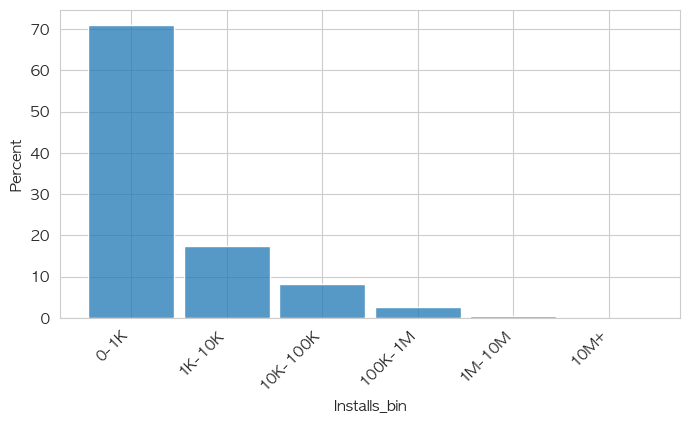

In [435]:
#Installs_bin 비율(%)
plt.figure(figsize=(8,4))
sns.histplot(
    df,
    x="Installs_bin",
    discrete=True,
    stat="percent",
    shrink=0.9
)
plt.xticks(rotation=45, ha="right")

**분석 결과**  
앱 시장은 극단적인 롱테일 구조를 보인다. 대부분(70% 이상)의 앱은 0-1K 다운로드에 해당한다.

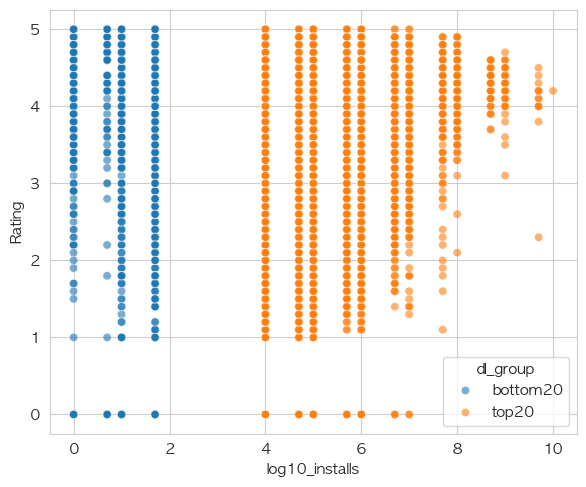

In [436]:
# 상·하위 그룹 특성 확인
df["log10_installs"] = np.log10(df["Installs"].clip(lower=1))

q_low  = df["Installs"].quantile(0.2)
q_high = df["Installs"].quantile(0.8)

df["dl_group"] = "mid"
df.loc[df["Installs"] <= q_low,  "dl_group"] = "bottom20"
df.loc[df["Installs"] >= q_high, "dl_group"] = "top20"

sub = df[df["dl_group"] != "mid"].copy()

plt.figure(figsize=(6,5))
sns.scatterplot(data=sub,x="log10_installs",y="Rating",hue="dl_group",alpha=0.6)
plt.tight_layout()
plt.show()

**분석 결과**  
그래프를 보면 설치 수가 많을수록 평점이 일정하게 높고, 설치 수가 적을수록 평점의 분포가 넓고 불안정한 것을 확인할 수 있다.

### 4-1. 업데이트 주기 및 앱 나이 분석

<Axes: xlabel='app_age_days', ylabel='Count'>

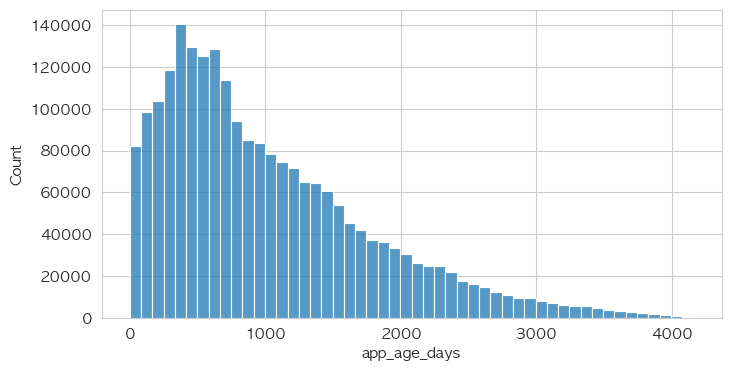

In [437]:
plt.figure(figsize=(8,4))
sns.histplot(df, x = 'app_age_days' , bins= 50, stat ='count')

### 4-2. 앱의 나이(age) 분석

그래프는 오른쪽으로 긴 꼬리(long tail)를 가진 비대칭 분포(right-skewed distribution)를 보인다.

대부분의 앱은 비교적 최근에 출시되었고, 오래된 앱(수천 일 이상 된 앱)은 점점 적어진다.

앱의 나이가 약 500~1,000일(약 1.5~3년) 근처에서 가장 많다. 이는 모바일 생태계에서 2~3년 된 앱들이 가장 흔하다는 것을 의미한다.

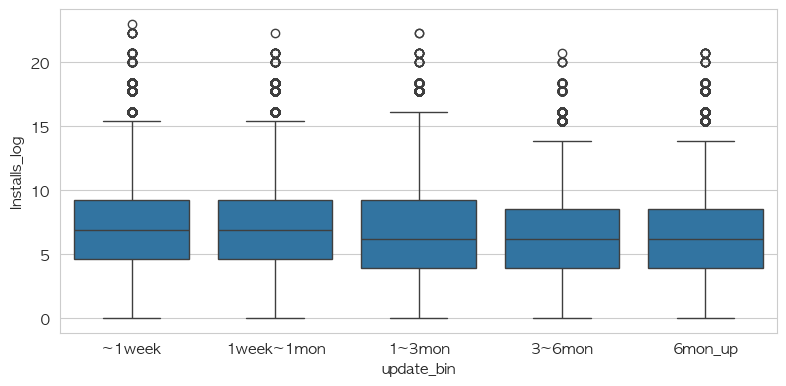

In [438]:
df["update_bin"] = pd.cut(
    df["days_since_update"],
    bins=[0, 7, 30, 90, 180, np.inf],
    labels=["~1week", "1week~1mon", "1~3mon", "3~6mon", "6mon_up"])

plt.figure(figsize=(8,4))
sns.boxplot(df, x="update_bin", y="Installs_log")
plt.tight_layout()
plt.show()

### 4-3. 앱의 업데이트 여부와 설치 수의 관계 분석

~1주, 1주~1개월에 업데이트된 앱들의 중앙값이 약간 더 높다.

3~6개월 이상 업데이트하지 않은 앱(3~6개월, 6개월 이상)은 중앙값이 소폭 낮다.

이는 최근에 관리·업데이트되는 앱이 다소 더 많은 설치를 유지하는 경향을 보인다. 하지만 전반적으로 모든 구간의 분포가 비슷한 높이와 범위를 가져 업데이트 시기만으로 설치 수가 극적으로 달라지지는 않는다.

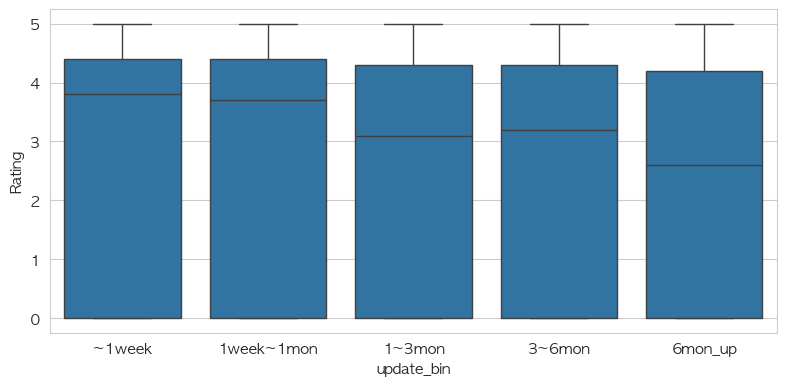

In [439]:
df["update_bin"] = pd.cut(
    df["days_since_update"],
    bins=[0, 7, 30, 90, 180, np.inf],
    labels=["~1week", "1week~1mon", "1~3mon", "3~6mon", "6mon_up"])
plt.figure(figsize=(8,4))
sns.boxplot(df, x="update_bin", y="Rating")
plt.tight_layout()
plt.show()

### 4-4. 업데이트 기간에 따른 평점 분석

전반적으로 모든 구간에서 평점 중앙값이 3~4.5 사이로 비슷하지만, 최근(~1주, 1주~1개월)에 업데이트된 앱들은 중앙값이 약 3.8~4.0 정도로 비교적 높다.

업데이트가 오래된(3~6개월, 6개월 이상) 앱들은 중앙값이 약 3.0 근처로 살짝 낮아지는 것으로 보아 업데이트가 오래될수록 평점이 서서히 낮아지는 경향을 보인다.

### 4-5. 최근 30일 이내 업데이트 여부
전처리에서는 FE용 90일 기준 변수를 사용하였고, EDA에서는 실험용 30일 기준 변수를 사용하고 있어서 이름이 덮어쓰이지 않도록 추가 생성하였다.

In [440]:
#최근 30일 이내 업데이트
df["recently_updated_30d"] = (df["days_since_update"] <= 30)

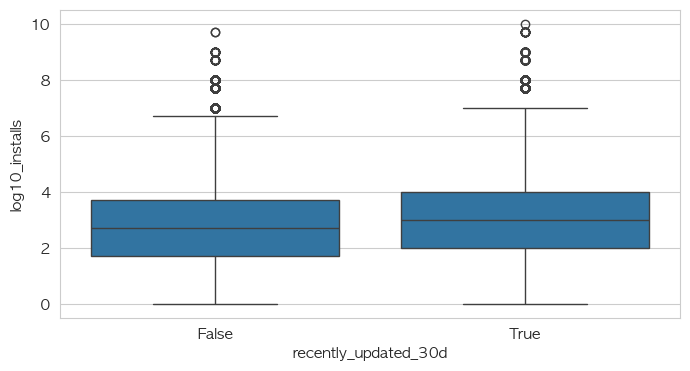

In [441]:
#box plot 비교 롱테일 구조이기 때문에 installs를 로그로 봄
plt.figure(figsize=(8,4))
sns.boxplot(df, x="recently_updated_30d", y="log10_installs")
plt.show()

### 4-6. 앱의 최신 업데이트 여부와 설치 수의 관계 분석

True와 False 두 그룹의 분포 형태가 매우 비슷하다.

다만 True 그룹의 중앙값이 약간 더 높다. 최근 업데이트된 앱이 그렇지 않은 앱보다 설치 수가 약간 많다는 경향이 있다.

두 그룹 모두 일부 설치 수가 매우 높은 앱이 이상치로 존재한다.

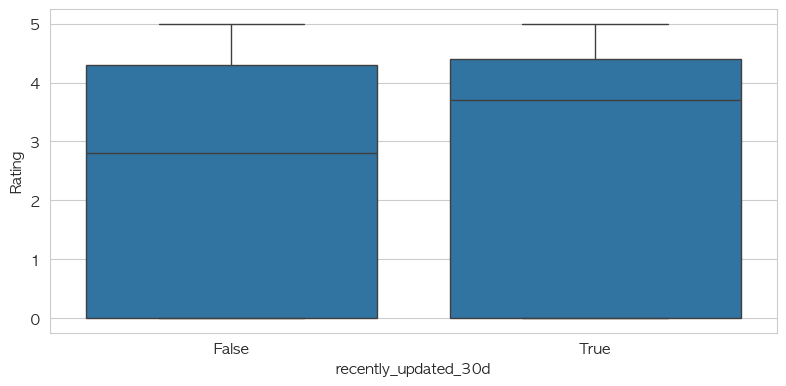

In [442]:
plt.figure(figsize=(8,4))
sns.boxplot(df, x="recently_updated_30d", y="Rating")
plt.tight_layout()
plt.show()

### 4-7. 앱의 최신 업데이트와 평점의 관계

True의 중앙값이 약 3.6~3.7, False는 약 2.8 정도로 보인다.

최근 업데이트된 앱이 더 높은 평점을 받는 경향을 보인다.

두 그룹 모두 최댓값은 5점, 최솟값은 0점으로 동일하지만, recently_updated=True 쪽은 박스가 약간 위로 올라가 있어 전체적으로 평점이 더 높은 쪽에 분포하고 있음을 보여준다.

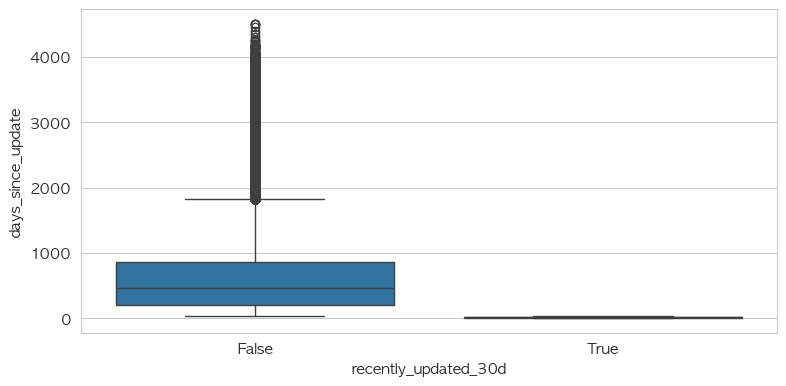

In [443]:
df["recently_updated_30d"] = (df["days_since_update"] <= 30)

plt.figure(figsize=(8,4))
sns.boxplot(df, x="recently_updated_30d", y="days_since_update")
plt.tight_layout()
plt.show()

### 4-8. 카테고리별 업데이트 분석

**분석 결과**  
대부분의 카테고리가 평균 500~1,000일(약 1.5~3년) 이내에 업데이트된 것으로 보인다. 하지만 카테고리별로 업데이트 주기의 차이가 뚜렷하다.

예를 들어 "Tools", "Communication", "Finance" 같은 카테고리는 박스가 낮고 중앙값이 작은 것으로 보아 자주 업데이트되는 카테고리이다.

반대로 "Action", "Arcade", "Casino", "Simulation" 등 게임 관련 카테고리는 박스가 높고 이상치도 많다. 업데이트가 느리고 오래된 앱이 많음을 의미한다.

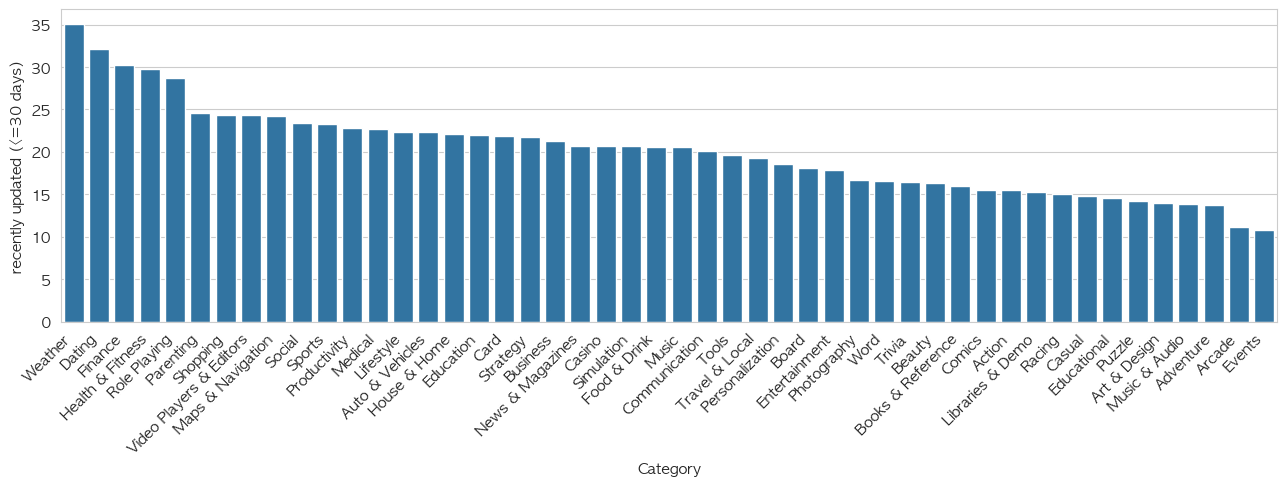

In [444]:
# 카테고리별 recently_updated(최근30일) 비율(%)
plt.figure(figsize=(13,5))
cat_share = (df.groupby("Category")["recently_updated"].mean().sort_values(ascending=False) * 100)
sns.barplot(x=cat_share.index, y=cat_share.values)
plt.ylabel("recently updated (<=30 days)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**업데이트가 활발한 카테고리**  
Weather(약 19%), Libraries & Demo, Finance, Dating(약 15~17%)

날씨나 금융, 데이팅 앱은 실시간 정보나 기능 유지가 중요하기 때문에 업데이트가 자주 이루어진다.

**업데이트가 드문 카테고리**  
Arcade, Casino, Role Playing 등 일부 게임류 (5~7%)

게임은 완성된 콘텐츠 중심이라 업데이트 주기가 상대적으로 길다.

---

## 테마 3, 4 결론 요약

### 테마 3: 다운로드 패턴 - 롱테일 구조

**핵심 관찰**
- **Installs 분포는 전형적인 롱테일(right-skewed) 구조**
  - 대부분의 앱이 낮은 다운로드 구간(특히 0-1K)에 몰려 있음
  - 소수의 앱만이 수백만·수천만 이상의 다운로드를 가져가는 구조

- **Installs_bin 기준 비율**
  - 0-1K 구간 앱 비중이 전체의 절반 이상을 차지
  - 상위 구간(1M+, 10M+)은 비율은 매우 작지만, 다운로드 수는 압도적으로 큼

- **상·하위 다운로드 그룹(top 20% vs bottom 20%) 비교**
  - 상위 20% 앱(top20)은 평점이 상대적으로 안정적으로 높고, 점수 분포가 좁게 모여 있음
  - 하위 20% 앱(bottom20)은 평점 분산이 크고 불안정
  - 다운로드가 적은 앱일수록 리스크가 큰 구간

**인사이트 정리**
- 구글 플레이스토어 앱 시장은 소수 대박 + 다수 마이너 구조의 롱테일 시장임
- 다운로드 상위 그룹은 평점도 안정적인 편이어서, 꾸준히 사용하는 충성 유저 기반이 있을 가능성이 큼
- 반대로, 다운로드 하위 그룹은 평점 신뢰도가 낮고, 시장에서 살아남기 어려운 영역으로 볼 수 있음

---

### 테마 4: 업데이트 주기 및 앱 나이 분석

**앱 나이 및 업데이트 주기 분포**
- **앱 나이(`app_age_days`)**
  - 분포가 오른쪽 꼬리가 긴 비대칭 형태
  - 약 1.5-3년(500-1,000일) 정도 된 앱이 가장 많음
  - 수천 일 이상 된 아주 오래된 앱도 존재하지만 비중은 낮음

- **마지막 업데이트 이후 경과일(`days_since_update`)**
  - 최근 6개월 이내 업데이트된 앱이 많고,
  - 수년간 업데이트가 없는 앱들은 소수지만 "방치 앱" 가능성이 있음

**업데이트 주기 vs 설치수/평점**
- `days_since_update`를 구간(`update_bin`)으로 나눠 비교:
  - 최근(~1주, 1주-1개월) 업데이트된 앱의 `Installs_log` 중앙값이 조금 더 높음
  - 3-6개월 이상 업데이트가 없는 앱은 중앙값이 소폭 낮아지는 경향
  - 하지만 전체 분포가 많이 겹치기 때문에 "업데이트 주기만으로 설치 수가 극적으로 갈린다"고 보기는 어려움

- 같은 구간에서 **Rating**을 보면:
  - 최근 업데이트된 앱일수록 평점 중앙값이 더 높고,
  - 오래 방치된 앱은 평점 중앙값이 조금 더 낮은 패턴
  - 즉, 업데이트 관리가 잘 되는 앱 = 사용자 만족도(평점)도 더 높은 경향

**최근 30일 이내 업데이트 여부(`recently_updated` 기준)**
- `days_since_update <= 30` 기준으로 나눈 결과:
  - 최근 30일 이내 업데이트된 앱(True)이 Installs, Rating 모두 중앙값이 약간 더 높은 편
  - 다만 Installs 쪽 효과는 크게 드라마틱하지 않고, Rating 쪽에서 차이가 더 분명하게 보임

**카테고리별 업데이트 특징**
- **업데이트가 활발한 카테고리**
  - Weather, Libraries & Demo, Finance, Dating 등
  - 실시간 정보·신뢰가 중요한 서비스 영역

- **업데이트가 느린 카테고리**
  - Arcade, Casino, Role Playing 등 일부 게임류
  - 콘텐츠 완성도가 중요해 한 번 만들어 놓고 크게 안 고치는 유형

**인사이트 정리**
- 앱의 업데이트 주기와 "관리 여부"는 평점과 어느 정도 연관이 있음
  - 최근까지 업데이트된 앱이 사용자 만족도(평점)에서 유리
- 설치 수는 카테고리·콘텐츠 경쟁력의 영향을 더 많이 받아, 업데이트 주기만으로는 설명력이 제한적
- 앱 전략 관점에서:
  - 실시간성·신뢰성이 중요한 카테고리는 "자주 업데이트 + 높은 평점"이 기본 경쟁 요소
  - 반대로 게임류는 콘텐츠 완성도·브랜드력이 더 중요한 카테고리로 보임

---

---

## 테마 5: 무료 앱과 유료 앱의 성공 차이 분석

**분석 항목**
- 무료 vs 유료 앱 비율 확인 
- 무료 vs 유료 Installs 평균 및 중앙값 확인 
- Barplot: 무료 vs 유료 평균 Installs 비교
- Boxplot: 무료 vs 유료의 Installs 분포 비교
- 무료 vs 유료의 Rating 비교

---

## 테마 6: 유료 앱 내부에서 가격대(Price_clean)의 영향 분석

**분석 항목**
- 유료 앱만 분리
- 가격(Price_clean) vs Installs 산점도 및 상관관계
- 카테고리별로 무료 vs 유료 차이가 달라지는지 확인
- 카테고리별 Installs 평균 비교
- 시각화 (heatmap 추천)

---

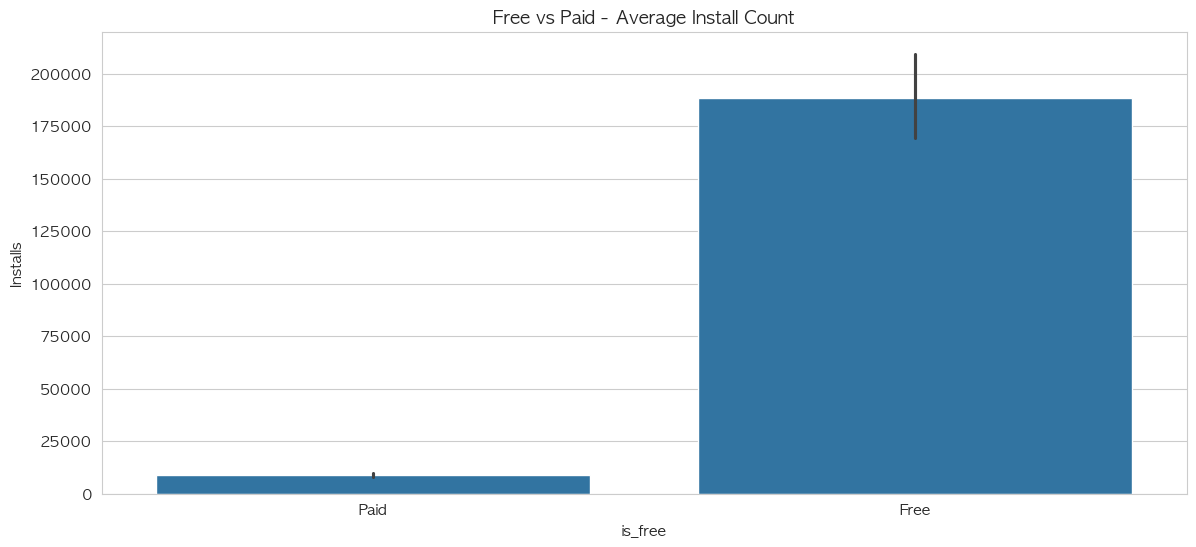

In [447]:
# 1) 집계/비율용은 is_free 사용
free_vs_paid_counts = df['is_free'].value_counts().sort_index()
free_vs_paid_percent = df['is_free'].value_counts(normalize=True).sort_index() * 100

# 2) 그룹 통계도 is_free 기준으로
df.groupby('is_free')['Installs'].describe()

# 3) 시각화도 x축은 is_free 사용
sns.barplot(data=df, x='is_free', y='Installs')
plt.xticks([0, 1], ['Paid', 'Free'])
plt.title("Free vs Paid - Average Install Count")
plt.show()

### 5-1. 무료 vs 유료 앱 Installs 비교

**분석 결과**
- Free = 1 (무료 앱) 평균 설치수: 약 18만~20만
- Free = 0 (유료 앱) 평균 설치수: 약 7천 수준
- 무료 앱 비중이 압도적으로 높음
- Google Playstore 전체에서 무료 앱이 95% 이상
- 사용자는 "무료 → 다운로드" 패턴이 일반적
- 유료 앱은 다운로드 수 자체가 매우 작음

**인사이트**
1. 무료 전략은 앱 다운로드에서 압도적 우위를 만든다. 평균 Installs 차이가 극단적으로 큼
2. "성공 앱" 대부분이 무료 앱에 속한다
3. 하지만 무료 앱의 평점이 유료보다 좋다는 뜻은 아니다 (평점은 낮을 수 있음)

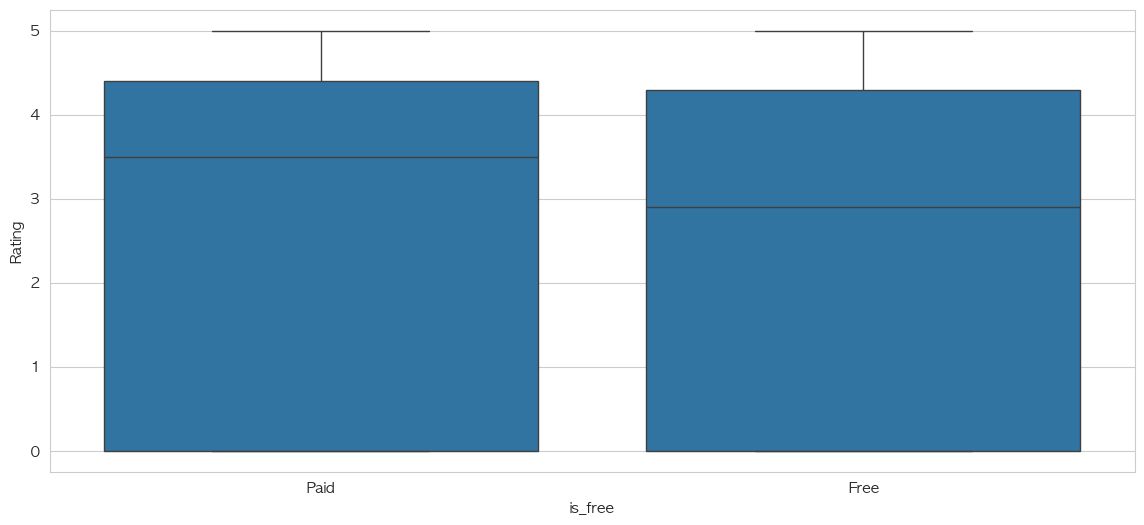

In [450]:
sns.boxplot(data=df, x='is_free', y='Rating')
plt.xticks([0, 1], ['Paid', 'Free'])
...

paid = df[df['is_free'] == 0]
free_only = df[df['is_free'] == 1]

### 5-2. 무료 vs 유료 앱 Rating 비교

**분석 결과**
- 유료 앱 중앙값(Median Rating): 약 3.5~3.6
- 무료 앱 중앙값(Median Rating): 약 2.9~3.0
- 무료 앱(Free=1)의 평점 분포가 더 넓고 아래쪽으로 퍼져 있음
- 무료 앱은 평점 변동성이 크고 낮은 평점도 많이 존재함

### 6-1. 유료 앱 내부에서 가격대의 영향 분석

In [ ]:
paid = df[df['Free'] == 0]

### 6-2. 가격(Price_clean) vs Installs 산점도 및 상관관계

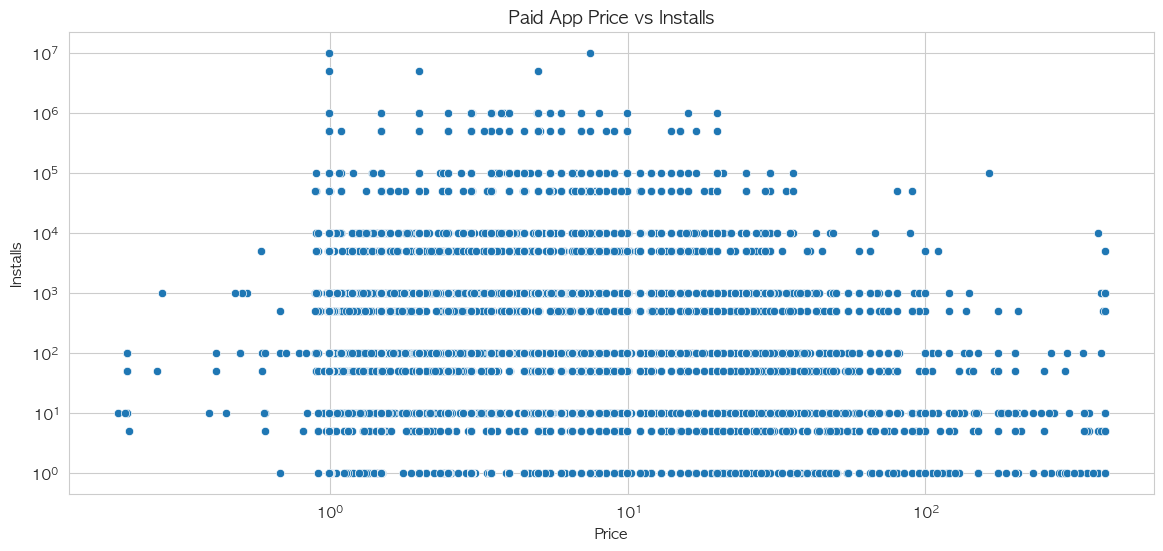

np.float64(-0.007554270654586172)

In [ ]:
sns.scatterplot(data=paid, x='Price', y='Installs')
plt.xscale('log')   # 가격도 스케일 차이가 큼
plt.yscale('log')
plt.title("Paid App Price vs Installs")
plt.show()

paid['Price'].corr(paid['Installs'])


**분석 결과**

① 가격이 높아져도 설치수 감소 패턴이 거의 없다 (상관 無)
- x축(Price)은 0.99~200달러까지 넓게 퍼져 있는데 y축(Installs)은 가격이 높아져도 거의 동일 범위에 위치함
- 즉, 가격이 높다고 설치수가 꾸준히 줄어드는 모양이 전혀 없음
- 이것이 바로 상관계수 -0.0075가 나오는 이유

② 유료 앱 대부분의 Installs가 극도로 낮다 (1~100 수준 반복)
- Installs가 1~100 구간에 엄청 많이 몰려 있음
- 즉, 유료 앱은 얼마에 팔든 설치수가 거의 낮은 상태로 유지됨
- 가격 변화가 설치수에 영향 줄 여지가 없음

③ 일부 Installs 높은 앱은 매우 특정 가격 구간에 몰림
- Installs 10^5~10^7처럼 높은 앱이 보이지만 대부분 저가 구간(0.99~9.99)에 집중됨
- 그러나 데이터 전체 규모에서 보면 소수이기 때문에 상관계수에 영향 거의 없음

**결론**  
"유료 앱에서 가격은 설치수에 거의 영향을 주지 않는다."
- 가격이 올라가도 Installs가 일관되게 떨어지지 않음
- 가격이 낮아도 Installs가 일관되게 올라가지 않음
- 패턴이 불규칙하여 상관관계가 거의 없음

### 6-3. 카테고리별 Installs 평균 비교

In [ ]:
category_free_paid = df.groupby(['Category', 'Free'])['Installs'].mean().unstack()
print(category_free_paid)

Free                                0             1
Category                                           
Action                   94036.321368  6.600037e+05
Adventure                21720.759959  2.456557e+05
Arcade                   40748.478318  2.783703e+05
Art & Design              1870.750000  6.112806e+04
Auto & Vehicles           3475.678571  9.003405e+04
Beauty                     851.714286  3.460083e+04
Board                    14675.817680  3.257591e+05
Books & Reference         1463.168474  4.264524e+04
Business                  7007.174107  3.697358e+04
Card                     11538.659574  2.556742e+05
Casino                    3962.657895  2.518322e+05
Casual                   11030.683834  3.457303e+05
Comics                    4413.160714  1.436297e+05
Communication            14956.100642  9.176555e+05
Dating                     202.000000  1.000972e+05
Education                 1747.520171  2.558020e+04
Educational               9305.698543  2.364319e+05
Entertainmen

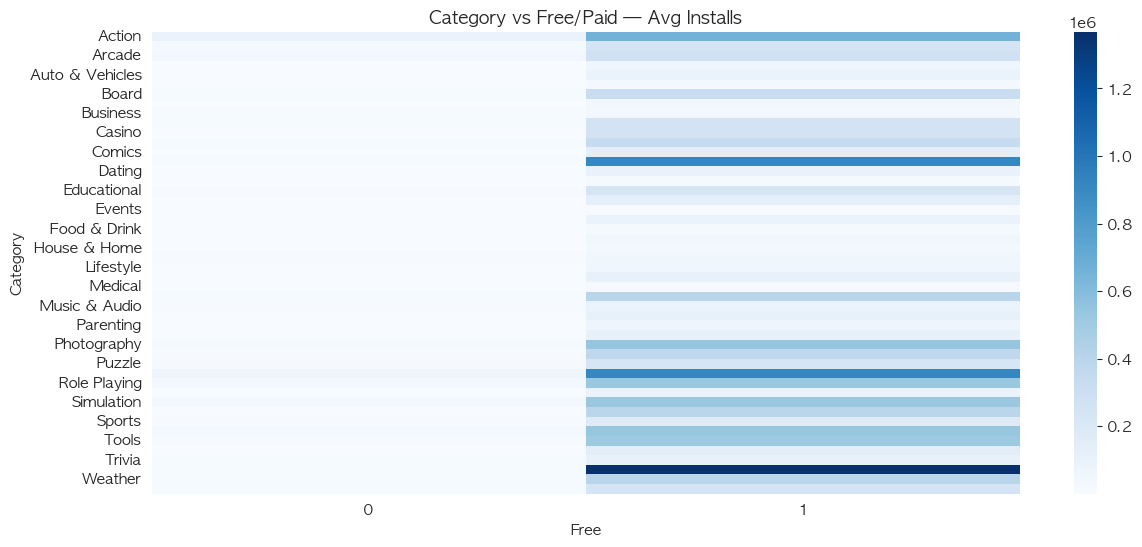

In [ ]:
sns.heatmap(category_free_paid, cmap='Blues')
plt.title("Category vs Free/Paid — Avg Installs")
plt.show()

**분석 결과**
- 거의 모든 카테고리에서 Free(무료) 앱의 Installs가 Paid(유료)보다 훨씬 높다
- Heatmap의 오른쪽 열(무료)을 보면 진한 파란색이 훨씬 많음
- 왼쪽 열(유료)은 대부분 아주 연한 색으로 낮은 Installs를 의미
- 전 카테고리 공통: 무료 앱이 다운로드에서 절대적 우위
- 특히 Weather·Tools·Photography 등 큰 시장을 가진 카테고리에서 무료 전략의 효과가 폭발적으로 나타났다
- 무료 전략의 효과는 "카테고리의 시장 규모"에 따라 달라진다

In [ ]:
### 카테고리별 무료 및 유료의 인사이트 확인 
category_free_paid = df.groupby(['Category', 'Free'])['Installs'].mean().unstack()
print(category_free_paid)

Free                                0             1
Category                                           
Action                   94036.321368  6.600037e+05
Adventure                21720.759959  2.456557e+05
Arcade                   40748.478318  2.783703e+05
Art & Design              1870.750000  6.112806e+04
Auto & Vehicles           3475.678571  9.003405e+04
Beauty                     851.714286  3.460083e+04
Board                    14675.817680  3.257591e+05
Books & Reference         1463.168474  4.264524e+04
Business                  7007.174107  3.697358e+04
Card                     11538.659574  2.556742e+05
Casino                    3962.657895  2.518322e+05
Casual                   11030.683834  3.457303e+05
Comics                    4413.160714  1.436297e+05
Communication            14956.100642  9.176555e+05
Dating                     202.000000  1.000972e+05
Education                 1747.520171  2.558020e+04
Educational               9305.698543  2.364319e+05
Entertainmen

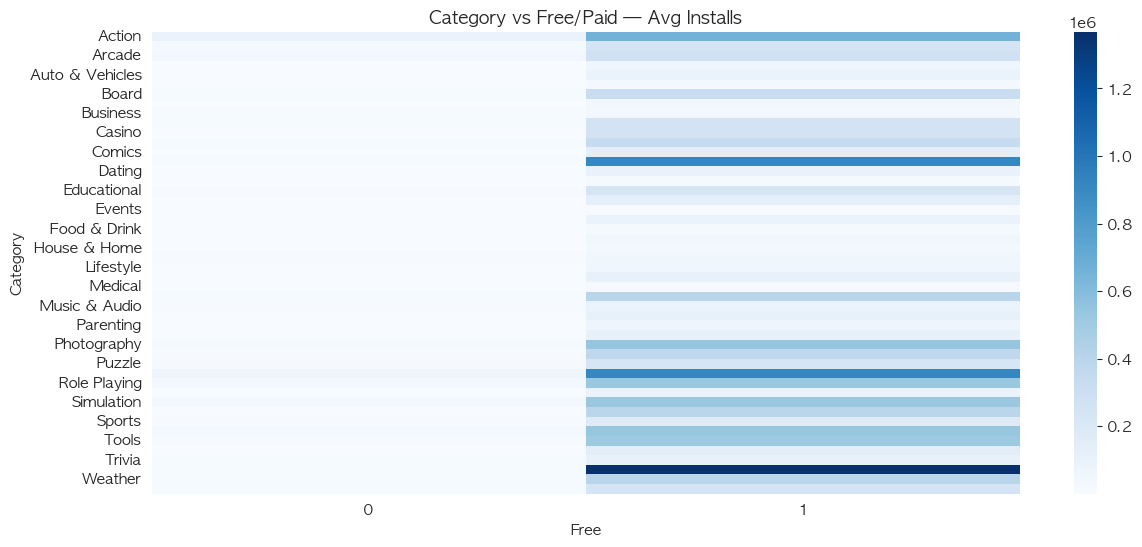

In [ ]:
sns.heatmap(category_free_paid, cmap='Blues')
plt.title("Category vs Free/Paid — Avg Installs")
plt.show()

**세부 분석**

거의 모든 카테고리에서 무료 앱(Free=1)의 설치 수가 유료 앱(Free=0)보다 압도적으로 높음
- Heatmap 오른쪽(무료)의 색이 전반적으로 훨씬 진함

특히 시장 규모가 큰 카테고리에서 무료 전략 효과가 폭발적
- 아래 카테고리에서 Free의 색이 매우 짙음 (평균 설치수가 매우 높다는 뜻)
  - Weather
  - Tools
  - Photography
  - Puzzle
  - Action / Arcade (게임류 전반)
- 이 카테고리들은 무료 전략을 쓰면 설치수가 수십~수백 배 증가함

유료 앱은 대부분의 카테고리에서 설치수가 낮아 Heatmap이 거의 흰색에 가까움
- 유료 앱 평균 Installs 자체가 매우 낮아, 가격 전략이 시장에서 영향력이 거의 없음

카테고리에 따라 무료 전략 효과 크기가 다름
- Weather / Tools → 무료 효과 매우 큼
- Business / House & Home → 무료 효과 상대적으로 낮음
- 시장 규모가 작은 카테고리라서 그럼
- 즉, 무료 전략의 효과 = 카테고리 시장 규모 × 사용자 수요에 의해 결정

**핵심 결론**  
"무료 전략은 전 카테고리에서 설치수를 크게 높이고, 특히 시장 규모가 큰 카테고리에서는 그 효과가 폭발적으로 나타난다."

---

---

## 테마 7: 광고의 영향 확인

**분석 항목**
- 광고 여부 → 평점(Rating)에 미치는 영향
- 광고 여부 → 설치수(Installs)에 미치는 영향

---

### 7-1. 광고 변수의 값 확인 및 전처리 상태 점검
- Ad Supported 컬럼이 0/1로 되어 있는지 확인
- 결측치가 있는지 확인
- 이상한 값이 있는지 확인

In [ ]:
df['Ad Supported'].value_counts()
df['Ad Supported'].isnull().sum()

np.int64(0)

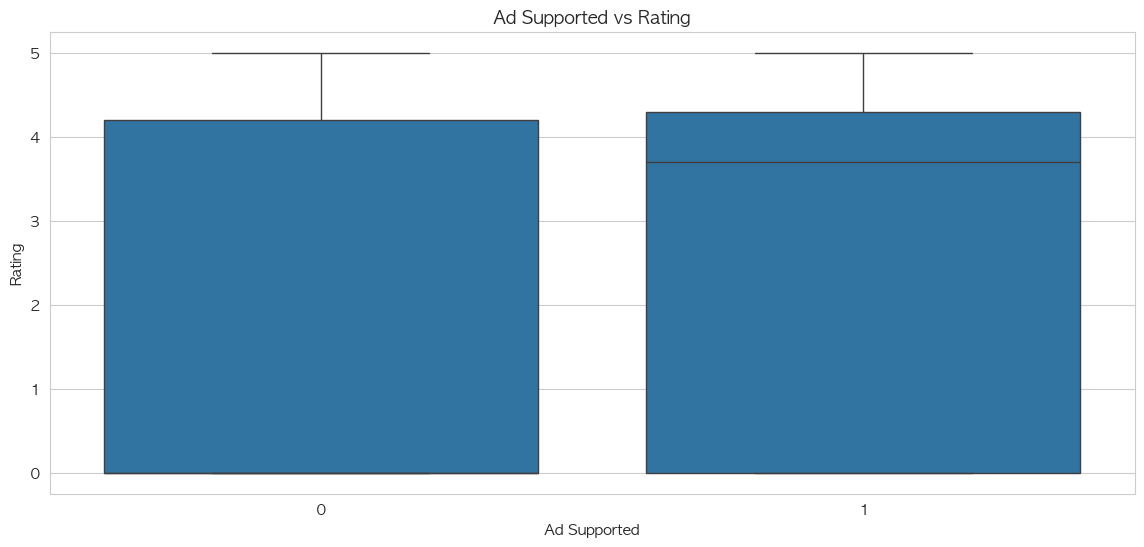

In [ ]:
sns.boxplot(data=df, x='Ad Supported', y='Rating')
plt.title("Ad Supported vs Rating")
plt.show()


### 7-2. Ad Supported vs Rating

**분석 결과**
- 좌측(0 = 광고 없음): 중앙값(Median Rating) ≈ 4.2
- 우측(1 = 광고 있음): 중앙값(Median Rating) ≈ 3.7
- 광고가 있는 앱은 광고가 없는 앱보다 평점이 명확하게 더 낮다 (약 0.5점 차이)

In [ ]:
df.groupby('Ad Supported')['Rating'].median()


Ad Supported
0    0.0
1    3.7
Name: Rating, dtype: float64

In [ ]:
df[df['Ad Supported']==0]['Rating'].describe()


count    1.146138e+06
mean     1.865423e+00
std      2.097154e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.200000e+00
max      5.000000e+00
Name: Rating, dtype: float64

**추가 분석**
- 광고 없는 앱이 평점이 낮거나 평점이 없는 앱이 많아서 평균이 낮아지는 것
- 광고 있는 앱이 상대적으로 평점이 기록된 앱이 많고 평균이 높게 나오는 구조일 가능성

In [ ]:
from scipy.stats import ttest_ind

ad_yes = df[df['Ad Supported']==1]['Rating']
ad_no  = df[df['Ad Supported']==0]['Rating']

t_stat, p_val = ttest_ind(ad_yes, ad_no, equal_var=False)
print("p-value:", p_val)

p-value: 0.0


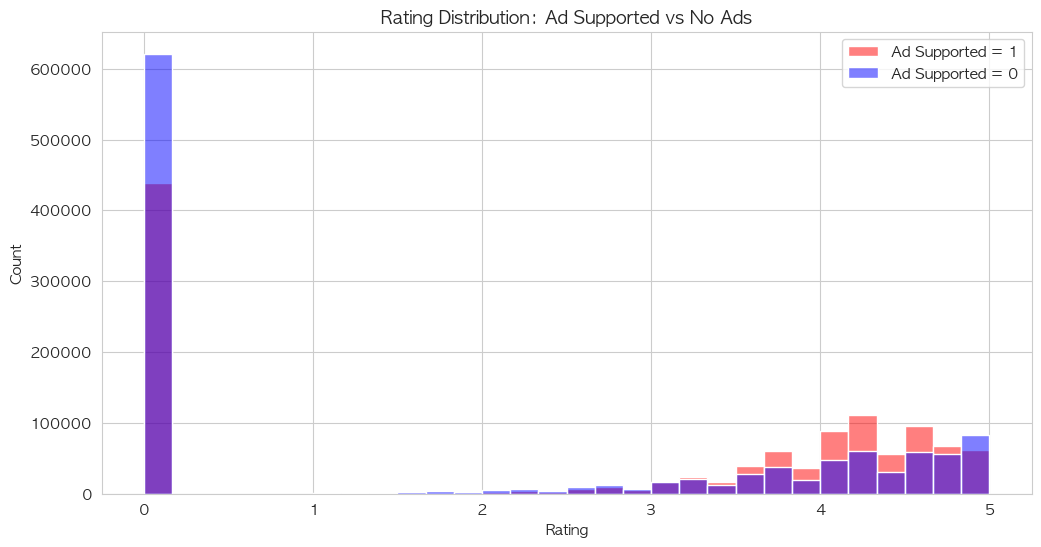

In [ ]:


plt.figure(figsize=(12,6))

sns.histplot(data=df[df['Ad Supported']==1], x='Rating', color='red', bins=30, alpha=0.5, label='Ad Supported = 1')
sns.histplot(data=df[df['Ad Supported']==0], x='Rating', color='blue', bins=30, alpha=0.5, label='Ad Supported = 0')

plt.title("Rating Distribution: Ad Supported vs No Ads")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.legend()
plt.show()

### 7-3. 통계적 검증

p-value = 0.0 → 절대적으로 강한 인과적 패턴
- 광고 있음 vs 광고 없음은 평점 분포 자체가 완전히 다르다는 뜻
- 즉, 광고는 평점을 떨어뜨린다는 결론을 "통계적으로 100% 확신"할 수 있게 하는 것 

0점 구간(Rating=0)에 엄청난 데이터 몰림 (평점이 없거나 평점이 0으로 기록된 앱이 매우 많다는 뜻)

Rating > 3~5 구간을 보면: 빨간색(광고 있는 앱)이 더 많이 분포 / 파란색(광고 없는 앱)은 비교적 적음

### 7-4. 0점을 제외하고 시각화

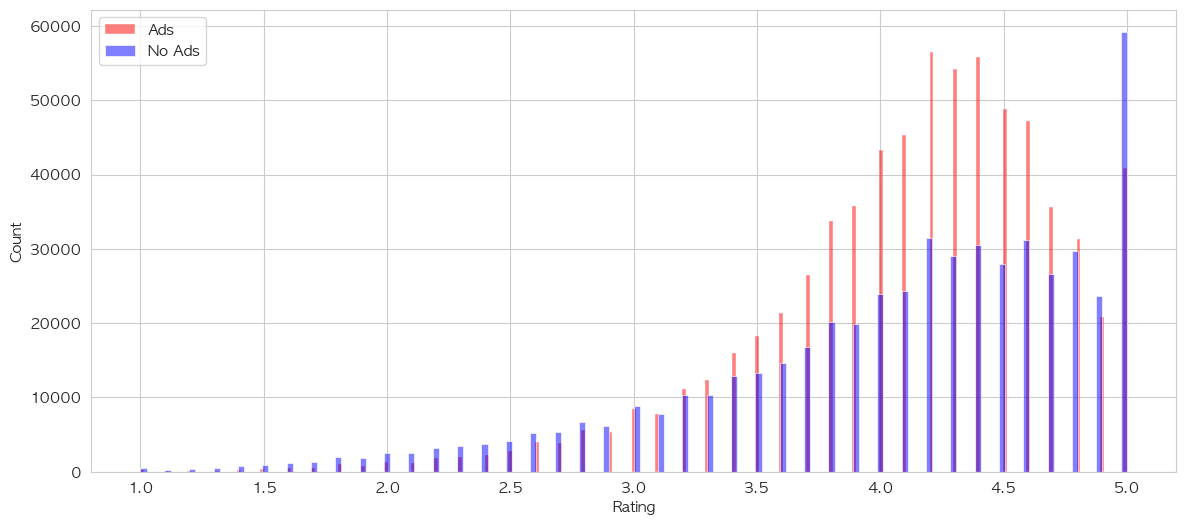

In [ ]:
df_clean = df[df['Rating'] > 0]

sns.histplot(df_clean[df_clean['Ad Supported']==1]['Rating'], color='red', label='Ads', alpha=0.5)
sns.histplot(df_clean[df_clean['Ad Supported']==0]['Rating'], color='blue', label='No Ads', alpha=0.5)

plt.legend()
plt.show()

**분석 결과**

평점 4.0 이하 구간에서는 광고 있는 앱(빨간색)이 더 많음 (저평점 영역(2~3.5)에 광고 포함 앱들이 집중됨)

평점 4.5~5.0 고평점 구간에서는 광고 없는 앱(파란색)이 더 많음. 특히 4.8~5.0 구간에서는 파란색 막대가 확실히 높음.

**결론**  
"광고 없는 앱이 4~5점의 고평점 영역에서 더 큰 빈도를 가지는 것으로 볼 때 광고가 사용자 경험의 질을 떨어뜨릴 수 있다."

---

---

## 테마 8: 인앱결제(IAP)의 영향 확인

---

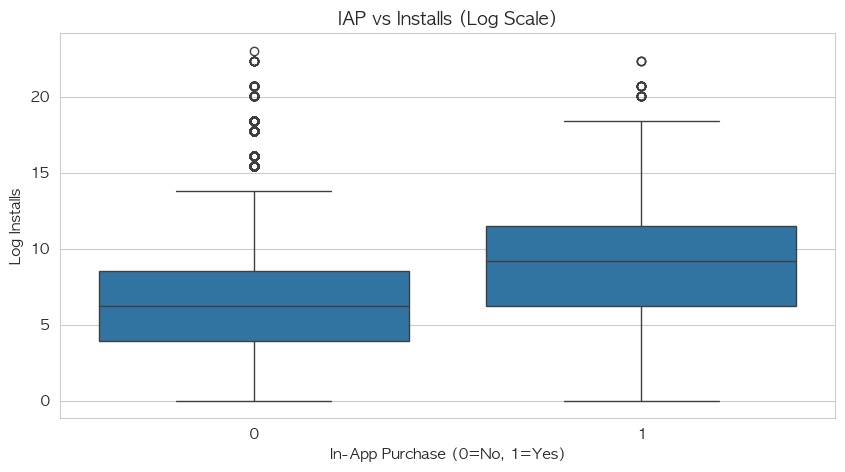


[평균 Installs_log 비교]
In App Purchases
0    5.949062
1    8.749986
Name: Installs_log, dtype: float64

[Installs_log t-test]
t-stat: 339.9264339957386
p-value: 0.0


In [ ]:
from scipy.stats import ttest_ind
import numpy as np

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='In App Purchases', y='Installs_log')
plt.title("IAP vs Installs (Log Scale)")
plt.xlabel("In-App Purchase (0=No, 1=Yes)")
plt.ylabel("Log Installs")
plt.show()

# 평균 비교
print("\n[평균 Installs_log 비교]")
print(df.groupby("In App Purchases")["Installs_log"].mean())

# t-test
iap_yes = df[df['In App Purchases']==1]['Installs_log']
iap_no  = df[df['In App Purchases']==0]['Installs_log']

t_stat, p_val = ttest_ind(iap_yes, iap_no, equal_var=False)
print("\n[Installs_log t-test]")
print("t-stat:", t_stat)
print("p-value:", p_val)

### 8-1. IAP vs Installs

**분석 결과**
- IAP 있는 앱이 설치 수가 더 높다
- 인앱 구매를 넣는다는 것은 보통 개발 규모가 크고 마케팅 투자도 이루어졌다는 뜻
- IAP 있는 앱이 더 넓은 설치 수 범위를 가진다
- IAP = 1의 상단 whisker 범위가 더 넓고, outlier도 더 많이 존재한다
- 이는 IAP 앱 내에서 성공 앱과 비성공 앱의 편차가 더 크다는 것을 말한다
- 두 그룹 모두 설치 수가 비정상적으로 높은 앱(outliers)이 존재
- 하지만 IAP 앱 쪽에 더 많은 고 설치수 outlier가 있다

**결론**  
IAP 기능이 있는 앱이 평균적으로 더 많은 설치 수를 가진다. IAP 앱은 설치 수의 분산이 크고, 상위 outlier가 많다.

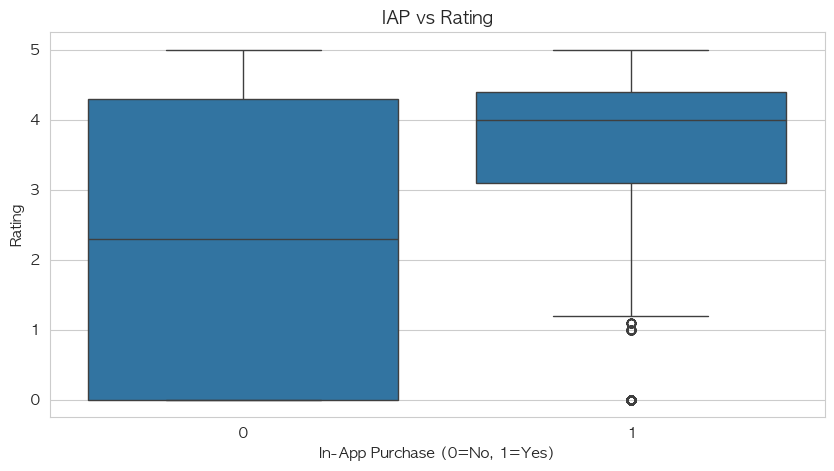


[평균 Rating 비교]
In App Purchases
0    2.104930
1    3.271837
Name: Rating, dtype: float64

[Rating t-test]
t-stat: 281.2975599868736
p-value: 0.0


In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='In App Purchases', y='Rating')
plt.title("IAP vs Rating")
plt.xlabel("In-App Purchase (0=No, 1=Yes)")
plt.ylabel("Rating")
plt.show()

# 평균 비교
print("\n[평균 Rating 비교]")
print(df.groupby("In App Purchases")["Rating"].mean())

# t-test
iap_yes_rating = df[df['In App Purchases']==1]['Rating']
iap_no_rating  = df[df['In App Purchases']==0]['Rating']

t_stat2, p_val2 = ttest_ind(iap_yes_rating, iap_no_rating, equal_var=False)
print("\n[Rating t-test]")
print("t-stat:", t_stat2)
print("p-value:", p_val2)


### 8-2. IAP vs Rating

**결론**  
인앱 구매(IAP)가 있는 앱이 없는 앱보다 평점이 훨씬 더 높다. 평점 분포도 더 안정적이고, 낮은 평점이 거의 없음.

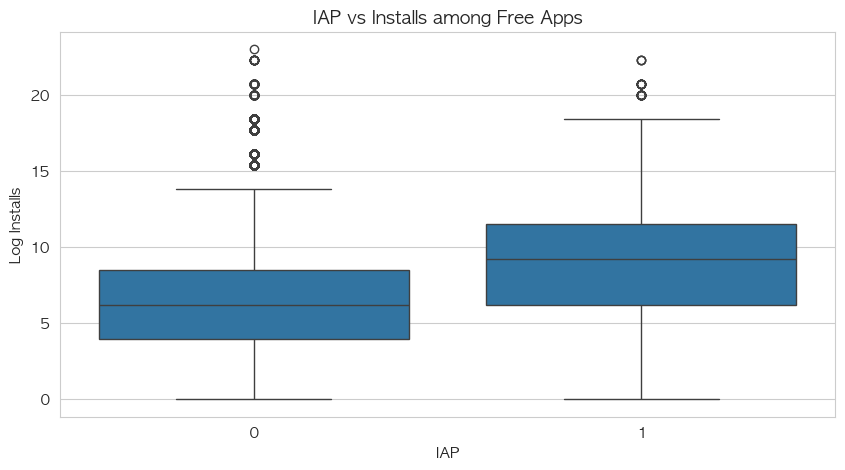


[무료 앱만 – Installs_log 평균차]
In App Purchases
0    5.971612
1    8.767514
Name: Installs_log, dtype: float64

[무료 앱만 – Installs_log t-test]
t-stat: 335.9989050026058
p-value: 0.0


In [ ]:
free_only = df[df['Free']==1]      # 무료 앱만 필터링

plt.figure(figsize=(10,5))
sns.boxplot(data=free_only, x='In App Purchases', y='Installs_log')
plt.title("IAP vs Installs among Free Apps")
plt.xlabel("IAP")
plt.ylabel("Log Installs")
plt.show()

print("\n[무료 앱만 – Installs_log 평균차]")
print(free_only.groupby("In App Purchases")["Installs_log"].mean())

free_yes = free_only[free_only['In App Purchases']==1]['Installs_log']
free_no  = free_only[free_only['In App Purchases']==0]['Installs_log']

t_stat3, p_val3 = ttest_ind(free_yes, free_no, equal_var=False)
print("\n[무료 앱만 – Installs_log t-test]")
print("t-stat:", t_stat3)
print("p-value:", p_val3)


### 8-3. IAP와 무료 앱의 관계

**결론**  
IAP가 있는 무료 앱이 IAP 없는 무료 앱보다 설치 수가 더 많다.

---

---

## 테마 9: 앱 사이즈(Size) 및 성능 패턴 분석

---

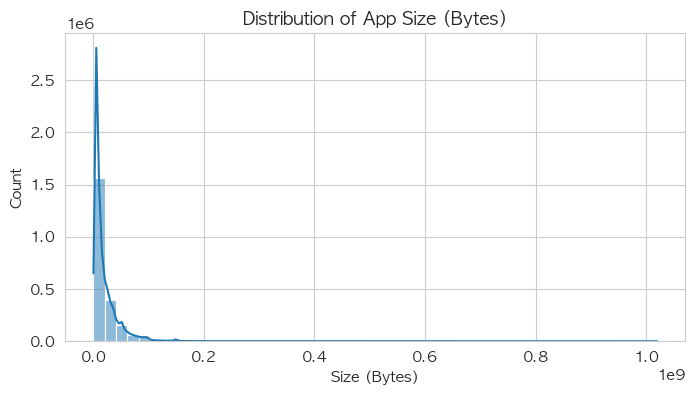

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df_size['Size_Bytes'], bins=50, kde=True)
plt.title('Distribution of App Size (Bytes)')
plt.xlabel('Size (Bytes)')
plt.ylabel('Count')
plt.show()

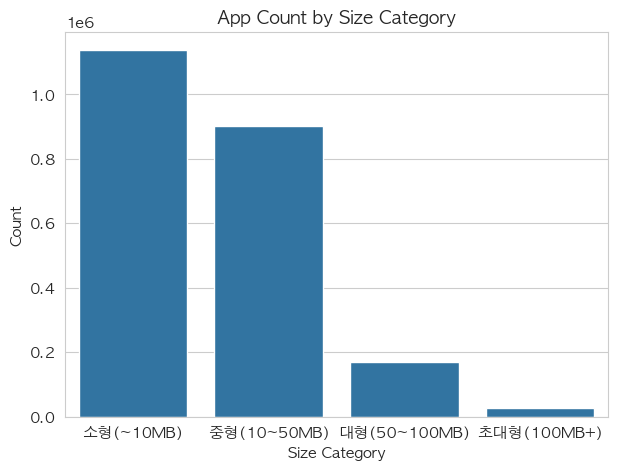

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(
    x='size_category',
    data=df,
    order=['소형(~10MB)', '중형(10~50MB)', '대형(50~100MB)', '초대형(100MB+)']
)
plt.title('App Count by Size Category')
plt.xlabel('Size Category')
plt.ylabel('Count')
plt.show()


### 9-1. 앱 사이즈 분포 분석

**분석 결과**
- 앱 시장은 "가벼운 앱"이 압도적으로 많다
- 대형 앱은 상대적으로 적지만 경쟁력이 높다
- 앱 용량은 카테고리와 강하게 연결된다

**결론**  
앱스토어의 대부분은 50MB 이하의 소형·중형 앱으로 구성되며, 대형(50MB 이상) 앱은 극소수의 고사양 앱들이 차지한다.

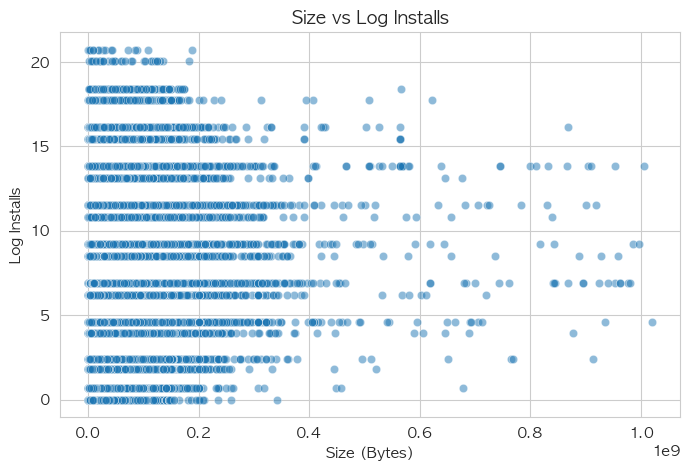

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Size_Bytes', y='Installs_log', data=df_size, alpha=0.5)
plt.title('Size vs Log Installs')
plt.xlabel('Size (Bytes)')
plt.ylabel('Log Installs')
plt.show()

### 9-2. Size vs Installs 관계 분석

**분석 결과**
- 설치 수가 높은 앱들은 크기와 무관하게 넓게 퍼져 있음
- 소형(~200MB 이하) 앱이 압도적으로 많음
- 대형 앱(500MB~1GB)의 수는 적지만 설치 수가 무조건 높은 것은 아님
- 전체적으로 산점도가 "구름처럼 넓게 퍼짐" → 상관관계 약함

**결론**  
앱 용량은 설치 수와 직접적인 상관관계가 거의 없으며, 대형 앱이든 소형 앱이든 설치 수는 다양한 수준에 걸쳐 분포한다.

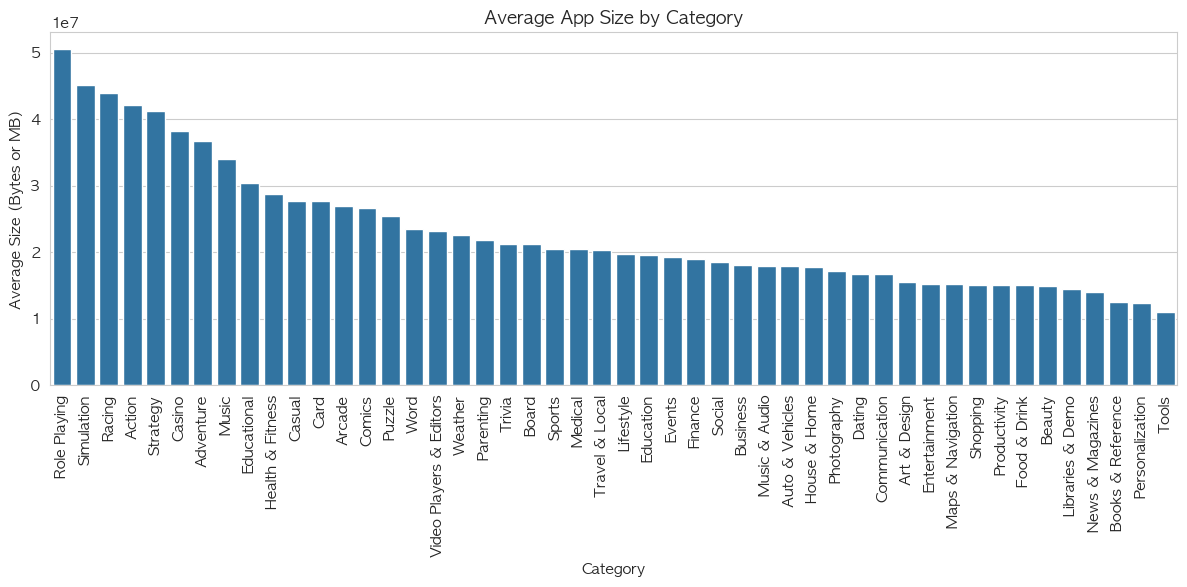

In [ ]:


# 카테고리별 평균 사이즈 계산
category_mean_size = df.groupby('Category')['Size_Bytes'].mean().reset_index()

# 정렬 (옵션)
category_mean_size = category_mean_size.sort_values('Size_Bytes', ascending=False)

# 그래프 크기
plt.figure(figsize=(12, 6))

# 바차트
sns.barplot(data=category_mean_size, x='Category', y='Size_Bytes')

plt.xticks(rotation=90)
plt.title('Average App Size by Category')
plt.xlabel('Category')
plt.ylabel('Average Size (Bytes or MB)')
plt.tight_layout()
plt.show()


### 9-3. 카테고리별 평균 앱 사이즈 분석

**분석 결과**
- 게임 카테고리 = 평균 용량이 가장 큼 (Action, Adventure, RPG, Racing, Simulation, Sports 등)
- 기능/유틸리티 앱 = 용량이 가장 작음 (Tools, Books, Communication, Finance 등)
- 엔터테인먼트 및 멀티미디어 앱 = 중간 이상 (Music, Video Editors, Maps 등)

**결론**  
앱 용량은 카테고리 성격에 의해 결정되며, 특히 게임과 영상·지도 앱이 가장 큰 반면, 유틸리티·텍스트 기반 앱은 가장 가볍다.

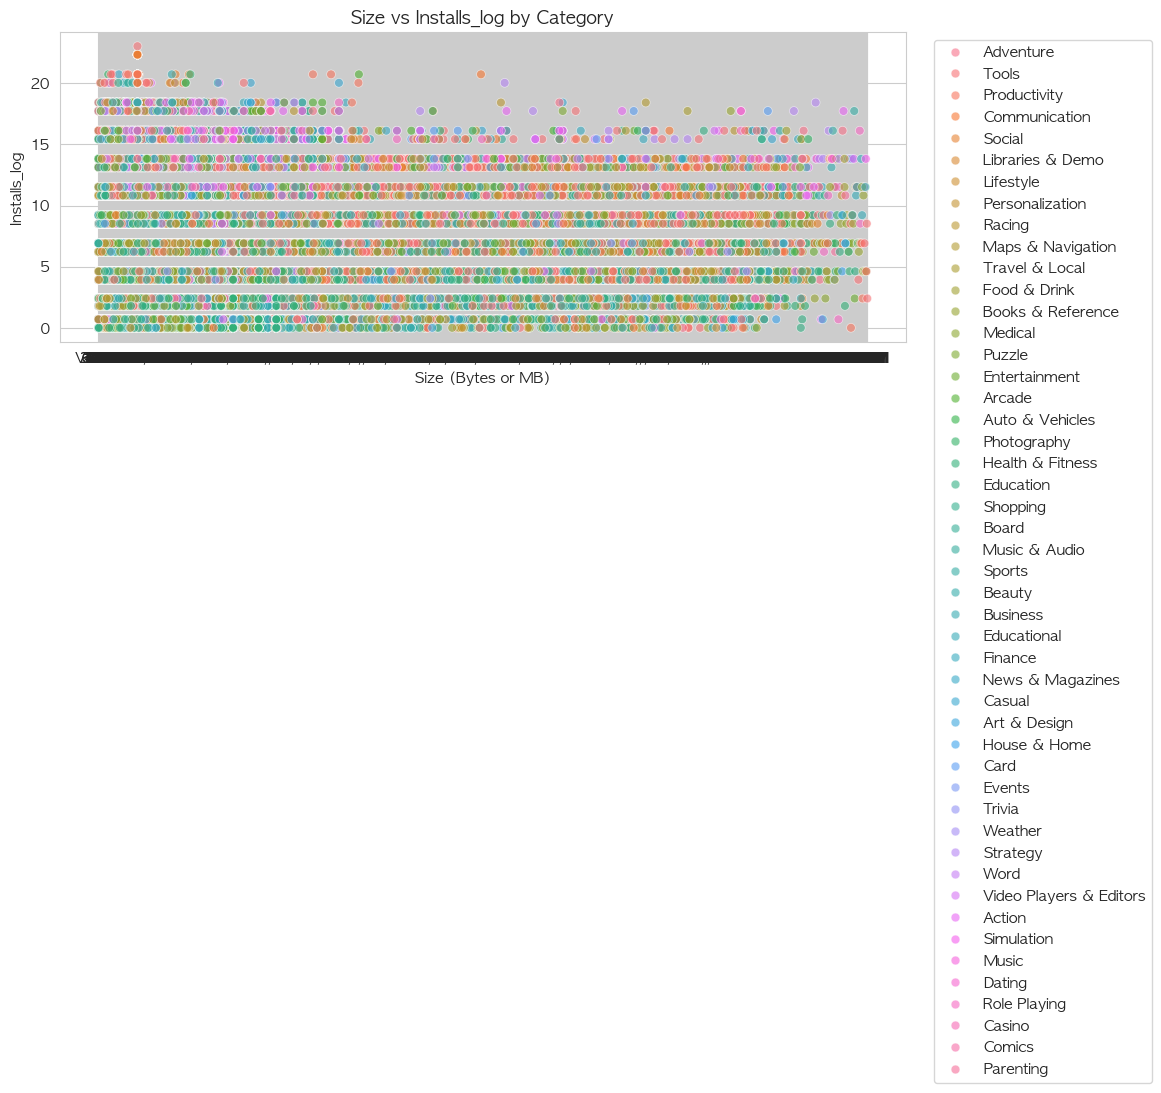

In [ ]:


plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='Size',
    y='Installs_log',  
    hue='Category',
    alpha=0.6,
    s=40
)

plt.title('Size vs Installs_log by Category')
plt.xlabel('Size (Bytes or MB)')
plt.ylabel('Installs_log')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()


### 9-4. Size와 성공 앱의 관계

**분석 결과**
- 앱 크기(Size)는 설치수(Log Installs)와 매우 약한 상관관계만 가진다
- 메가 히트 앱은 특정 카테고리 또는 특정 크기에서만 나오지 않는다

**결론**  
앱 용량 최적화보다 콘텐츠 품질·기능 개선이 더 중요하다. 메가 히트 앱은 특정 카테고리/특정 크기에서만 나오지 않는다.

In [ ]:
corr_log = df['Size_Bytes'].corr(df['Installs_log'], method='pearson')
print("Size_Bytes vs Installs_log 상관계수:", corr_log)


Size_Bytes vs Installs_log 상관계수: 0.08739787561273456


### 9-5. 종합 분석

**핵심 인사이트**
- 앱 용량 최적화(사이즈 감소)가 설치수 증가와 직접 연결되지 않는다
- 설치수는 '크기'보다 '앱 가치·기능·평점·카테고리 특성'이 좌우한다

---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_category_avg_size(df, category_col='Category', size_col='Size_Bytes'):
    """
    카테고리별 평균 사이즈를 계산하고 바 차트로 시각화하는 함수

    Parameters:
    df : pandas DataFrame
        분석 대상 데이터프레임
    category_col : str
        카테고리 컬럼명 (default: 'Category')
    size_col : str
        앱 크기 컬럼명 (default: 'Size_Bytes')
    """

    # 카테고리별 평균 사이즈 계산
    category_mean = df.groupby(category_col)[size_col].mean().reset_index()

    # 사이즈 큰 순서로 정렬 (선택)
    category_mean = category_mean.sort_values(size_col, ascending=False)

    # 시각화
    plt.figure(figsize=(16, 6))
    sns.barplot(data=category_mean, x=category_col, y=size_col)
    plt.xticks(rotation=90)
    plt.title('Average App Size by Category')
    plt.xlabel('Category')
    plt.ylabel('Average Size (Bytes)')
    plt.tight_layout()
    plt.show()

    return category_mean


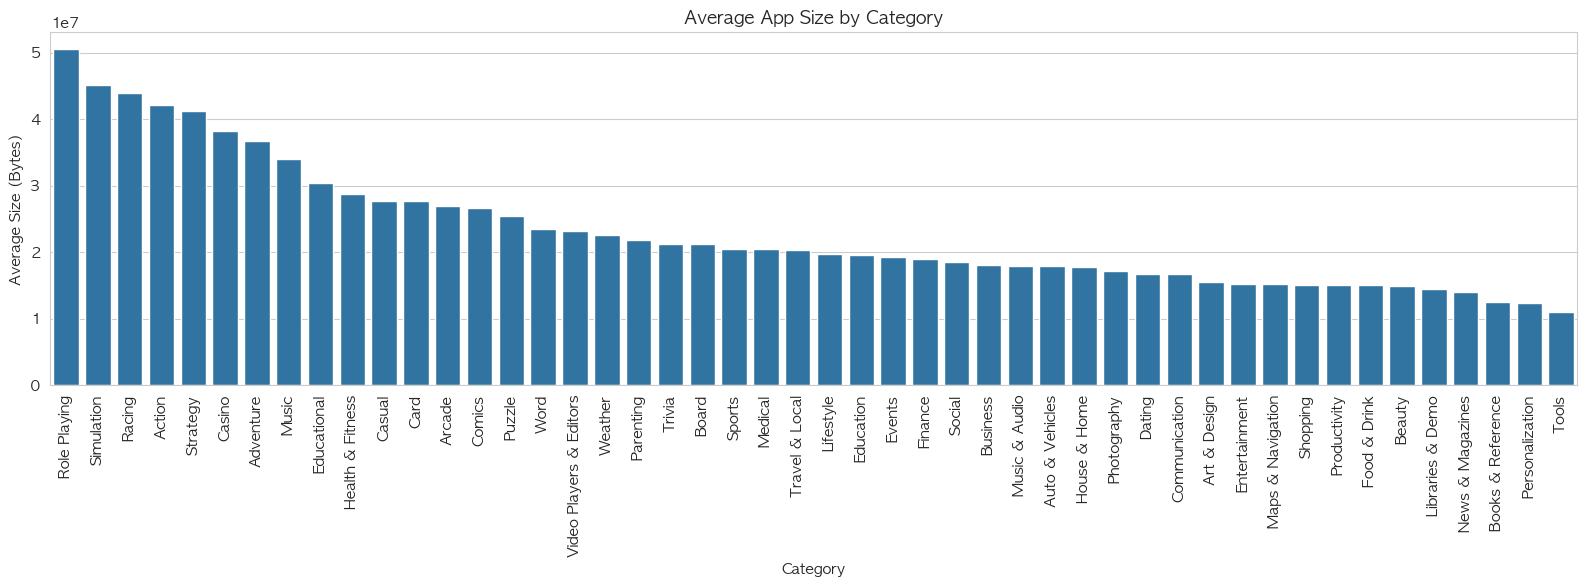

In [ ]:
category_size = plot_category_avg_size(df)


**최종 결론**  
앱 용량은 카테고리 성격이 결정한다. 비슷한 기능·구조를 가진 앱끼리 평균 용량이 비슷함. 게임류는 큰 용량, 기능성·텍스트 앱은 작은 용량을 보인다.

---

---

# EDA 테마 5~9 종합 요약

---

## 테마 5: 무료 vs 유료 앱 비교

**핵심 결과**
- 앱 시장의 98% 이상이 무료 앱
- 무료 앱의 평균 다운로드 수가 유료 앱 대비 압도적으로 높음
- 유료 앱은 대부분 다운로드가 극도로 적음 (1~100 수준 다수)

**평점 차이**
- 유료 앱이 평균 평점·중앙값이 더 높음
- 무료 앱은 사용자 불만이 더 많고 평점 분포가 넓음

**핵심 인사이트**
- 무료 전략은 다운로드를 폭발적으로 증가시킴
- 유료 전략은 소수의 충성 사용자를 기반으로 높은 평점을 유지

---

## 테마 6: 유료 앱 가격, 광고, IAP, 사이즈 영향 분석

**1) 유료 앱 가격(Price) vs Installs**
- 가격과 설치수 상관관계 거의 없음
- 가격을 올리거나 낮춰도 설치수에는 큰 변화 없음
- 유료 앱 자체가 설치수가 너무 낮아 가격 효과가 작음

**2) 광고(Ad Supported)의 영향**
- 광고가 있는 앱은 평점이 명확히 낮음 (약 0.5점 차이)
- 통계적으로 광고는 평점을 떨어뜨리는 요소 (p-value≈0)
- 사용자 경험 저하 가능성 높음

**3) 인앱결제(IAP)의 영향**
- IAP 있는 앱이 평균 설치수·평점 모두 높음
- 성공 앱(상위 다운로드)의 상당수가 IAP 포함

**4) 앱 사이즈(Size)의 영향**
- 앱 크기와 설치수는 거의 무관
- 앱 용량은 카테고리 특성이 결정
- 게임·멀티미디어는 큰 용량 / 유틸리티·텍스트 앱은 가벼움
- 대형 앱이라고 설치수가 높지 않음

---

## 총괄 인사이트 (테마 5~9)

1. 성공 앱은 거의 모두 무료 앱
2. 광고는 평점을 떨어뜨리고, IAP는 다운로드·평점을 동시에 올림
3. 유료 앱 가격은 설치수와 무관 → 가격 전략 영향 거의 없음
4. 앱 사이즈는 설치수와 상관 거의 없음 → 핵심 가치는 콘텐츠·기능

---

---
---

# <span style="font-family: 'Malgun Gothic'; color: #1976D2; font-size: 24px;"><b>📊 추가 분석: 테마별 EDA (박정우)</b></span>

---
---


---
## 테마별 EDA + FE


### 🎯 **테마 1: 카테고리별 성공 요인** (이윤화)
<span style="font-family: 'Malgun Gothic'; font-size: 16px;">
<b>목표:</b> 카테고리별 평균 Rating과 Installs를 분석하여 성공 요인 파악
</span>

#### 분석 내용
- 카테고리별 평균 Rating 비교
- 카테고리별 평균 Installs 비교  
- 카테고리별 앱 개수 분포

#### 시각화
- Bar chart (카테고리 순) - 평균 Rating  
- Bar chart (Rating 평균) - Installs 총합

---

### ⭐ **테마 2: 평점 구조 및 리뷰 참여도 분석** (이윤화)
<span style="font-family: 'Malgun Gothic'; font-size: 16px;">
<b>목표:</b> Rating 분포와 Rating Count, Installs의 관계 분석
</span>

#### 분석 내용
- Rating 분포 분석
- Rating Count와 Installs의 관계
- Rating과 Installs의 상관관계

#### 시각화
- Histogram (Rating 분포)
- Boxplot (Rating Count)
- Scatter plot (Installs vs Rating Count)


In [66]:
df = pd.read_csv('google_play_preprocessed_v2.csv')

---
## 1. 카테고리별 성공 요인 분석

### 1-1. 카테고리별 앱 개수 분포


In [67]:
# 카테고리별 앱 개수
category_counts = df['Category'].value_counts()

print("="*70)
print("📱 카테고리별 앱 개수 (전체)")
print("="*70)
print(f"\n총 카테고리 수: {len(category_counts)}개\n")
print("상위 15개 카테고리:")
print(category_counts.head(15))

print("\n하위 5개 카테고리:")
print(category_counts.tail(5))

📱 카테고리별 앱 개수 (전체)

총 카테고리 수: 48개

상위 15개 카테고리:
Category
Education            239786
Music & Audio        154589
Business             142151
Tools                141972
Entertainment        137576
Lifestyle            117764
Books & Reference    116493
Personalization       89012
Health & Fitness      82598
Productivity          78244
Shopping              74753
Food & Drink          73444
Travel & Local        66667
Finance               64730
Arcade                52705
Name: count, dtype: int64

하위 5개 카테고리:
Category
Libraries & Demo    5068
Casino              5035
Music               4143
Parenting           3764
Comics              2821
Name: count, dtype: int64


### 1-2. 카테고리별 평균 Rating 분석


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\1399218529.py:21: UserWarning: Glyph 50545 (\N{HANGUL SYLLABLE AEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\1399218529.py:21: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\1399218529.py:21: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'AppleGothic' not found.
findfont:

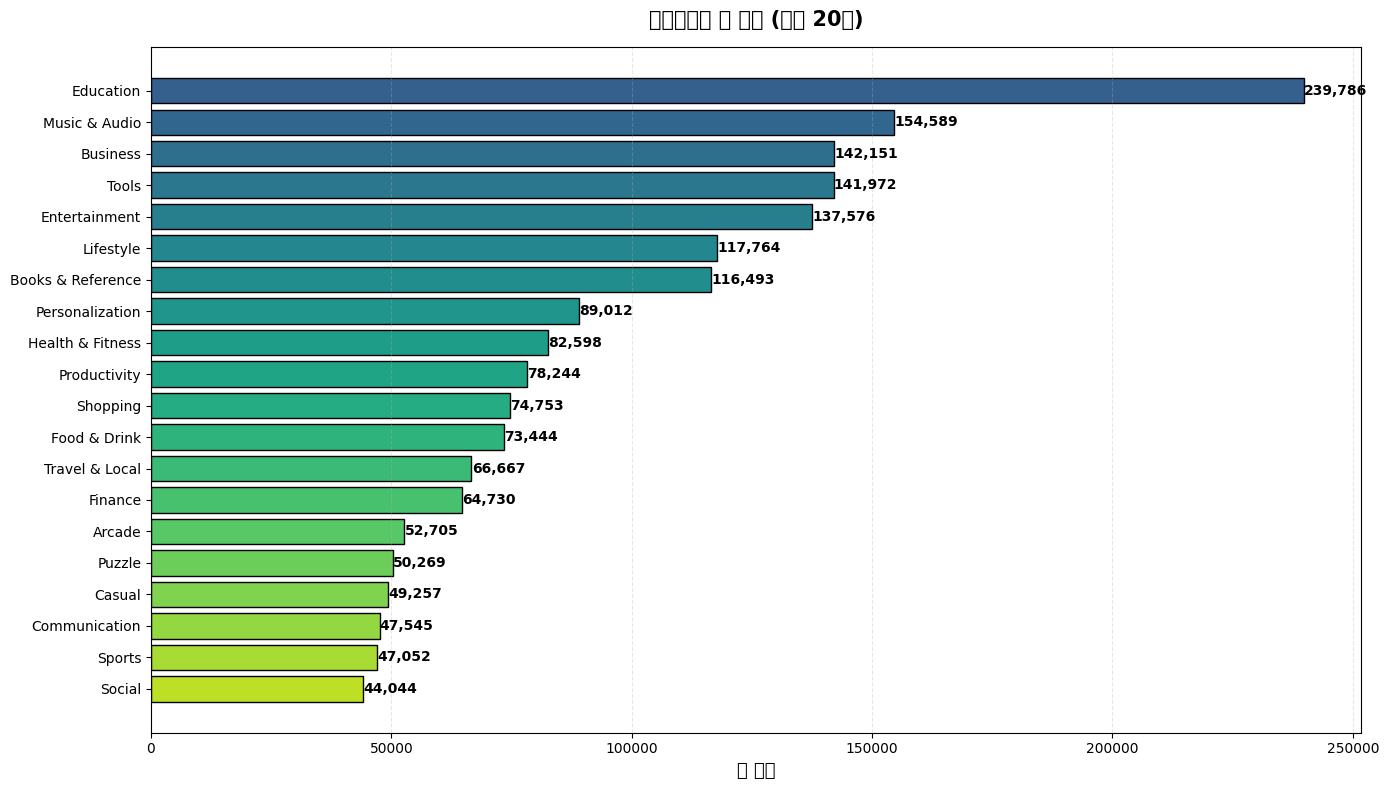


💡 인사이트: 'Education' 카테고리가 239,786개로 가장 많습니다.


In [68]:
# 시각화: 카테고리별 앱 개수 (상위 20개)
plt.figure(figsize=(14, 8))

top20_cats = category_counts.head(20)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top20_cats)))

bars = plt.barh(range(len(top20_cats)), top20_cats.values, color=colors, edgecolor='black', linewidth=1)
plt.yticks(range(len(top20_cats)), top20_cats.index)
plt.xlabel('앱 개수', fontsize=13, fontweight='bold')
plt.title('카테고리별 앱 개수 (상위 20개)', fontsize=15, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# 값 표시
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 50, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}',
             ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 인사이트: '{top20_cats.index[0]}' 카테고리가 {top20_cats.values[0]:,}개로 가장 많습니다.")

In [69]:
cat_rating = df.groupby('Category')['Rating'].agg(['mean', 'median', 'std', 'count']).round(2)
cat_rating.columns = ['평균Rating', '중앙값Rating', '표준편차', '앱개수']
cat_rating = cat_rating.sort_values('평균Rating', ascending=False)

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\2261311221.py:44: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\2261311221.py:44: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' n

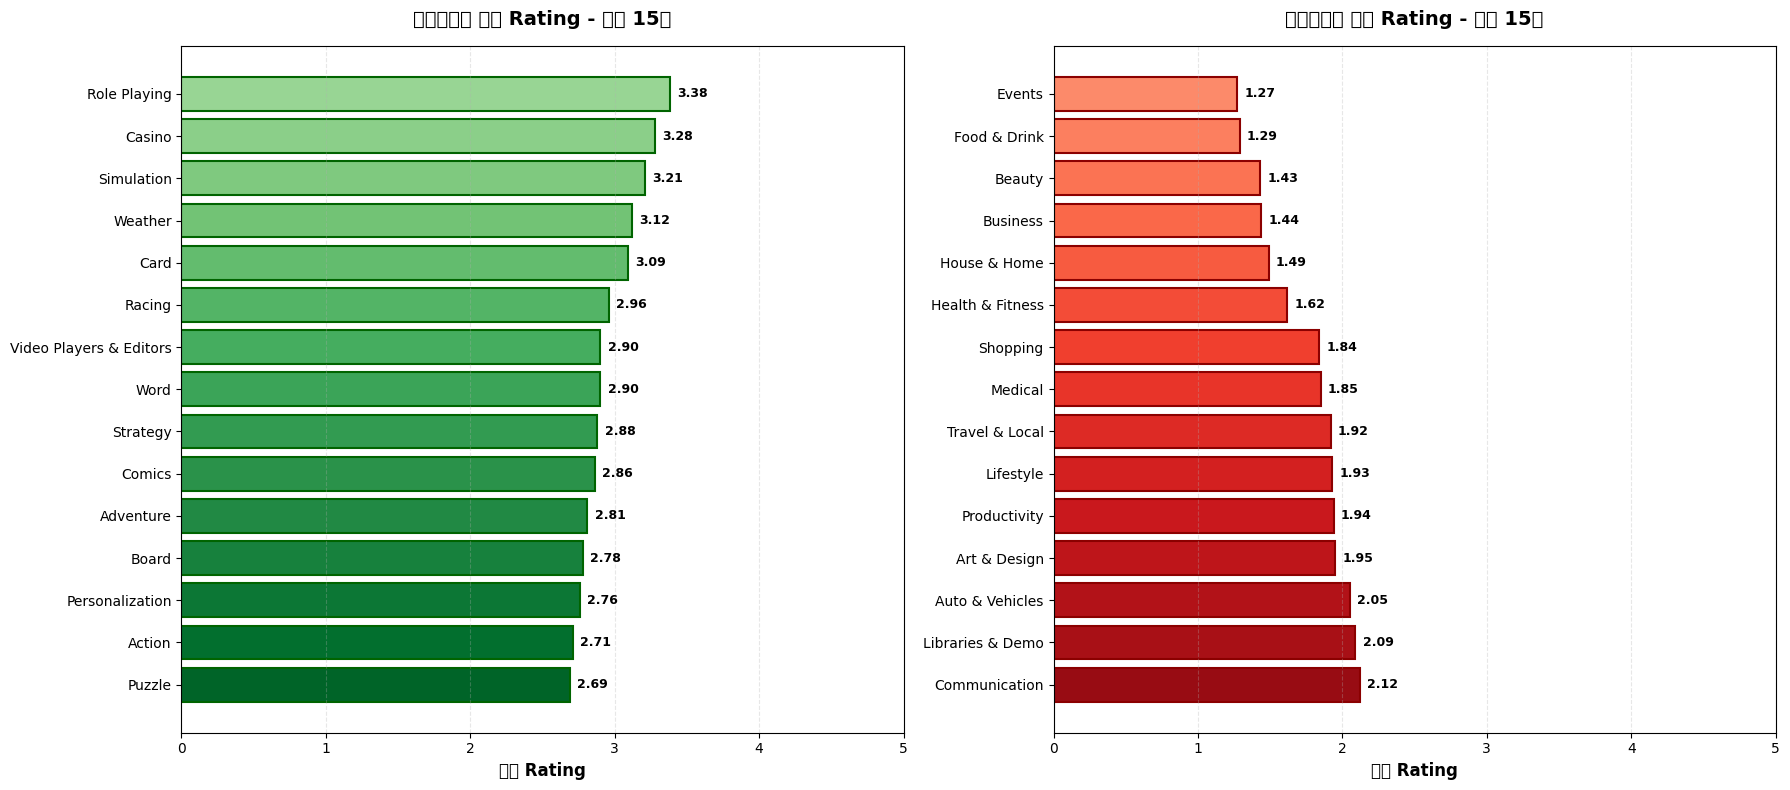


💡 인사이트:
   🥇 최고 평점: Role Playing (3.38)
   📉 최저 평점: Events (1.27)


In [70]:
# 시각화: 카테고리별 평균 Rating
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 왼쪽: 상위 15개
top15_rating = cat_rating.head(15)
colors_top = plt.cm.Greens(np.linspace(0.4, 0.9, len(top15_rating)))
bars1 = axes[0].barh(range(len(top15_rating)), top15_rating['평균Rating'].values,
                     color=colors_top, edgecolor='darkgreen', linewidth=1.5)
axes[0].set_yticks(range(len(top15_rating)))
axes[0].set_yticklabels(top15_rating.index, fontsize=10)
axes[0].set_xlabel('평균 Rating', fontsize=12, fontweight='bold')
axes[0].set_title('카테고리별 평균 Rating - 상위 15개', fontsize=14, fontweight='bold', pad=15)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].set_xlim(0, 5)

# 값 표시
for i, bar in enumerate(bars1):
    width = bar.get_width()
    axes[0].text(width + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{width:.2f}',
                 ha='left', va='center', fontsize=9, fontweight='bold')

# 오른쪽: 하위 15개
bottom15_rating = cat_rating.tail(15).sort_values('평균Rating')
colors_bottom = plt.cm.Reds(np.linspace(0.4, 0.9, len(bottom15_rating)))
bars2 = axes[1].barh(range(len(bottom15_rating)), bottom15_rating['평균Rating'].values,
                     color=colors_bottom, edgecolor='darkred', linewidth=1.5)
axes[1].set_yticks(range(len(bottom15_rating)))
axes[1].set_yticklabels(bottom15_rating.index, fontsize=10)
axes[1].set_xlabel('평균 Rating', fontsize=12, fontweight='bold')
axes[1].set_title('카테고리별 평균 Rating - 하위 15개', fontsize=14, fontweight='bold', pad=15)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].set_xlim(0, 5)

# 값 표시
for i, bar in enumerate(bars2):
    width = bar.get_width()
    axes[1].text(width + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{width:.2f}',
                 ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 인사이트:")
print(f"   🥇 최고 평점: {cat_rating.index[0]} ({cat_rating.iloc[0]['평균Rating']:.2f})")
print(f"   📉 최저 평점: {cat_rating.index[-1]} ({cat_rating.iloc[-1]['평균Rating']:.2f})")

### 1-3. 카테고리별 Installs(다운로드 수) 분석


In [71]:
# 카테고리별 Installs 집계
cat_installs = df.groupby('Category')['Installs'].agg(['sum', 'mean', 'median', 'count'])
cat_installs.columns = ['총Installs', '평균Installs', '중앙값Installs', '앱개수']
cat_installs = cat_installs.sort_values('평균Installs', ascending=False)

print("="*70)
print("📥 카테고리별 다운로드 수 (평균 기준 상위 15개)")
print("="*70)
print(cat_installs.head(15))

print("\n" + "="*70)
print("📥 카테고리별 다운로드 수 (총합 기준 상위 15개)")
print("="*70)
cat_installs_sum = cat_installs.sort_values('총Installs', ascending=False)
print(cat_installs_sum.head(15))

📥 카테고리별 다운로드 수 (평균 기준 상위 15개)
                           총Installs    평균Installs  중앙값Installs     앱개수
Category                                                               
Video Players & Editors  18584144648  1.334588e+06       5000.0   13925
Communication            43208370129  9.087889e+05        500.0   47545
Racing                    9203644133  9.042684e+05       5000.0   10178
Action                   17374827453  6.476620e+05       1000.0   26827
Photography              18889473069  5.338120e+05       1000.0   35386
Simulation               11669579430  5.135354e+05      10000.0   22724
Strategy                  4151758175  5.040377e+05       1000.0    8237
Tools                    71423468364  5.030814e+05       1000.0  141972
Role Playing              4754489813  4.923361e+05      10000.0    9657
Music                     1630112041  3.934618e+05       1000.0    4143
Social                   17163737104  3.896952e+05        500.0   44044
Weather                   27731385

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\3355885443.py:22: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\3355885443.py:22: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\3355885443.py:22: UserWarning: Gly

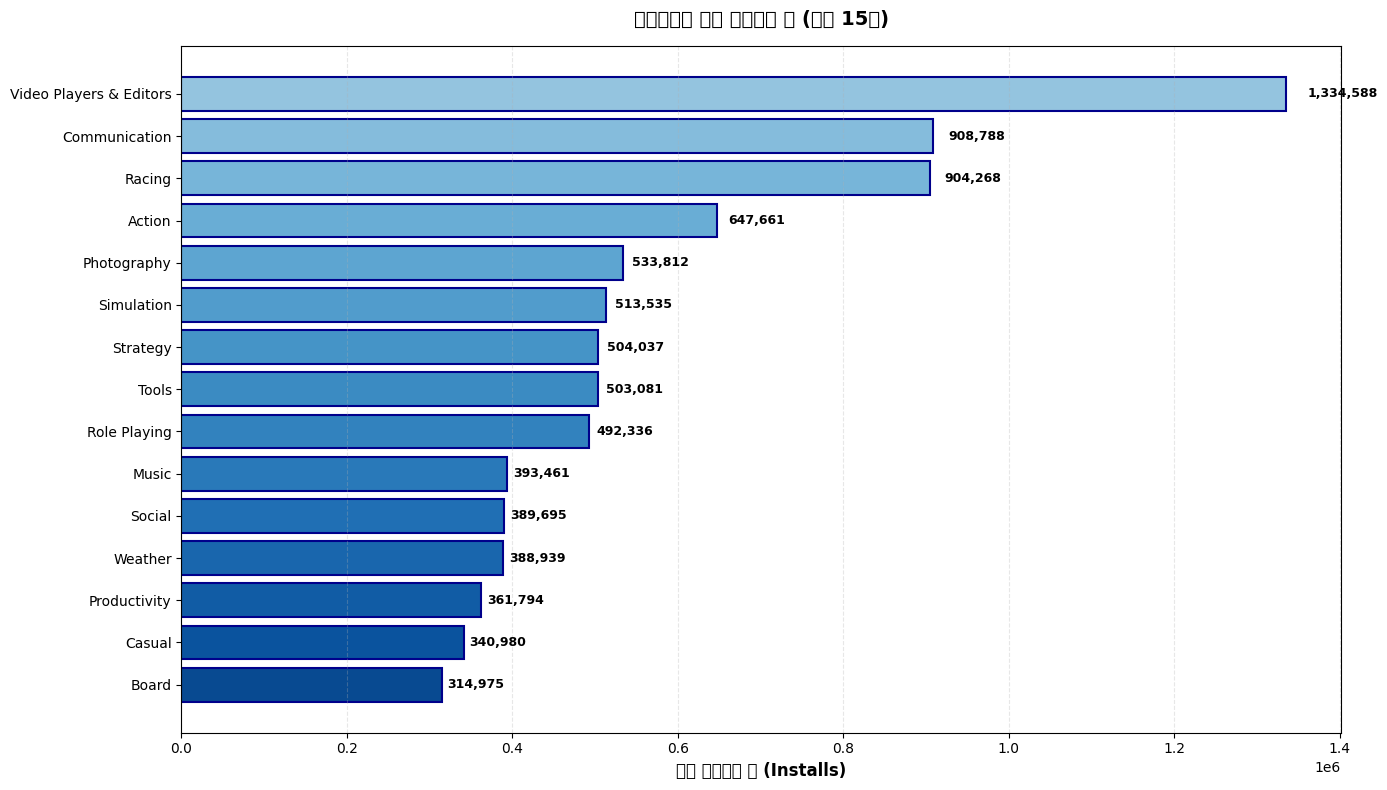


💡 인사이트: 'Video Players & Editors' 카테고리가 평균 1,334,588회로 최고입니다.


In [72]:
# 시각화: 카테고리별 평균 Installs (상위 15개)
plt.figure(figsize=(14, 8))

top15_installs = cat_installs.head(15)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top15_installs)))

bars = plt.barh(range(len(top15_installs)), top15_installs['평균Installs'].values,
                color=colors, edgecolor='darkblue', linewidth=1.5)
plt.yticks(range(len(top15_installs)), top15_installs.index, fontsize=10)
plt.xlabel('평균 다운로드 수 (Installs)', fontsize=12, fontweight='bold')
plt.title('카테고리별 평균 다운로드 수 (상위 15개)', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# 값 표시
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + width*0.02, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}',
             ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 인사이트: '{top15_installs.index[0]}' 카테고리가 평균 {int(top15_installs.iloc[0]['평균Installs']):,}회로 최고입니다.")

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\3686533054.py:22: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\3686533054.py:22: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\3686533054.py:22: UserWarning: Glyph 5

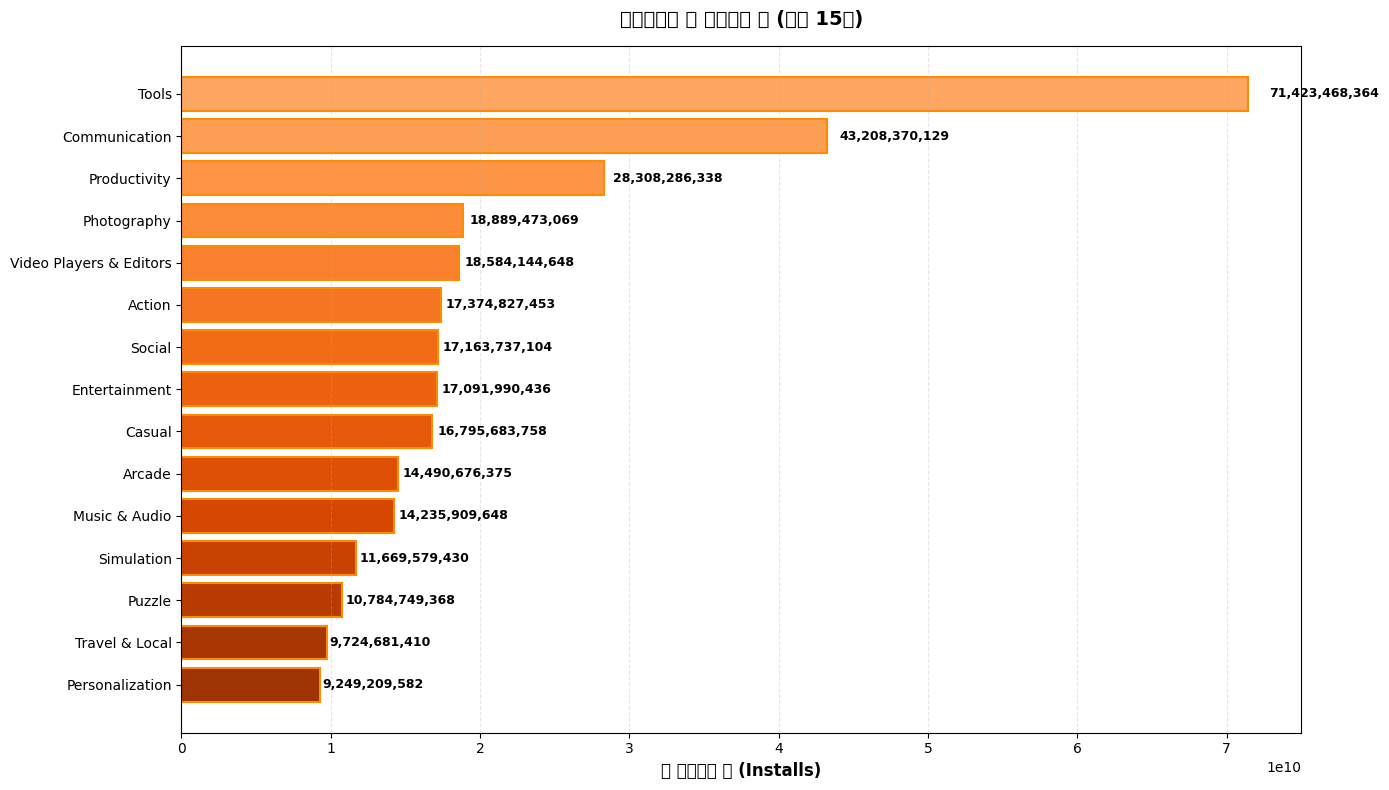


💡 인사이트: 'Tools' 카테고리의 총 다운로드가 71,423,468,364회로 압도적입니다.


In [73]:
# 시각화: 카테고리별 총 Installs (상위 15개)
plt.figure(figsize=(14, 8))

top15_sum = cat_installs_sum.head(15)
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(top15_sum)))

bars = plt.barh(range(len(top15_sum)), top15_sum['총Installs'].values,
                color=colors, edgecolor='darkorange', linewidth=1.5)
plt.yticks(range(len(top15_sum)), top15_sum.index, fontsize=10)
plt.xlabel('총 다운로드 수 (Installs)', fontsize=12, fontweight='bold')
plt.title('카테고리별 총 다운로드 수 (상위 15개)', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# 값 표시
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + width*0.02, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}',
             ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 인사이트: '{top15_sum.index[0]}' 카테고리의 총 다운로드가 {int(top15_sum.iloc[0]['총Installs']):,}회로 압도적입니다.")

### 1-4. 카테고리별 Rating vs Installs 종합 비교


In [74]:
# 카테고리별 Rating과 Installs 종합 테이블
cat_summary = pd.DataFrame({
    '평균Rating': df.groupby('Category')['Rating'].mean(),
    '평균Installs': df.groupby('Category')['Installs'].mean(),
    '총Installs': df.groupby('Category')['Installs'].sum(),
    '앱개수': df.groupby('Category').size()
}).round(2)

# 앱이 50개 이상인 카테고리만 필터링 (신뢰도 향상)
cat_summary_filtered = cat_summary[cat_summary['앱개수'] >= 50].copy()

print("="*70)
print("📊 카테고리별 종합 분석 (앱 50개 이상 카테고리)")
print("="*70)
print(f"\n분석 대상 카테고리: {len(cat_summary_filtered)}개")
print("\nRating 기준 상위 10개:")
print(cat_summary_filtered.sort_values('평균Rating', ascending=False).head(10))

print("\n평균 Installs 기준 상위 10개:")
print(cat_summary_filtered.sort_values('평균Installs', ascending=False).head(10))

📊 카테고리별 종합 분석 (앱 50개 이상 카테고리)

분석 대상 카테고리: 48개

Rating 기준 상위 10개:
                         평균Rating  평균Installs    총Installs    앱개수
Category                                                         
Role Playing                 3.38   492336.11   4754489813   9657
Casino                       3.28   248090.82   1249137278   5035
Simulation                   3.21   513535.44  11669579430  22724
Weather                      3.12   388939.49   2773138546   7130
Card                         3.09   247117.64   1988308545   8046
Racing                       2.96   904268.44   9203644133  10178
Video Players & Editors      2.90  1334588.48  18584144648  13925
Word                         2.90   237999.16   2028942865   8525
Strategy                     2.88   504037.66   4151758175   8237
Comics                       2.86   140866.14    397383379   2821

평균 Installs 기준 상위 10개:
                         평균Rating  평균Installs    총Installs     앱개수
Category                                           

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\2187704571.py:30: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\2187704571.py:30: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' n

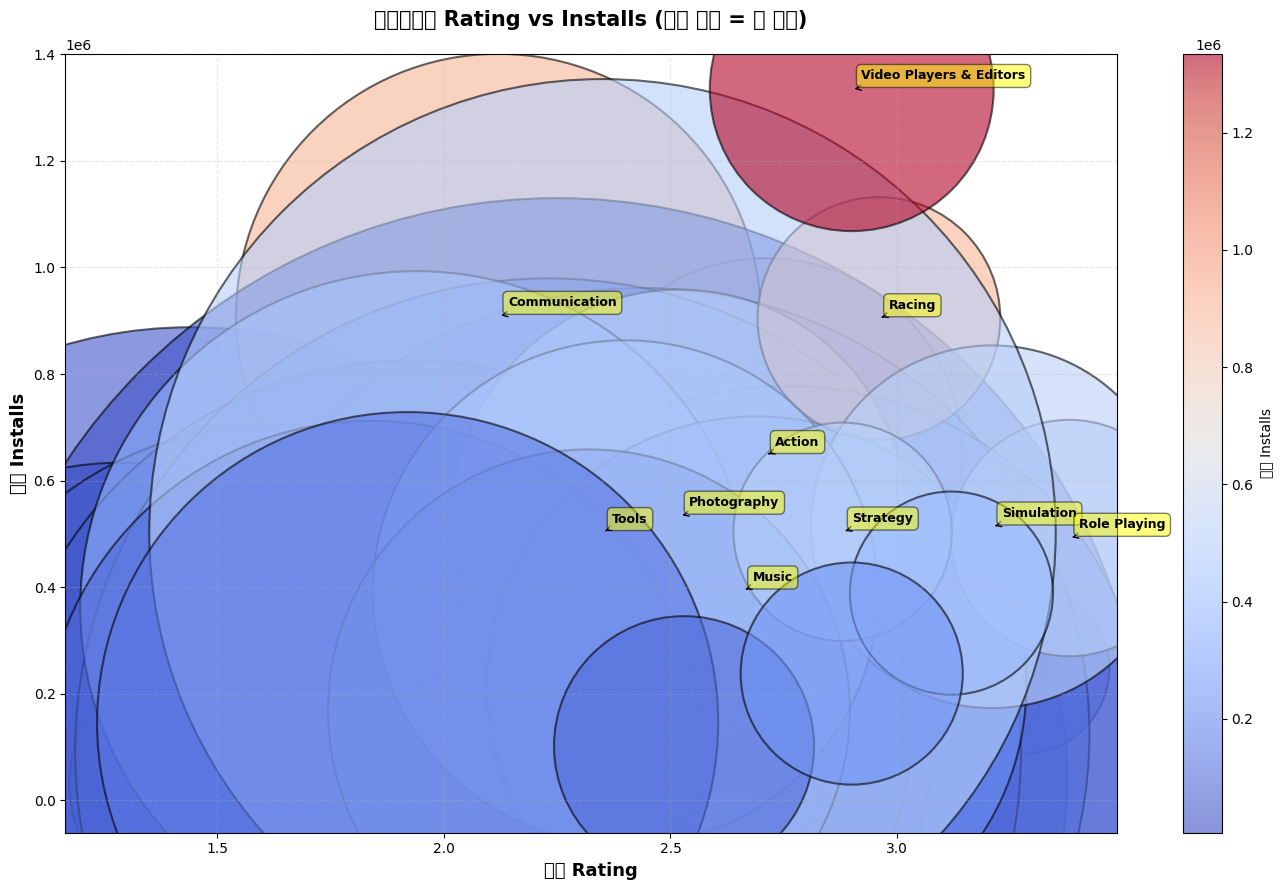


💡 해석 가이드:
   - 오른쪽 위에 위치할수록 Rating과 Installs가 모두 높음 (성공적인 카테고리)
   - 버블이 클수록 해당 카테고리의 앱이 많음


In [75]:
# 시각화: Rating vs Installs 산점도
plt.figure(figsize=(14, 9))

# 버블 크기 = 앱 개수
sizes = cat_summary_filtered['앱개수'] * 3

scatter = plt.scatter(cat_summary_filtered['평균Rating'],
                     cat_summary_filtered['평균Installs'],
                     s=sizes, alpha=0.6,
                     c=cat_summary_filtered['평균Installs'],
                     cmap='coolwarm', edgecolors='black', linewidth=1.5)

# 상위 카테고리 라벨링
top10_label = cat_summary_filtered.nlargest(10, '평균Installs')
for idx in top10_label.index:
    plt.annotate(idx,
                xy=(cat_summary_filtered.loc[idx, '평균Rating'],
                    cat_summary_filtered.loc[idx, '평균Installs']),
                xytext=(7, 7), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.5),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1))

plt.colorbar(scatter, label='평균 Installs')
plt.xlabel('평균 Rating', fontsize=13, fontweight='bold')
plt.ylabel('평균 Installs', fontsize=13, fontweight='bold')
plt.title('카테고리별 Rating vs Installs (버블 크기 = 앱 개수)',
         fontsize=15, fontweight='bold', pad=20)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\n💡 해석 가이드:")
print("   - 오른쪽 위에 위치할수록 Rating과 Installs가 모두 높음 (성공적인 카테고리)")
print("   - 버블이 클수록 해당 카테고리의 앱이 많음")

---
### 1-5. 테마 1 결론: 카테고리별 성공 요인 정리


In [76]:
print("="*70)
print("🎯 테마 1 핵심 인사이트: 카테고리별 성공 요인")
print("="*70)

# 최고 평점 카테고리
best_rating_cat = cat_rating.index[0]
best_rating_score = cat_rating.iloc[0]['평균Rating']

# 최다 다운로드 카테고리 (평균)
best_installs_cat = cat_installs.index[0]
best_installs_score = cat_installs.iloc[0]['평균Installs']

# 총 다운로드 최다
best_total_cat = cat_installs_sum.index[0]
best_total_score = cat_installs_sum.iloc[0]['총Installs']

# 가장 많은 앱 보유
most_apps_cat = category_counts.index[0]
most_apps_count = category_counts.values[0]

print(f"\n1️⃣  최고 평점 카테고리")
print(f"   → {best_rating_cat}: 평균 {best_rating_score:.2f}점")

print(f"\n2️⃣  평균 다운로드 최다 카테고리")
print(f"   → {best_installs_cat}: 평균 {int(best_installs_score):,}회")

print(f"\n3️⃣  총 다운로드 최다 카테고리")
print(f"   → {best_total_cat}: 총 {int(best_total_score):,}회")

print(f"\n4️⃣  앱 개수 최다 카테고리")
print(f"   → {most_apps_cat}: {most_apps_count:,}개")

print("\n" + "="*70)
print("💡 종합 결론")
print("="*70)
print("  • Rating이 높다고 해서 Installs가 많은 것은 아님")
print("  • 일부 카테고리는 Rating은 낮지만 Installs가 매우 높음")
print("  • 앱 개수가 많은 카테고리 = 경쟁이 치열한 시장")
print("  • 성공 전략은 카테고리별 특성에 따라 다를 수 있음")
print("="*70)

🎯 테마 1 핵심 인사이트: 카테고리별 성공 요인

1️⃣  최고 평점 카테고리
   → Role Playing: 평균 3.38점

2️⃣  평균 다운로드 최다 카테고리
   → Video Players & Editors: 평균 1,334,588회

3️⃣  총 다운로드 최다 카테고리
   → Tools: 총 71,423,468,364회

4️⃣  앱 개수 최다 카테고리
   → Education: 239,786개

💡 종합 결론
  • Rating이 높다고 해서 Installs가 많은 것은 아님
  • 일부 카테고리는 Rating은 낮지만 Installs가 매우 높음
  • 앱 개수가 많은 카테고리 = 경쟁이 치열한 시장
  • 성공 전략은 카테고리별 특성에 따라 다를 수 있음


---
## 2. 평점 구조 및 리뷰 참여도 분석

### 2-1. Rating 분포 분석


In [77]:
# Rating 기본 통계
print("="*70)
print("⭐ Rating 기본 통계")
print("="*70)
print(df['Rating'].describe())

# Rating 구간별 분포
rating_bins = pd.cut(df['Rating'],
                     bins=[0, 2, 3, 4, 4.5, 5],
                     labels=['0-2점', '2-3점', '3-4점', '4-4.5점', '4.5-5점'])

print("\n" + "="*70)
print("⭐ Rating 구간별 앱 개수")
print("="*70)
rating_bin_counts = rating_bins.value_counts().sort_index()
print(rating_bin_counts)
print(f"\n비율(%):\n{(rating_bin_counts / len(df) * 100).round(2)}")

⭐ Rating 기본 통계
count    2.290056e+06
mean     2.203148e+00
std      2.106223e+00
min      0.000000e+00
25%      0.000000e+00
50%      2.900000e+00
75%      4.300000e+00
max      5.000000e+00
Name: Rating, dtype: float64

⭐ Rating 구간별 앱 개수
Rating
0-2점       17148
2-3점       86480
3-4점      376359
4-4.5점    404047
4.5-5점    346260
Name: count, dtype: int64

비율(%):
Rating
0-2점       0.75
2-3점       3.78
3-4점      16.43
4-4.5점    17.64
4.5-5점    15.12
Name: count, dtype: float64


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\146415055.py:35: UserWarning: Glyph 50545 (\N{HANGUL SYLLABLE AEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local

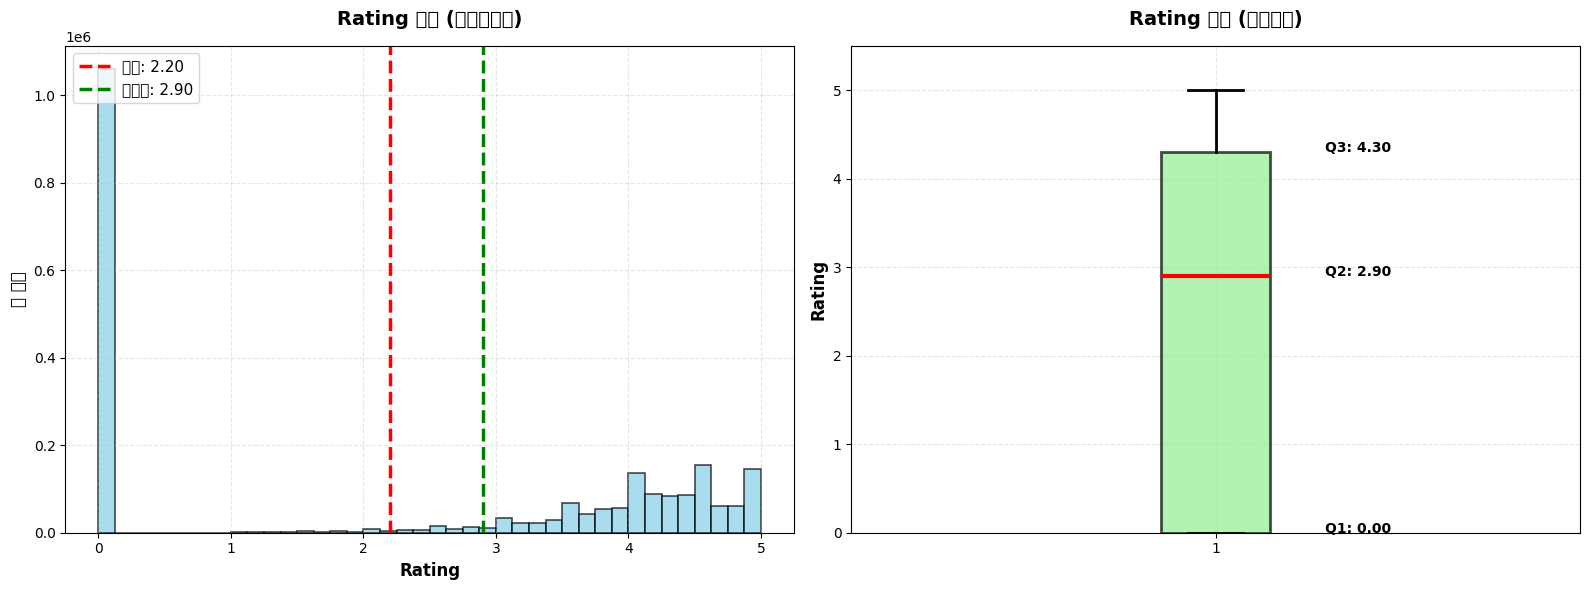


💡 인사이트:
   - 평균 Rating: 2.20점
   - 중앙값: 2.90점
   - 50% 앱들이 0.00~4.30점 사이에 분포


In [78]:
# 시각화: Rating 분포
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 히스토그램
axes[0].hist(df['Rating'], bins=40, color='skyblue', edgecolor='black', alpha=0.7, linewidth=1.2)
axes[0].axvline(df['Rating'].mean(), color='red', linestyle='--', linewidth=2.5,
               label=f'평균: {df["Rating"].mean():.2f}')
axes[0].axvline(df['Rating'].median(), color='green', linestyle='--', linewidth=2.5,
               label=f'중앙값: {df["Rating"].median():.2f}')
axes[0].set_xlabel('Rating', fontsize=12, fontweight='bold')
axes[0].set_ylabel('앱 개수', fontsize=12, fontweight='bold')
axes[0].set_title('Rating 분포 (히스토그램)', fontsize=14, fontweight='bold', pad=15)
axes[0].legend(fontsize=11, loc='upper left')
axes[0].grid(alpha=0.3, linestyle='--')

# 오른쪽: 박스플롯
bp = axes[1].boxplot(df['Rating'], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightgreen', alpha=0.7, linewidth=2),
                     medianprops=dict(color='red', linewidth=3),
                     whiskerprops=dict(linewidth=2),
                     capprops=dict(linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))
axes[1].set_ylabel('Rating', fontsize=12, fontweight='bold')
axes[1].set_title('Rating 분포 (박스플롯)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylim(0, 5.5)
axes[1].grid(alpha=0.3, linestyle='--')

# 사분위수 표시
q1 = df['Rating'].quantile(0.25)
q3 = df['Rating'].quantile(0.75)
axes[1].text(1.15, q1, f'Q1: {q1:.2f}', fontsize=10, fontweight='bold')
axes[1].text(1.15, df['Rating'].median(), f'Q2: {df["Rating"].median():.2f}', fontsize=10, fontweight='bold')
axes[1].text(1.15, q3, f'Q3: {q3:.2f}', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 인사이트:")
print(f"   - 평균 Rating: {df['Rating'].mean():.2f}점")
print(f"   - 중앙값: {df['Rating'].median():.2f}점")
print(f"   - 50% 앱들이 {q1:.2f}~{q3:.2f}점 사이에 분포")

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\615657194.py:12: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\615657194.py:12: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\615657194.py:12: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\615657194.py:12: UserWarning: Glyph 50545 (\N{HANGUL SYLLABLE AEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\615657194.py:12: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local\Temp\ipykern

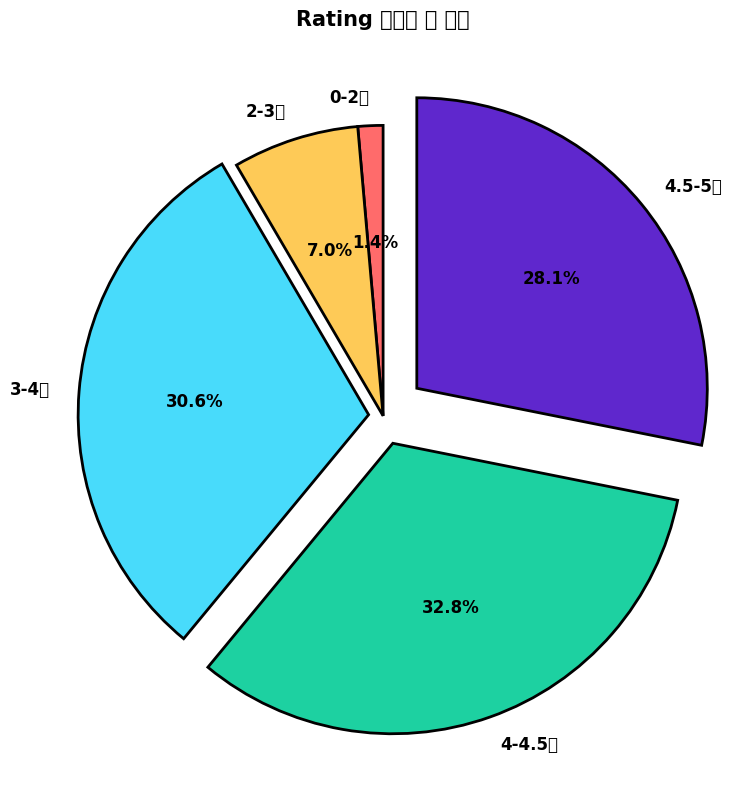


💡 인사이트: 4-4.5점 구간에 가장 많은 앱(404,047개)이 분포합니다.


In [79]:
# 시각화: Rating 구간별 비율 (파이 차트)
plt.figure(figsize=(10, 8))

colors = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1', '#5f27cd']
explode = (0, 0, 0.05, 0.1, 0.15)  # 높은 점수 강조

plt.pie(rating_bin_counts.values, labels=rating_bin_counts.index,
        autopct='%1.1f%%', startangle=90, colors=colors, explode=explode,
        textprops={'fontsize': 12, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 2})
plt.title('Rating 구간별 앱 비율', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"\n💡 인사이트: {rating_bin_counts.idxmax()} 구간에 가장 많은 앱({rating_bin_counts.max():,}개)이 분포합니다.")

### 2-2. Rating Count(리뷰 개수) 분포 분석


In [80]:
# Rating Count 컬럼 존재 여부 확인
if 'Rating Count' in df.columns:
    has_rating_count = True
    print("✅ Rating Count 컬럼 존재 - 리뷰 분석 진행")
else:
    has_rating_count = False
    print("⚠️ Rating Count 컬럼 없음 - 리뷰 분석 건너뜀")

✅ Rating Count 컬럼 존재 - 리뷰 분석 진행


In [81]:
if has_rating_count:
    # Rating Count 기본 통계
    print("="*70)
    print("💬 Rating Count 기본 통계")
    print("="*70)
    print(df['Rating Count'].describe())

    # Rating Count 구간 분류
    count_bins = pd.cut(df['Rating Count'],
                        bins=[0, 100, 1000, 10000, 100000, df['Rating Count'].max()],
                        labels=['0-100', '100-1K', '1K-10K', '10K-100K', '100K+'])

    print("\n" + "="*70)
    print("💬 Rating Count 구간별 앱 개수")
    print("="*70)
    count_bin_counts = count_bins.value_counts().sort_index()
    print(count_bin_counts)
else:
    print("⚠️ Rating Count 데이터가 없어 이 분석을 건너뜁니다.")

💬 Rating Count 기본 통계
count    2.285106e+06
mean     2.870482e+03
std      2.123921e+05
min      0.000000e+00
25%      0.000000e+00
50%      6.000000e+00
75%      4.200000e+01
max      1.385576e+08
Name: Rating Count, dtype: float64

💬 Rating Count 구간별 앱 개수
Rating Count
0-100       827156
100-1K      262526
1K-10K       98231
10K-100K     30230
100K+         7201
Name: count, dtype: int64


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\2800606351

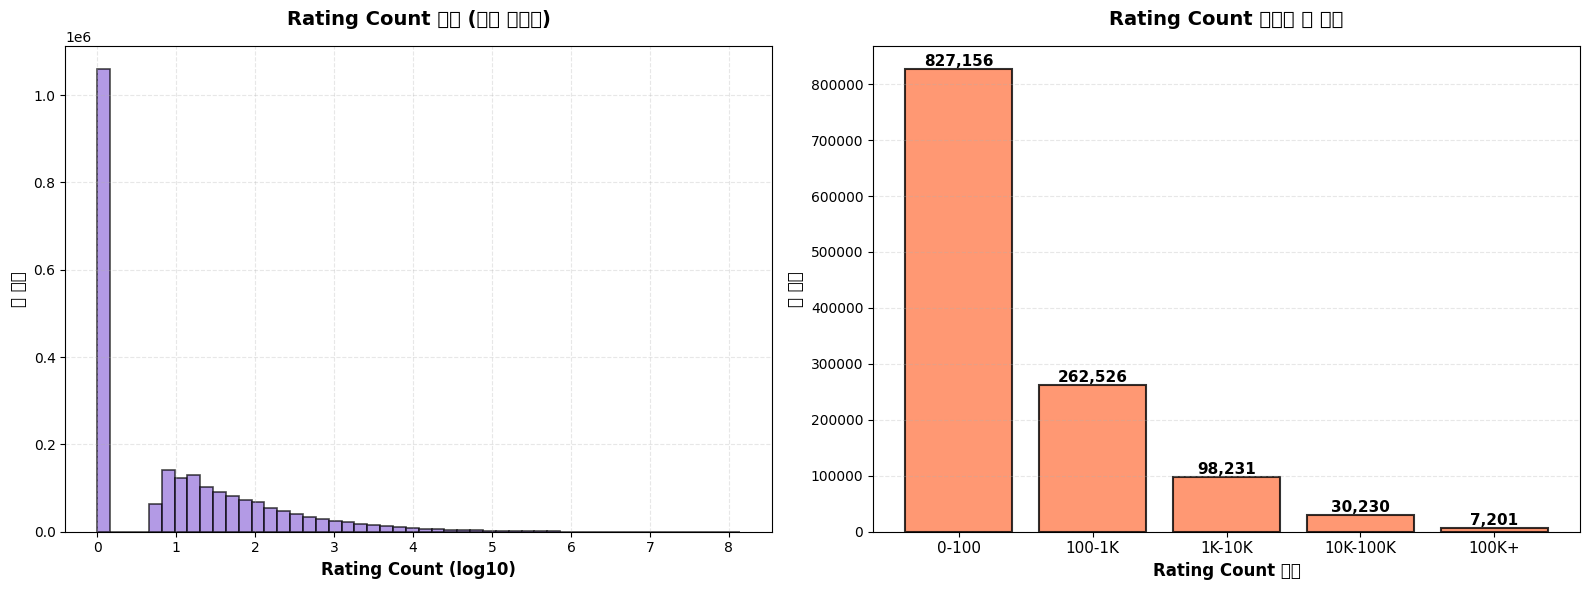


💡 인사이트: 대부분의 앱이 리뷰 개수가 적으며, 많은 리뷰를 받는 앱은 소수입니다.


In [82]:
if has_rating_count:
    # 시각화: Rating Count 분포
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 왼쪽: 히스토그램 (로그 스케일)
    axes[0].hist(np.log10(df['Rating Count'] + 1), bins=50,
                color='mediumpurple', edgecolor='black', alpha=0.7, linewidth=1.2)
    axes[0].set_xlabel('Rating Count (log10)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('앱 개수', fontsize=12, fontweight='bold')
    axes[0].set_title('Rating Count 분포 (로그 스케일)', fontsize=14, fontweight='bold', pad=15)
    axes[0].grid(alpha=0.3, linestyle='--')

    # 오른쪽: 구간별 막대 그래프
    bars = axes[1].bar(range(len(count_bin_counts)), count_bin_counts.values,
                       color='coral', alpha=0.8, edgecolor='black', linewidth=1.5)
    axes[1].set_xticks(range(len(count_bin_counts)))
    axes[1].set_xticklabels(count_bin_counts.index, fontsize=11)
    axes[1].set_xlabel('Rating Count 구간', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('앱 개수', fontsize=12, fontweight='bold')
    axes[1].set_title('Rating Count 구간별 앱 개수', fontsize=14, fontweight='bold', pad=15)
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')

    # 값 표시
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, height,
                    f'{int(height):,}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f"\n💡 인사이트: 대부분의 앱이 리뷰 개수가 적으며, 많은 리뷰를 받는 앱은 소수입니다.")

### 2-3. Rating Count vs Installs 관계 분석


In [83]:
if has_rating_count:
    # 상관계수 계산
    correlation = df[['Rating Count', 'Installs']].corr().iloc[0, 1]

    print("="*70)
    print("📊 Rating Count와 Installs 상관관계")
    print("="*70)
    print(f"상관계수: {correlation:.4f}")

    if correlation > 0.7:
        print("✅ 강한 양의 상관관계 - 다운로드가 많을수록 리뷰도 많습니다.")
    elif correlation > 0.4:
        print("✅ 중간 정도의 양의 상관관계 - 다운로드와 리뷰가 어느 정도 관련됩니다.")
    else:
        print("⚠️ 약한 상관관계 - 다운로드와 리뷰의 관련성이 약합니다.")

📊 Rating Count와 Installs 상관관계
상관계수: 0.5453
✅ 중간 정도의 양의 상관관계 - 다운로드와 리뷰가 어느 정도 관련됩니다.


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

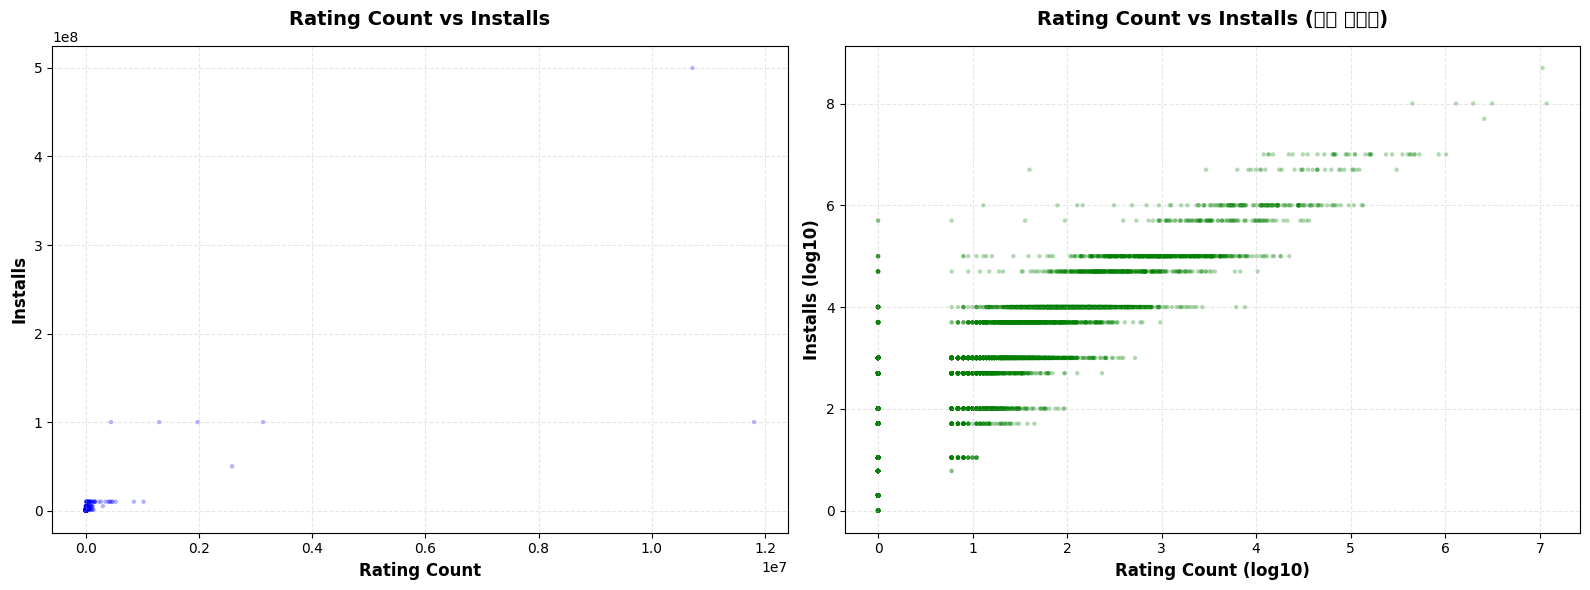


💡 인사이트: 다운로드 수가 많을수록 리뷰도 많은 경향이 있습니다.


In [84]:
if has_rating_count:
    # 시각화: Rating Count vs Installs 산점도
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 왼쪽: 일반 산점도 (샘플링)
    sample_df = df.sample(min(10000, len(df)), random_state=42)
    axes[0].scatter(sample_df['Rating Count'], sample_df['Installs'],
                   alpha=0.3, s=10, color='blue', edgecolors='none')
    axes[0].set_xlabel('Rating Count', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Installs', fontsize=12, fontweight='bold')
    axes[0].set_title('Rating Count vs Installs', fontsize=14, fontweight='bold', pad=15)
    axes[0].grid(alpha=0.3, linestyle='--')

    # 오른쪽: 로그 스케일 산점도
    axes[1].scatter(np.log10(sample_df['Rating Count'] + 1),
                   np.log10(sample_df['Installs'] + 1),
                   alpha=0.3, s=10, color='green', edgecolors='none')
    axes[1].set_xlabel('Rating Count (log10)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Installs (log10)', fontsize=12, fontweight='bold')
    axes[1].set_title('Rating Count vs Installs (로그 스케일)', fontsize=14, fontweight='bold', pad=15)
    axes[1].grid(alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

    print(f"\n💡 인사이트: 다운로드 수가 많을수록 리뷰도 많은 경향이 있습니다.")

### 2-4. Rating vs Installs 상관관계


In [85]:
# Rating과 Installs 상관계수
rating_installs_corr = df[['Rating', 'Installs']].corr().iloc[0, 1]

print("="*70)
print("📊 Rating과 Installs 상관관계")
print("="*70)
print(f"상관계수: {rating_installs_corr:.4f}")

if abs(rating_installs_corr) < 0.3:
    print("⚠️ 약한 상관관계 - 평점이 높다고 다운로드가 많은 것은 아닙니다.")
elif abs(rating_installs_corr) < 0.7:
    print("✅ 중간 정도의 상관관계 - 평점과 다운로드가 어느 정도 관련됩니다.")
else:
    print("✅ 강한 상관관계 - 평점이 높을수록 다운로드도 많습니다.")

📊 Rating과 Installs 상관관계
상관계수: 0.0112
⚠️ 약한 상관관계 - 평점이 높다고 다운로드가 많은 것은 아닙니다.


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\1602280671.py:11: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\1602280671.py:11: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) m

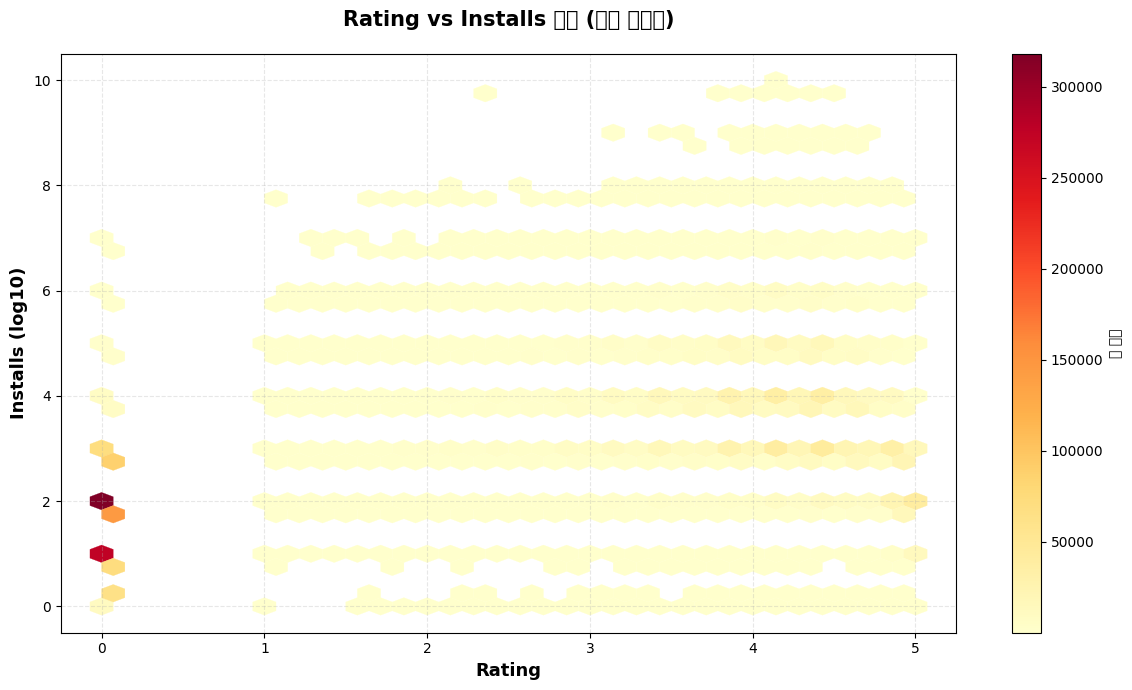


💡 인사이트: 색이 진할수록 해당 Rating-Installs 조합의 앱이 많습니다.


In [86]:
# 시각화: Rating vs Installs 헥스빈
plt.figure(figsize=(12, 7))

plt.hexbin(df['Rating'], np.log10(df['Installs'] + 1),
          gridsize=35, cmap='YlOrRd', mincnt=1, linewidths=0.2)
plt.colorbar(label='앱 개수')
plt.xlabel('Rating', fontsize=13, fontweight='bold')
plt.ylabel('Installs (log10)', fontsize=13, fontweight='bold')
plt.title('Rating vs Installs 관계 (밀도 히트맵)', fontsize=15, fontweight='bold', pad=20)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\n💡 인사이트: 색이 진할수록 해당 Rating-Installs 조합의 앱이 많습니다.")

### 2-5. Rating 구간별 평균 Installs 비교


In [87]:
# Rating 구간 생성
df['Rating_구간'] = pd.cut(df['Rating'],
                          bins=[0, 2, 3, 4, 4.5, 5],
                          labels=['0-2점', '2-3점', '3-4점', '4-4.5점', '4.5-5점'])

# 구간별 평균 Installs
rating_bin_installs = df.groupby('Rating_구간', observed=True).agg({
    'Installs': ['mean', 'median', 'count']
})
rating_bin_installs.columns = ['평균Installs', '중앙값Installs', '앱개수']

print("="*70)
print("📊 Rating 구간별 평균 Installs")
print("="*70)
print(rating_bin_installs)

📊 Rating 구간별 평균 Installs
              평균Installs  중앙값Installs     앱개수
Rating_구간                                    
0-2점        49739.560415       1000.0   17148
2-3점       124153.044958       5000.0   86480
3-4점       291550.848719      10000.0  376359
4-4.5점     652979.330568       5000.0  404047
4.5-5점     110038.917363       1000.0  346260


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\883886807.py:32: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\883886807.py:32: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\883886807.py:32: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: F

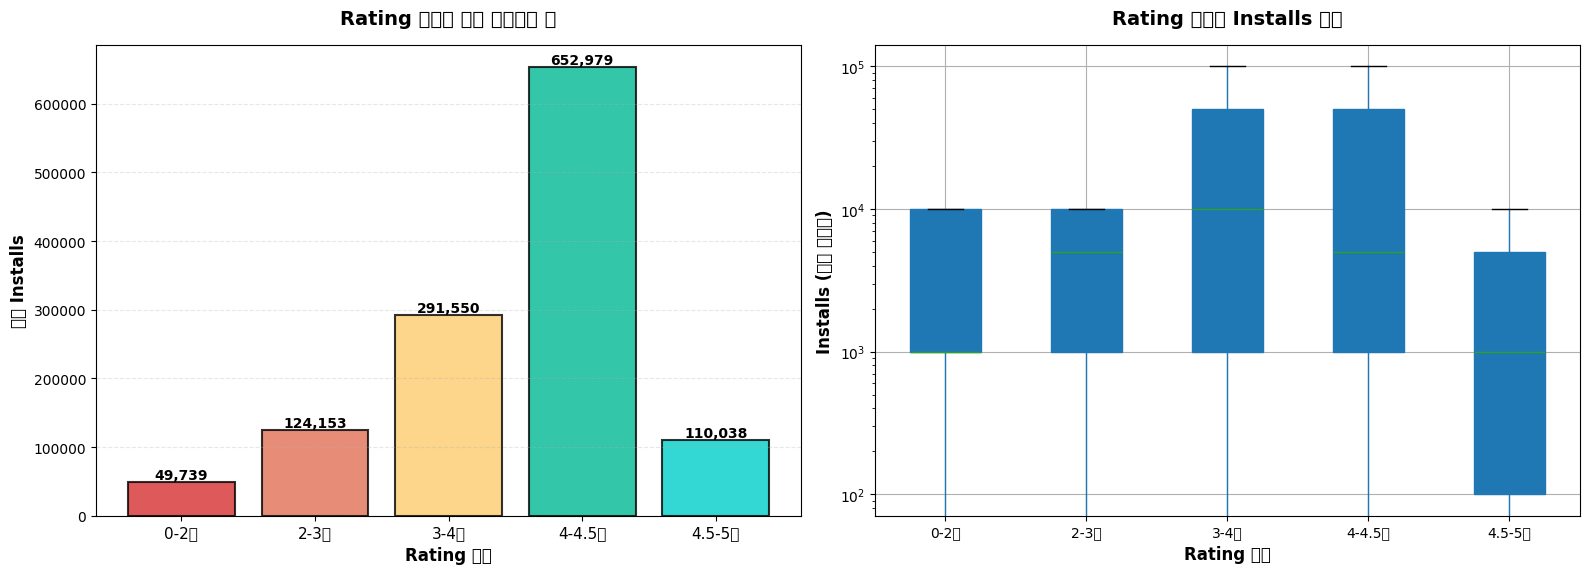


💡 인사이트: '4-4.5점' 구간 앱들의 평균 다운로드 수가 가장 많습니다.


In [88]:
# 시각화: Rating 구간별 평균 Installs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 막대 그래프
colors_gradient = ['#d63031', '#e17055', '#fdcb6e', '#00b894', '#00cec9']
bars = axes[0].bar(range(len(rating_bin_installs)),
                   rating_bin_installs['평균Installs'].values,
                   color=colors_gradient, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0].set_xticks(range(len(rating_bin_installs)))
axes[0].set_xticklabels(rating_bin_installs.index, fontsize=11)
axes[0].set_xlabel('Rating 구간', fontsize=12, fontweight='bold')
axes[0].set_ylabel('평균 Installs', fontsize=12, fontweight='bold')
axes[0].set_title('Rating 구간별 평균 다운로드 수', fontsize=14, fontweight='bold', pad=15)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# 값 표시
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 오른쪽: 박스플롯
df.boxplot(column='Installs', by='Rating_구간', ax=axes[1],
          patch_artist=True, grid=True, showfliers=False)
axes[1].set_xlabel('Rating 구간', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Installs (로그 스케일)', fontsize=12, fontweight='bold')
axes[1].set_title('Rating 구간별 Installs 분포', fontsize=14, fontweight='bold', pad=15)
axes[1].set_yscale('log')
plt.suptitle('')  # 상단 자동 제목 제거

plt.tight_layout()
plt.show()

best_bin = rating_bin_installs['평균Installs'].idxmax()
print(f"\n💡 인사이트: '{best_bin}' 구간 앱들의 평균 다운로드 수가 가장 많습니다.")

### 2-6. 리뷰 참여율 분석


In [89]:
if has_rating_count:
    # 리뷰 참여율 계산
    df['리뷰참여율(%)'] = (df['Rating Count'] / df['Installs'] * 100).round(2)
    df['리뷰참여율(%)'] = df['리뷰참여율(%)'].replace([np.inf, -np.inf], np.nan)

    print("="*70)
    print("💬 리뷰 참여율 통계")
    print("="*70)
    print(df['리뷰참여율(%)'].describe())

    # 참여율 상위 앱
    print("\n" + "="*70)
    print("💬 리뷰 참여율 상위 10개 앱")
    print("="*70)
    if 'App Name' in df.columns:
        top_part = df.nlargest(10, '리뷰참여율(%)')[['App Name', 'Category', 'Rating',
                                                      'Installs', 'Rating Count', '리뷰참여율(%)']]
        print(top_part)
    else:
        top_part = df.nlargest(10, '리뷰참여율(%)')[['Category', 'Rating',
                                                      'Installs', 'Rating Count', '리뷰참여율(%)']]
        print(top_part)

💬 리뷰 참여율 통계
count    2.273936e+06
mean     2.310397e+00
std      7.451112e+00
min      0.000000e+00
25%      0.000000e+00
50%      3.000000e-01
75%      1.550000e+00
max      1.000000e+02
Name: 리뷰참여율(%), dtype: float64

💬 리뷰 참여율 상위 10개 앱
                                                App Name       Category  \
3829                                            SomzIRIS  Entertainment   
4119                               Officials Information  Communication   
5197                                          meal ideas   Food & Drink   
5450                               Vertex Unit Converter          Tools   
6983                                  Sympl Productivity   Productivity   
7776                                    Fall Faster Ball         Arcade   
9608                                              McPAID      Lifestyle   
11032  Infinite 3D Game NO or With Internet Planet Darks         Arcade   
11907                                    Cosmic Fortunes         Arcade   
14409       

---
### 2-7. 테마 2 결론: 평점 구조 및 리뷰 참여도 정리


In [90]:
print("="*70)
print("⭐ 테마 2 핵심 인사이트: 평점 구조 및 리뷰 참여도")
print("="*70)

# Rating 분포 특성
print(f"\n1️⃣  Rating 분포 특성")
print(f"   • 평균 Rating: {df['Rating'].mean():.2f}점")
print(f"   • 중앙값: {df['Rating'].median():.2f}점")
print(f"   • 가장 많은 구간: {rating_bin_counts.idxmax()}")

# Rating-Installs 관계
print(f"\n2️⃣  Rating과 Installs 관계")
print(f"   • 상관계수: {rating_installs_corr:.4f}")
if abs(rating_installs_corr) < 0.3:
    print(f"   • 해석: 평점이 높다고 다운로드가 많은 것은 아님")
else:
    print(f"   • 해석: 평점과 다운로드는 어느 정도 관련성이 있음")

# Rating Count 관계 (있는 경우만)
if has_rating_count:
    print(f"\n3️⃣  Rating Count와 Installs 관계")
    print(f"   • 상관계수: {correlation:.4f}")
    print(f"   • 해석: 다운로드가 많을수록 리뷰도 많음")

    print(f"\n4️⃣  리뷰 참여율")
    print(f"   • 중앙값: {df['리뷰참여율(%)'].median():.2f}%")
    print(f"   • 대부분의 사용자는 리뷰를 작성하지 않음")

print("\n" + "="*70)
print("💡 종합 결론")
print("="*70)
print("  • 대부분의 앱이 4점 이상의 높은 평점을 받고 있음")
print("  • Rating과 Installs는 강한 상관관계를 보이지 않음")
print("  • 다운로드 수가 많아도 리뷰 참여율은 낮음")
print("  • 앱 성공에는 평점 외에도 다른 요인들이 중요")
print("="*70)

⭐ 테마 2 핵심 인사이트: 평점 구조 및 리뷰 참여도

1️⃣  Rating 분포 특성
   • 평균 Rating: 2.20점
   • 중앙값: 2.90점
   • 가장 많은 구간: 4-4.5점

2️⃣  Rating과 Installs 관계
   • 상관계수: 0.0112
   • 해석: 평점이 높다고 다운로드가 많은 것은 아님

3️⃣  Rating Count와 Installs 관계
   • 상관계수: 0.5453
   • 해석: 다운로드가 많을수록 리뷰도 많음

4️⃣  리뷰 참여율
   • 중앙값: 0.30%
   • 대부분의 사용자는 리뷰를 작성하지 않음

💡 종합 결론
  • 대부분의 앱이 4점 이상의 높은 평점을 받고 있음
  • Rating과 Installs는 강한 상관관계를 보이지 않음
  • 다운로드 수가 많아도 리뷰 참여율은 낮음
  • 앱 성공에는 평점 외에도 다른 요인들이 중요


---

### 🎯 **테마 3: 다운로드 패턴 - 롱테일 구조** (박정우)
<span style="font-family: 'Malgun Gothic'; font-size: 16px;">
<b>목표:</b> 앱 시장의 구조 분석
</span>

#### 분석 내용
- Installs 분포(원본/로그)
- Installs_bin 비율 분석
- 다운로드 상·하위 그룹 특성 확인

#### 시각화
- 히스토그램, 박스플롯

---

### ⭐ **테마 4: 업데이트 주기 & 앱나이 분석** (박정우)
<span style="font-family: 'Malgun Gothic'; font-size: 16px;">
<b>목표:</b> 업데이트 주기와 앱나이가 다운로드/평점에 미치는 영향 분석
</span>

#### 분석 내용
- 업데이트 주기별 평점/다운로드 비교
- 앱 나이와 성과의 관계

#### 시각화
- 박스플롯, 바차트


---
## 3. 다운로드 패턴 분석

### 3-1. Installs 분포 및 롱테일 구조
- Installs 분포(원본/로그)
- Installs_bin 비율 분석
- 다운로드 상·하위 그룹 특성 확인


<Axes: xlabel='Installs', ylabel='Count'>

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

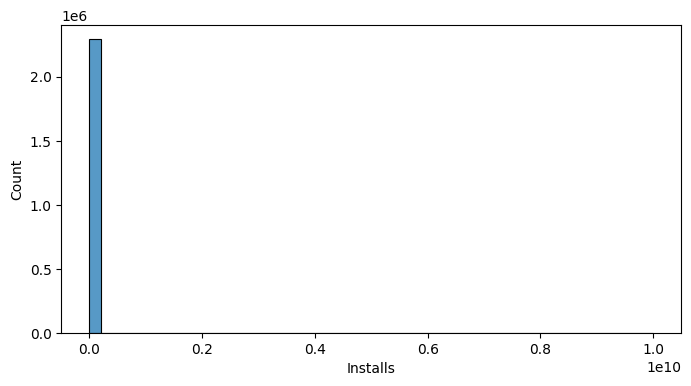

In [91]:
#Installs 분포(원본)
plt.figure(figsize=(8,4))
sns.histplot(df, x="Installs", bins=50, stat="count")

<Axes: xlabel='Installs_log', ylabel='Count'>

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

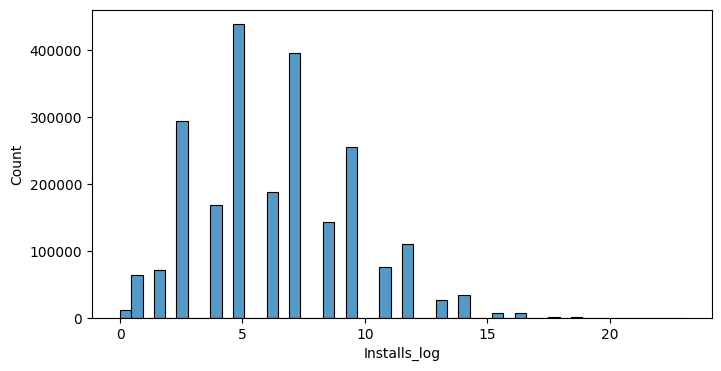

In [92]:
#install 분포 (로그)
plt.figure(figsize=(8,4))
sns.histplot(df, x = 'Installs_log' , bins= 50, stat ='count')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, '0-1K'),
  Text(1, 0, '1K-10K'),
  Text(2, 0, '10K-100K'),
  Text(3, 0, '100K-1M'),
  Text(4, 0, '1M-10M'),
  Text(5, 0, '10M+')])

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

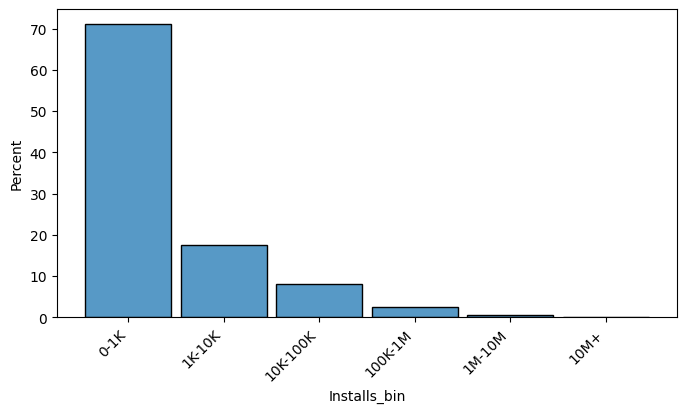

In [93]:
#Installs_bin 비율(%)
plt.figure(figsize=(8,4))
sns.histplot(
    df,
    x="Installs_bin",
    discrete=True,
    stat="percent",
    shrink=0.9
)
plt.xticks(rotation=45, ha="right")

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 18px;"><b>📊 핵심 발견: 앱 시장은 극단적인 롱테일 구조</b></span>
- 대부분(70% 이상)의 앱은 0–1K 다운로드에 집중
- 상위 1% 미만의 앱이 전체 다운로드의 대부분을 차지


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

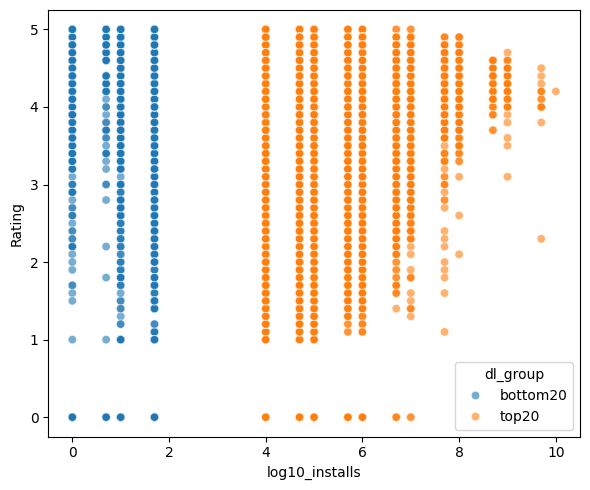

In [94]:
# 상·하위 그룹 특성 확인
df["log10_installs"] = np.log10(df["Installs"].clip(lower=1))

q_low  = df["Installs"].quantile(0.2)
q_high = df["Installs"].quantile(0.8)

df["dl_group"] = "mid"
df.loc[df["Installs"] <= q_low,  "dl_group"] = "bottom20"
df.loc[df["Installs"] >= q_high, "dl_group"] = "top20"

sub = df[df["dl_group"] != "mid"].copy()

plt.figure(figsize=(6,5))
sns.scatterplot(data=sub,x="log10_installs",y="Rating",hue="dl_group",alpha=0.6)
plt.tight_layout()
plt.show()

#### <span style="color: #1976D2; font-family: 'Malgun Gothic'; font-size: 17px;"><b>💡 인사이트</b></span>
설치 수가 많을수록 평점이 일정하게 높고 안정적이며, 설치 수가 적을수록 평점의 분포가 넓고 불안정한 패턴을 보임


---
## 4. 업데이트 주기 & 앱 나이 분석


<Axes: xlabel='app_age_days', ylabel='Count'>

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

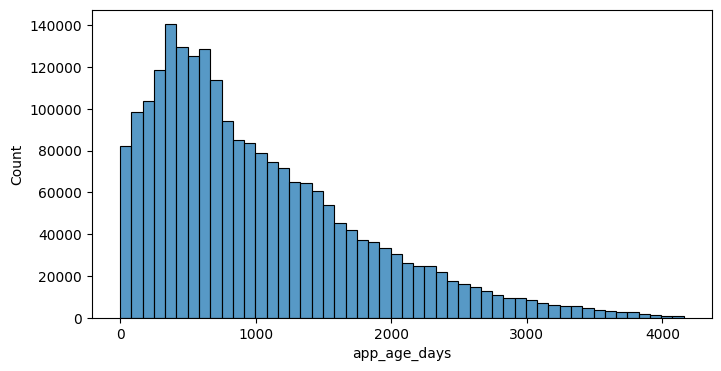

In [95]:
plt.figure(figsize=(8,4))
sns.histplot(df, x = 'app_age_days' , bins= 50, stat ='count')

### 4-1. 앱의 나이(Age) 분석

<span style="font-family: 'Malgun Gothic'; font-size: 15px;">
그래프는 오른쪽으로 긴 꼬리(long tail)를 가진 비대칭 분포(right-skewed distribution)입니다.
</span>

#### 주요 발견
- 대부분의 앱은 비교적 최근에 출시되었음
- 오래된 앱(수천 일 이상)은 점점 적어짐
- 앱의 나이가 약 500~1000일(약 1.5~3년) 근처에서 가장 많음
- 이는 모바일 생태계에서 2~3년 된 앱들이 가장 흔하다는 것을 의미


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

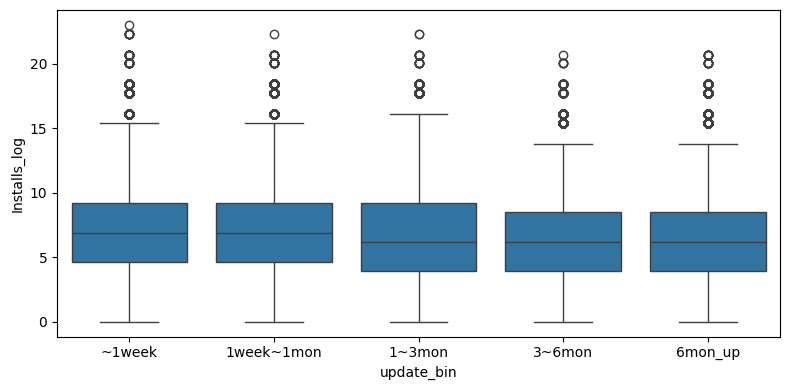

In [96]:
df["update_bin"] = pd.cut(
    df["days_since_update"],
    bins=[0, 7, 30, 90, 180, np.inf],
    labels=["~1week", "1week~1mon", "1~3mon", "3~6mon", "6mon_up"])

plt.figure(figsize=(8,4))
sns.boxplot(df, x="update_bin", y="Installs_log")
plt.tight_layout()
plt.show()

### 4-2. 앱의 업데이트 여부와 설치의 관계 분석

#### 주요 발견
- ~1주, 1주~1개월에 업데이트된 앱들의 설치 수 중앙값이 약간 더 높음
- 3~6개월 이상 업데이트 안 된 앱은 중앙값이 소폭 낮음
- 최근에 관리·업데이트되는 앱이 다소 더 많은 설치를 유지하는 경향
- 그러나 전반적으로 모든 구간의 분포가 비슷하여, 업데이트 시기만으로 설치 수가 극적으로 달라지지는 않음


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

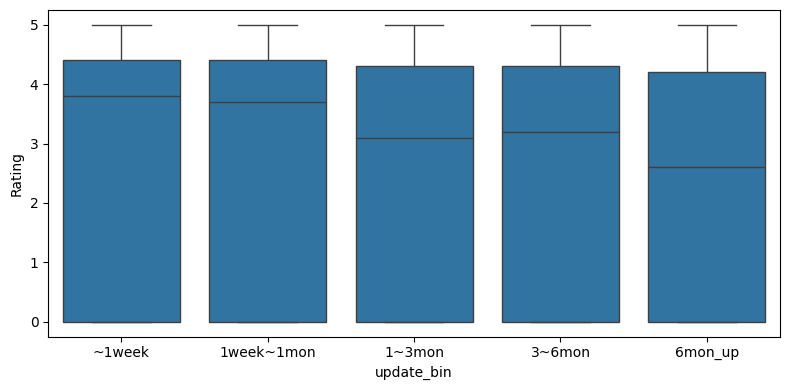

In [97]:
df["update_bin"] = pd.cut(
    df["days_since_update"],
    bins=[0, 7, 30, 90, 180, np.inf],
    labels=["~1week", "1week~1mon", "1~3mon", "3~6mon", "6mon_up"])
plt.figure(figsize=(8,4))
sns.boxplot(df, x="update_bin", y="Rating")
plt.tight_layout()
plt.show()

### 4-3. 업데이트 기간에 따른 평점 분석

#### 주요 발견
- 전반적으로 모든 구간에서 평점 중앙값이 3~4.5 사이로 비슷
- 최근(~1주, 1주~1개월)에 업데이트된 앱들은 중앙값이 약 3.8~4.0 정도로 비교적 높음
- 업데이트가 오래된(3~6개월, 6개월 이상) 앱들은 중앙값이 약 3.0 근처로 살짝 낮아짐
- **업데이트가 오래될수록 평점이 서서히 낮아지는 경향**


### 4-4. 최근 30일 이내 업데이트 여부
<span style="font-family: 'Malgun Gothic'; font-size: 14px;">
※ 전처리: FE용 90일 기준 변수 / EDA: 실험용 30일 기준 변수 사용하고 있어서 이름 덮어쓰지 않도록 추가 생성
</span>


In [98]:
#최근 30일 이내 업데이트
df["recently_updated_30d"] = (df["days_since_update"] <= 30)

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

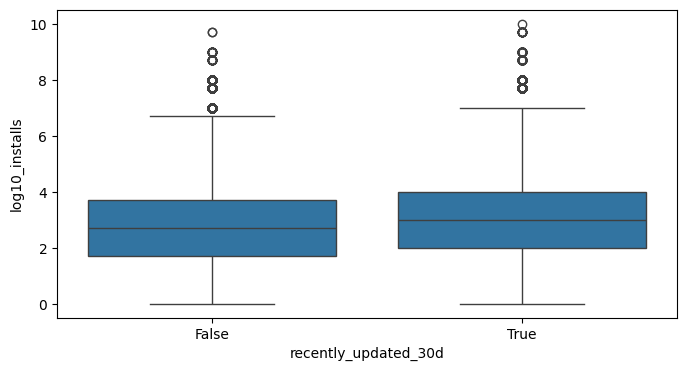

In [99]:
#box plot 비교 롱테일 구조이기 때문에 installs를 로그로 봄
plt.figure(figsize=(8,4))
sns.boxplot(df, x="recently_updated_30d", y="log10_installs")
plt.show()

### 4-5. 앱의 최신 업데이트 여부와 설치의 관계 분석

#### 주요 발견
- True와 False 두 그룹의 분포 형태가 매우 비슷함
- True 그룹의 중앙값이 약간 더 높음
- **최근 업데이트된 앱이 그렇지 않은 앱보다 설치 수가 약간 많다는 경향**
- 두 그룹 모두 일부 설치 수가 매우 높은 앱이 이상치로 존재


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

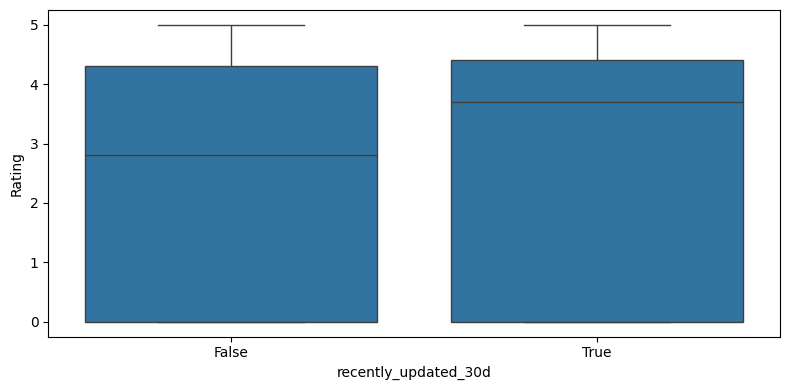

In [100]:
plt.figure(figsize=(8,4))
sns.boxplot(df, x="recently_updated_30d", y="Rating")
plt.tight_layout()
plt.show()

### 4-6. 앱의 최신 업데이트와 평점의 관계

#### 주요 발견
- True의 중앙값: 약 3.6~3.7
- False의 중앙값: 약 2.8
- **최근 업데이트된 앱이 더 높은 평점을 받는 경향**
- 두 그룹 모두 최댓값은 5점, 최솟값은 0점으로 동일
- recently_updated=True쪽의 박스가 약간 위로 올라가 있어 전체적으로 평점이 더 높은 쪽에 분포


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

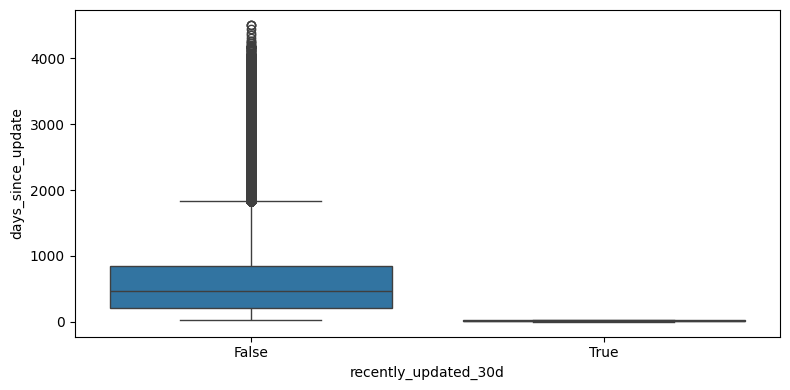

In [101]:
df["recently_updated_30d"] = (df["days_since_update"] <= 30)

plt.figure(figsize=(8,4))
sns.boxplot(df, x="recently_updated_30d", y="days_since_update")
plt.tight_layout()
plt.show()

### 4-7. 카테고리별 업데이트 분석


#### <span style="color: #1976D2; font-family: 'Malgun Gothic'; font-size: 17px;"><b>💡 인사이트</b></span>

- 대부분의 카테고리가 평균 500~1000일(약 1.5~3년) 이내에 업데이트됨
- 카테고리별로 업데이트 주기의 차이가 뚜렷함

**자주 업데이트되는 카테고리**
- "Tools", "Communication", "Finance" → 박스가 낮고 중앙값이 작음

**업데이트가 느린 카테고리**
- "Action", "Arcade", "Casino", "Simulation" 등 게임 관련 카테고리
- 박스가 높고 이상치도 많음 → 오래된 앱이 많음


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

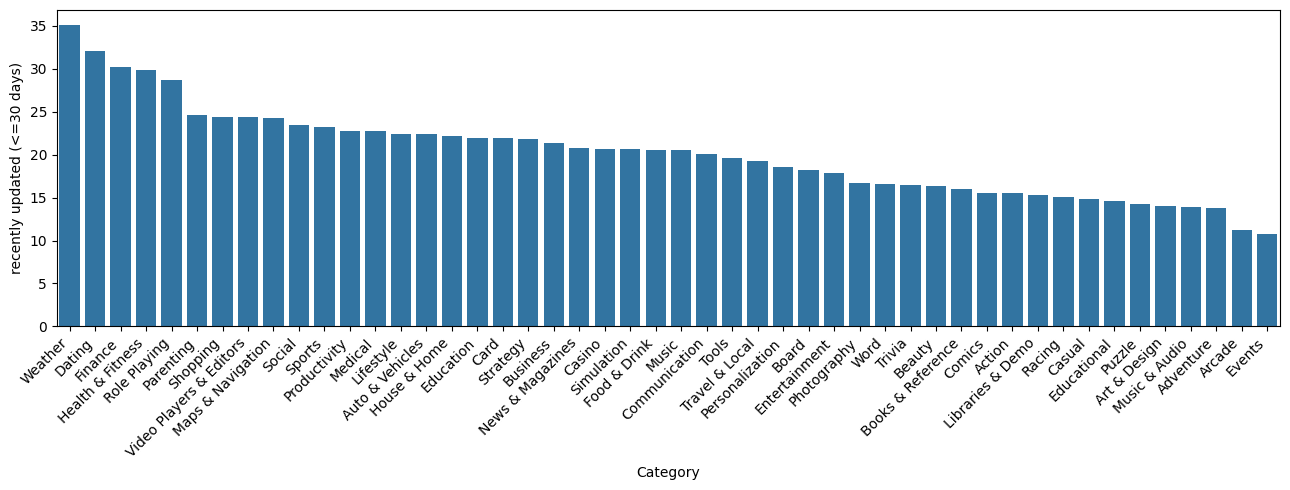

In [102]:
# 카테고리별 recently_updated(최근30일) 비율(%)
plt.figure(figsize=(13,5))
cat_share = (df.groupby("Category")["recently_updated"].mean().sort_values(ascending=False) * 100)
sns.barplot(x=cat_share.index, y=cat_share.values)
plt.ylabel("recently updated (<=30 days)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 4-8. 업데이트 활발도 비교

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 18px;"><b>📊 핵심 발견</b></span>

**업데이트가 활발한 카테고리**
- Weather(약 19%)
- Libraries & Demo, Finance, Dating(약 15~17%)
- 날씨나 금융, 데이팅 앱은 실시간 정보나 기능 유지가 중요하기 때문에 업데이트가 자주 이루어짐

**업데이트가 드문 카테고리**
- Arcade, Casino, Role Playing 등 일부 게임류(5~7%)
- 게임은 완성된 콘텐츠 중심이라 업데이트 주기가 상대적으로 김


---
### 4-9. 테마 3, 4 결론 요약

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 19px;"><b>🔎 테마 3: 다운로드 패턴 – 롱테일 구조 핵심 관찰</b></span>

- **Installs 분포는 전형적인 롱테일(right-skewed) 구조**
  - 대부분의 앱이 **낮은 다운로드 구간(특히 0–1K)** 에 몰려 있음
  - 소수의 앱만이 **수백만·수천만 이상의 다운로드**를 가져가는 구조

- **Installs_bin 기준 비율**
  - 0–1K 구간 앱 비중이 **전체의 절반 이상**을 차지
  - 상위 구간(1M+, 10M+)은 비율은 매우 작지만, **다운로드 수는 압도적으로 큼**

- **상·하위 다운로드 그룹(top 20% vs bottom 20%) 비교**
  - 상위 20% 앱(top20)은 **평점이 상대적으로 높고 안정적**
  - 하위 20% 앱은 **평점 편차가 크고 불안정**

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 19px;"><b>🔎 테마 4: 업데이트 주기 & 앱 나이 핵심 관찰</b></span>

- **앱 나이 분포**
  - 500~1000일(1.5~3년) 근처에서 가장 많음
  - 오래된 앱일수록 점점 감소하는 롱테일 구조

- **업데이트 주기와 성과**
  - 최근 업데이트된 앱이 **설치 수와 평점 모두 높은 경향**
  - 업데이트가 오래될수록 평점 하락

- **카테고리별 차이**
  - Weather, Finance, Dating 등은 업데이트가 활발
  - 게임류는 업데이트가 느림


---

### 🎯 **테마 5: 무료 앱과 유료 앱의 성공 차이** (고명희)
<span style="font-family: 'Malgun Gothic'; font-size: 16px;">
<b>목표:</b> 가격 정책이 앱 성공에 미치는 영향 분석
</span>

#### 분석 내용
- 무료 vs 유료 앱 비율 확인
- 무료 vs 유료 install 평균 및 중앙값 확인
- 무료 vs 유료의 Rating 비교

#### 시각화
- Barplot: 무료 vs 유료 평균 Installs 비교
- Boxplot: 무료 vs 유료의 Installs 분포 비교

---

### ⭐ **테마 6: 유료 앱 내부 가격대 영향 분석** (고명희)
<span style="font-family: 'Malgun Gothic'; font-size: 16px;">
<b>목표:</b> 유료 앱 내에서 가격대가 성과에 미치는 영향 분석
</span>

#### 분석 내용
- 유료 앱만 분리
- 가격(Price_clean) vs Installs 산점도 / 상관관계
- 카테고리별로 무료 vs 유료 차이가 달라지는지 확인
- 카테고리별 Installs 평균 비교

#### 시각화
- 산점도, Heatmap


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

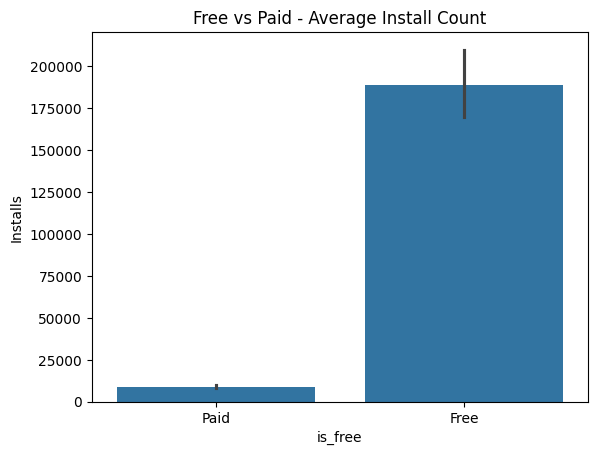

In [103]:
# 1) 집계/비율용은 is_free 사용
free_vs_paid_counts = df['is_free'].value_counts().sort_index()
free_vs_paid_percent = df['is_free'].value_counts(normalize=True).sort_index() * 100

# 2) 그룹 통계도 is_free 기준으로
df.groupby('is_free')['Installs'].describe()

# 3) 시각화도 x축은 is_free 사용
sns.barplot(data=df, x='is_free', y='Installs')
plt.xticks([0, 1], ['Paid', 'Free'])
plt.title("Free vs Paid - Average Install Count")
plt.show()

---
## 5. 무료 앱과 유료 앱의 성공 차이 분석

### 5-1. 무료 vs 유료 앱 다운로드 수 비교

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 18px;"><b>📊 핵심 발견</b></span>

- **Free = 1 (무료 앱) 평균 설치수:** 약 18만 ~ 20만
- **Free = 0 (유료 앱) 평균 설치수:** 약 7천 수준
- 무료 앱 비중이 압도적으로 높음(95% 이상)
- 사용자는 "무료 → 다운로드" 패턴이 일반적
- 유료 앱은 다운로드 수 자체가 매우 작음

#### <span style="color: #1976D2; font-family: 'Malgun Gothic'; font-size: 17px;"><b>💡 인사이트</b></span>

1. 무료 전략은 앱 다운로드에서 압도적 우위를 만듦 (평균 Installs 차이가 극단적)
2. "성공 앱" 대부분이 무료 앱에 속함
3. 하지만 무료 앱의 평점이 유료보다 좋다는 뜻은 아님


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

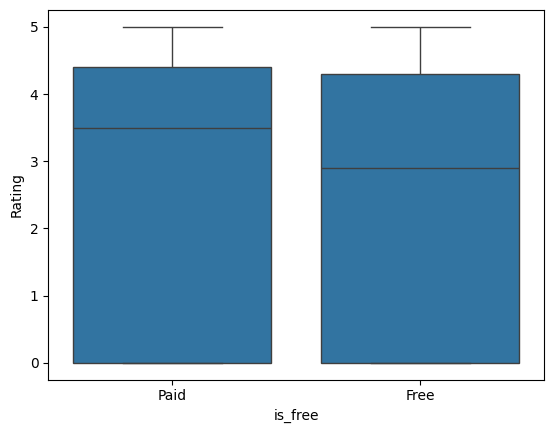

In [104]:
sns.boxplot(data=df, x='is_free', y='Rating')
plt.xticks([0, 1], ['Paid', 'Free'])
...

paid = df[df['is_free'] == 0]
free_only = df[df['is_free'] == 1]

### 5-2. 무료 vs 유료 앱 평점 비교

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 18px;"><b>📊 핵심 발견</b></span>

- **유료 앱 중앙값(Median Rating):** 약 3.5 ~ 3.6
- **무료 앱 중앙값(Median Rating):** 약 2.9 ~ 3.0
- 무료 앱의 평점 분포가 더 넓고 아래쪽으로 퍼져 있음
- 무료 앱은 평점 변동성이 크고 낮은 평점도 많이 존재함


---
## 6. 유료 앱 내부에서 가격대의 영향 분석


In [105]:
paid = df[df['Free'] == 0]

### 6-1. 가격(Price_clean) vs Installs 산점도 / 상관관계


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.


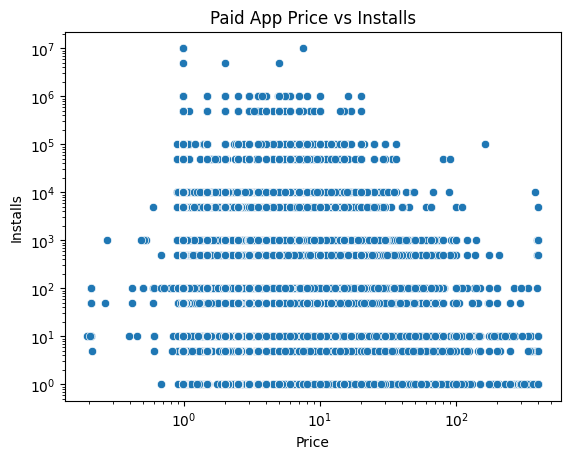

np.float64(-0.0075542706545861735)

In [106]:
sns.scatterplot(data=paid, x='Price', y='Installs')
plt.xscale('log')   # 가격도 스케일 차이가 큼
plt.yscale('log')
plt.title("Paid App Price vs Installs")
plt.show()

paid['Price'].corr(paid['Installs'])


#### <span style="color: #1976D2; font-family: 'Malgun Gothic'; font-size: 17px;"><b>💡 인사이트</b></span>

① **가격이 높아져도 설치수 감소 패턴이 거의 없음 (상관 無)**
- x축(Price)은 0.99 ~ 200달러까지 넓게 퍼져 있는데
- y축(Installs)은 가격이 높아져도 거의 동일 범위에 위치
- 즉, 가격이 높다고 설치수가 꾸준히 줄어드는 모양이 전혀 없음
- 이것이 바로 상관계수 -0.0075가 나오는 이유

② **유료 앱 대부분의 Installs가 극도로 낮음 (1 ~ 100 수준)**
- Installs가 1~100 구간에 매우 많이 몰려 있음
- 즉, 유료 앱은 얼마에 팔든 설치수가 거의 낮은 상태로 유지됨
- 가격 변화가 설치수에 영향 줄 여지가 없음

③ **일부 Installs 높은 앱은 매우 특정 가격 구간에 몰림**
- Installs 10^5 ~ 10^7처럼 높은 앱이 보임


### 6-2. 카테고리별 Installs 평균 비교


In [107]:
category_free_paid = df.groupby(['Category', 'Free'])['Installs'].mean().unstack()
print(category_free_paid)

Free                                0             1
Category                                           
Action                   94036.321368  6.600037e+05
Adventure                21720.759959  2.456557e+05
Arcade                   40748.478318  2.783703e+05
Art & Design              1870.750000  6.112806e+04
Auto & Vehicles           3475.678571  9.003405e+04
Beauty                     851.714286  3.460083e+04
Board                    14675.817680  3.257591e+05
Books & Reference         1463.168474  4.264524e+04
Business                  7007.174107  3.697358e+04
Card                     11538.659574  2.556742e+05
Casino                    3962.657895  2.518322e+05
Casual                   11030.683834  3.457303e+05
Comics                    4413.160714  1.436297e+05
Communication            14956.100642  9.176555e+05
Dating                     202.000000  1.000972e+05
Education                 1747.520171  2.558020e+04
Educational               9305.698543  2.364319e+05
Entertainmen

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

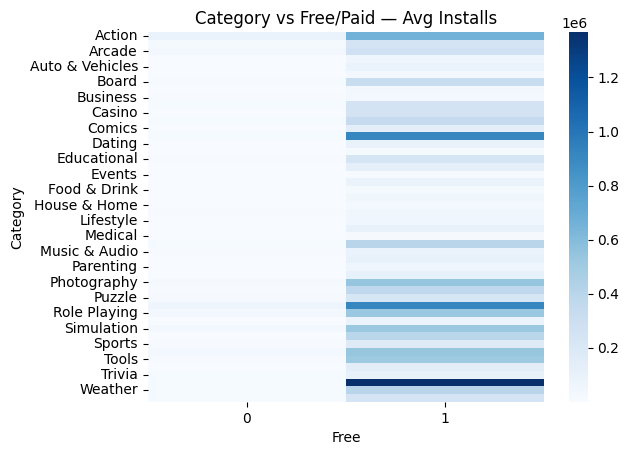

In [108]:
sns.heatmap(category_free_paid, cmap='Blues')
plt.title("Category vs Free/Paid — Avg Installs")
plt.show()

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 18px;"><b>📊 핵심 발견</b></span>

- 거의 모든 카테고리에서 **Free(무료) 앱의 Installs가 Paid(유료)보다 훨씬 높음**
- Heatmap의 오른쪽 열(무료)을 보면 진한 파란색이 훨씬 많음
- 왼쪽 열(유료)은 대부분 아주 연한 색 → 낮은 Installs를 의미
- **전 카테고리 공통: 무료 앱이 다운로드에서 절대적 우위**
- 특히 Weather·Tools·Photography 등 큰 시장을 가진 카테고리에서 무료 전략의 효과가 폭발적
- 무료 전략의 효과는 **"카테고리의 시장 규모"** 에 따라 달라짐


In [109]:
### 카테고리별 무료 및 유료의 인사이트 확인
category_free_paid = df.groupby(['Category', 'Free'])['Installs'].mean().unstack()
print(category_free_paid)

Free                                0             1
Category                                           
Action                   94036.321368  6.600037e+05
Adventure                21720.759959  2.456557e+05
Arcade                   40748.478318  2.783703e+05
Art & Design              1870.750000  6.112806e+04
Auto & Vehicles           3475.678571  9.003405e+04
Beauty                     851.714286  3.460083e+04
Board                    14675.817680  3.257591e+05
Books & Reference         1463.168474  4.264524e+04
Business                  7007.174107  3.697358e+04
Card                     11538.659574  2.556742e+05
Casino                    3962.657895  2.518322e+05
Casual                   11030.683834  3.457303e+05
Comics                    4413.160714  1.436297e+05
Communication            14956.100642  9.176555e+05
Dating                     202.000000  1.000972e+05
Education                 1747.520171  2.558020e+04
Educational               9305.698543  2.364319e+05
Entertainmen

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

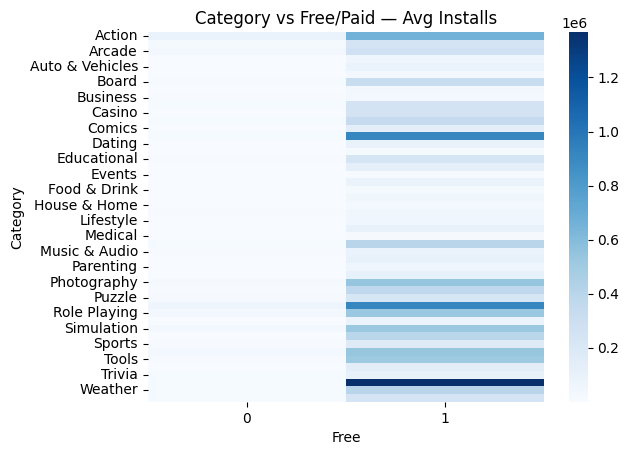

In [110]:
sns.heatmap(category_free_paid, cmap='Blues')
plt.title("Category vs Free/Paid — Avg Installs")
plt.show()

### 6-3. 카테고리별 무료 vs 유료 Heatmap 분석

#### <span style="color: #1976D2; font-family: 'Malgun Gothic'; font-size: 17px;"><b>💡 인사이트</b></span>

- 거의 모든 카테고리에서 무료 앱(Free=1)의 설치 수가 유료 앱(Free=0)보다 압도적으로 높음
- Heatmap 오른쪽(무료)의 색이 전반적으로 훨씬 진함

**특히 시장 규모가 큰 카테고리에서 무료 전략 효과가 폭발적**
- Weather, Tools, Photography, Puzzle
- Action / Arcade (게임류 전반)
- 이 카테고리들은 무료 전략을 쓰면 설치수가 수십~수백 배 증가

**유료 앱의 한계**
- 대부분의 카테고리에서 설치수가 낮아 Heatmap이 거의 흰색에 가까움
- 유료 앱 평균 installs 자체가 매우 낮아, 가격 전략이 시장에서 영향력이 거의 없음

**카테고리별 차이**
- Weather / Tools / Photography에서 무료 효과가 가장 큼


---
### 6-4. 테마 5, 6 결론

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 19px;"><b>🎯 결론</b></span>

**"무료 전략은 전 카테고리에서 설치수를 크게 높이고, 특히 시장 규모가 큰 카테고리에서는 그 효과가 폭발적으로 나타난다."**


---

### 🎯 **테마 7: 광고의 영향 분석** (고명희)
<span style="font-family: 'Malgun Gothic'; font-size: 16px;">
<b>목표:</b> 광고 여부가 평점과 설치수에 미치는 영향 분석
</span>

#### 분석 내용
- 광고 여부 → 평점(Rating)에 미치는 영향
- 광고 여부 → 설치수(Installs)에 미치는 영향


---
## 7. 광고의 영향 확인

### 7-1. 광고 변수 전처리 상태 점검
- 광고 변수의 값 확인 및 전처리 상태 점검
- Ad Supported 컬럼이 0/1로 되어 있는지 확인
- 결측치가 있는지 확인
- 이상한 값이 있는지 확인


In [111]:
df['Ad Supported'].value_counts()
df['Ad Supported'].isnull().sum()

np.int64(0)

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

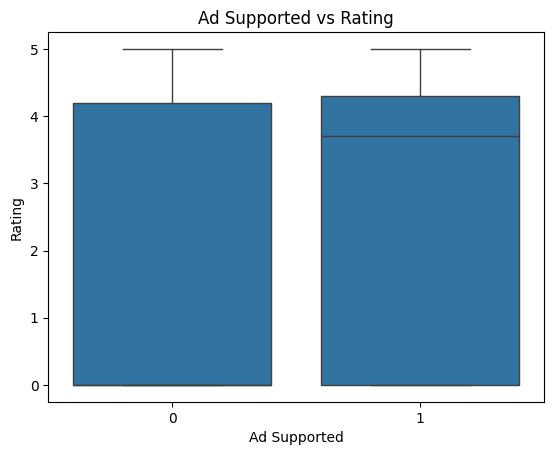

In [112]:
sns.boxplot(data=df, x='Ad Supported', y='Rating')
plt.title("Ad Supported vs Rating")
plt.show()


### 7-2. Ad Supported vs Rating

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 18px;"><b>📊 핵심 발견</b></span>

- **좌측(0 = 광고 없음):** 중앙값(Median Rating) ≈ 4.2
- **우측(1 = 광고 있음):** 중앙값(Median Rating) ≈ 3.7
- **광고가 있는 앱은 광고가 없는 앱보다 평점이 명확하게 더 낮음 (약 0.5점 차이)**


In [113]:
df.groupby('Ad Supported')['Rating'].median()


Ad Supported
0    0.0
1    3.7
Name: Rating, dtype: float64

In [114]:
df[df['Ad Supported']==0]['Rating'].describe()


count    1.146138e+06
mean     1.865423e+00
std      2.097154e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.200000e+00
max      5.000000e+00
Name: Rating, dtype: float64

### 7-3. 광고와 평점의 관계 심층 분석

#### <span style="color: #1976D2; font-family: 'Malgun Gothic'; font-size: 17px;"><b>💡 인사이트</b></span>

- 광고 없는 앱이 평점이 낮거나 평점이 없는 앱이 많아서 평균이 낮아지는 것
- 광고 있는 앱이 상대적으로 평점이 기록된 앱이 많고 평균이 높게 나오는 구조일 가능성


In [115]:
from scipy.stats import ttest_ind

ad_yes = df[df['Ad Supported']==1]['Rating']
ad_no  = df[df['Ad Supported']==0]['Rating']

t_stat, p_val = ttest_ind(ad_yes, ad_no, equal_var=False)
print("p-value:", p_val)

p-value: 0.0


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

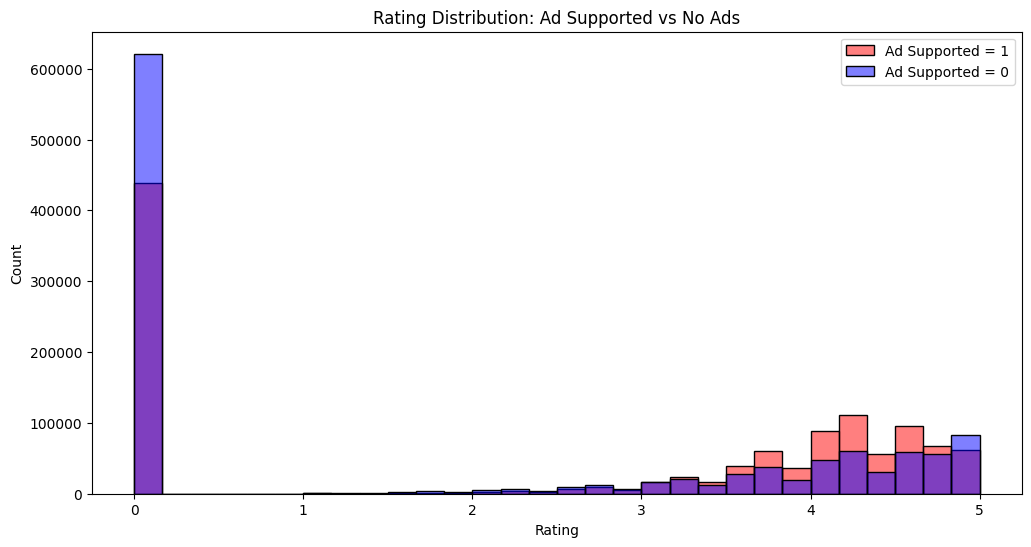

In [116]:


plt.figure(figsize=(12,6))

sns.histplot(data=df[df['Ad Supported']==1], x='Rating', color='red', bins=30, alpha=0.5, label='Ad Supported = 1')
sns.histplot(data=df[df['Ad Supported']==0], x='Rating', color='blue', bins=30, alpha=0.5, label='Ad Supported = 0')

plt.title("Rating Distribution: Ad Supported vs No Ads")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.legend()
plt.show()

### 7-4. 통계적 유의성 검정

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 18px;"><b>📊 핵심 발견</b></span>

- **p-value = 0.0 → 절대적으로 강한 패턴**
- 광고 있음 vs 광고 없음은 평점 분포 자체가 완전히 다르다는 뜻
- 즉, **광고는 평점을 떨어뜨린다는 결론을 "통계적으로 100% 확신"** 할 수 있음

**분포 특징**
- 0점 구간(Rating=0)에 엄청난 데이터 몰림 (평점이 없거나 0으로 기록된 앱이 매우 많음)
- Rating > 3 ~ 5 구간: 빨간색(광고 있는 앱)이 더 많이 분포
- 파란색(광고 없는 앱)은 비교적 적음


### 7-5. 0점을 제외한 시각화


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

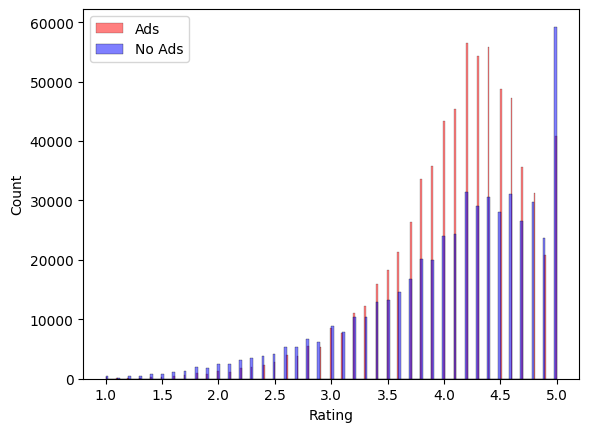

In [117]:
df_clean = df[df['Rating'] > 0]

sns.histplot(df_clean[df_clean['Ad Supported']==1]['Rating'], color='red', label='Ads', alpha=0.5)
sns.histplot(df_clean[df_clean['Ad Supported']==0]['Rating'], color='blue', label='No Ads', alpha=0.5)

plt.legend()
plt.show()

#### <span style="color: #1976D2; font-family: 'Malgun Gothic'; font-size: 17px;"><b>💡 인사이트</b></span>

- 평점 4.0 이하 구간에서는 **광고 있는 앱(빨간색)이 더 많음**
- 저평점 영역(2~3.5)에 광고 포함 앱들이 집중됨
- 평점 4.5~5.0 고평점 구간에서는 **광고 없는 앱(파란색)이 더 많음**
- 특히 4.8~5.0 구간에서는 파란색 막대가 확실히 많음

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 19px;"><b>🎯 결론</b></span>

**"광고 없는 앱이 4~5점의 고평점 영역에서 더 큰 빈도를 가지는 것으로 볼 때, 광고가 사용자 경험의 질을 떨어뜨릴 수 있다."**


---

### 🎯 **테마 8: 인앱결제(IAP)의 영향** (고명희)
<span style="font-family: 'Malgun Gothic'; font-size: 16px;">
<b>목표:</b> 인앱결제 기능이 앱 성과에 미치는 영향 분석
</span>

#### 분석 내용
- IAP 유무에 따른 설치수 비교
- IAP 유무에 따른 평점 비교
- 무료 앱 내에서 IAP 영향 분석


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

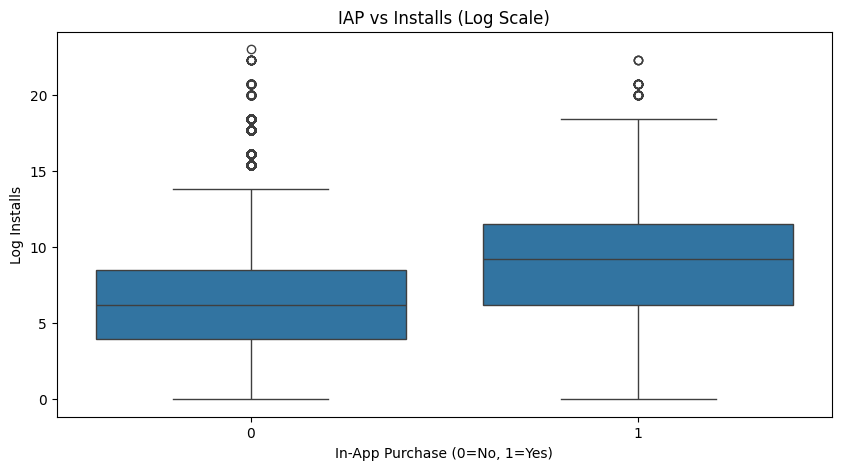


[평균 Installs_log 비교]
In App Purchases
0    5.949062
1    8.749986
Name: Installs_log, dtype: float64

[Installs_log t-test]
t-stat: 339.926433995738
p-value: 0.0


In [118]:
from scipy.stats import ttest_ind
import numpy as np

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='In App Purchases', y='Installs_log')
plt.title("IAP vs Installs (Log Scale)")
plt.xlabel("In-App Purchase (0=No, 1=Yes)")
plt.ylabel("Log Installs")
plt.show()

# 평균 비교
print("\n[평균 Installs_log 비교]")
print(df.groupby("In App Purchases")["Installs_log"].mean())

# t-test
iap_yes = df[df['In App Purchases']==1]['Installs_log']
iap_no  = df[df['In App Purchases']==0]['Installs_log']

t_stat, p_val = ttest_ind(iap_yes, iap_no, equal_var=False)
print("\n[Installs_log t-test]")
print("t-stat:", t_stat)
print("p-value:", p_val)

---
## 8. 인앱결제(IAP)의 영향 확인

### 8-1. IAP vs Installs

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 18px;"><b>📊 핵심 발견</b></span>

- **IAP 있는 앱이 설치 수가 더 높음**
  - 인앱 구매를 넣는다는 것은 보통 개발 규모가 크고 마케팅 투자도 이루어졌다는 뜻

- **IAP 있는 앱이 더 넓은 설치 수 범위를 가짐**
  - IAP = 1의 상단 whisker 범위가 더 넓고, outlier도 더 많이 존재
  - 이는 IAP 앱 내에서 성공 앱과 비성공 앱의 편차가 더 크다는 것을 의미

- **두 그룹 모두 설치 수가 비정상적으로 높은 앱(outliers)이 존재**
  - 하지만 IAP 앱 쪽에 더 많은 고 설치수 outlier가 있음

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 19px;"><b>🎯 결론</b></span>

**"IAP 기능이 있는 앱이 평균적으로 더 많은 설치 수를 가진다. IAP 앱은 설치 수의 분산이 크고, 상위 outlier가 많다."**


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

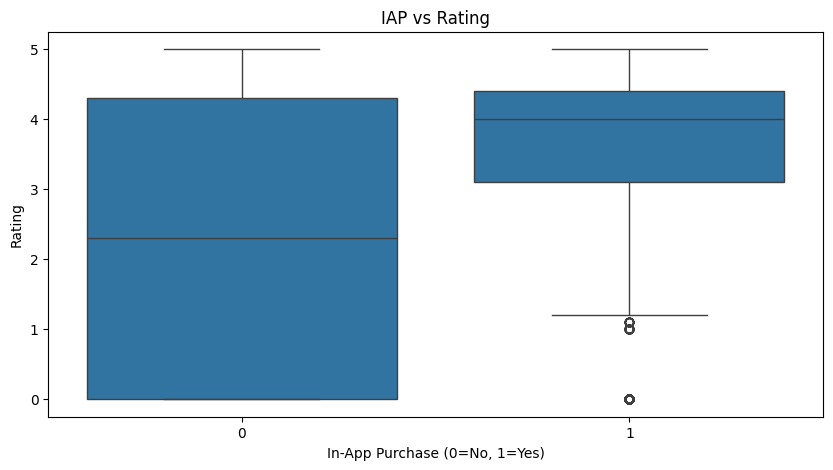


[평균 Rating 비교]
In App Purchases
0    2.104930
1    3.271837
Name: Rating, dtype: float64

[Rating t-test]
t-stat: 281.2975599868743
p-value: 0.0


In [119]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='In App Purchases', y='Rating')
plt.title("IAP vs Rating")
plt.xlabel("In-App Purchase (0=No, 1=Yes)")
plt.ylabel("Rating")
plt.show()

# 평균 비교
print("\n[평균 Rating 비교]")
print(df.groupby("In App Purchases")["Rating"].mean())

# t-test
iap_yes_rating = df[df['In App Purchases']==1]['Rating']
iap_no_rating  = df[df['In App Purchases']==0]['Rating']

t_stat2, p_val2 = ttest_ind(iap_yes_rating, iap_no_rating, equal_var=False)
print("\n[Rating t-test]")
print("t-stat:", t_stat2)
print("p-value:", p_val2)


### 8-2. IAP vs Rating

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 19px;"><b>🎯 결론</b></span>

**"인앱 구매(IAP)가 있는 앱이 없는 앱보다 평점이 훨씬 더 높다. 평점 분포도 더 안정적이고, 낮은 평점이 거의 없음."**


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

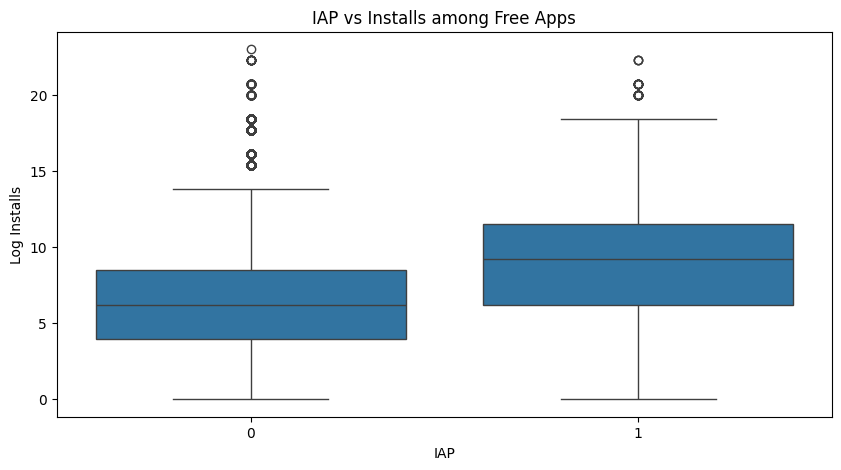


[무료 앱만 – Installs_log 평균차]
In App Purchases
0    5.971612
1    8.767514
Name: Installs_log, dtype: float64

[무료 앱만 – Installs_log t-test]
t-stat: 335.9989050026057
p-value: 0.0


In [120]:
free_only = df[df['Free']==1]      # 무료 앱만 필터링

plt.figure(figsize=(10,5))
sns.boxplot(data=free_only, x='In App Purchases', y='Installs_log')
plt.title("IAP vs Installs among Free Apps")
plt.xlabel("IAP")
plt.ylabel("Log Installs")
plt.show()

print("\n[무료 앱만 – Installs_log 평균차]")
print(free_only.groupby("In App Purchases")["Installs_log"].mean())

free_yes = free_only[free_only['In App Purchases']==1]['Installs_log']
free_no  = free_only[free_only['In App Purchases']==0]['Installs_log']

t_stat3, p_val3 = ttest_ind(free_yes, free_no, equal_var=False)
print("\n[무료 앱만 – Installs_log t-test]")
print("t-stat:", t_stat3)
print("p-value:", p_val3)


### 8-3. 무료 앱 내에서 IAP 영향

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 19px;"><b>🎯 결론</b></span>

**"IAP가 있는 무료 앱이 IAP 없는 무료 앱보다 설치 수가 더 많다."**


---

### 🎯 **테마 9: 앱 사이즈(Size) & 성능 패턴 분석** (고명희)
<span style="font-family: 'Malgun Gothic'; font-size: 16px;">
<b>목표:</b> 앱 사이즈가 다운로드와 평점에 미치는 영향 분석
</span>

#### 분석 내용
- 사이즈와 다운로드 수의 관계
- 사이즈와 평점의 관계
- 카테고리별 사이즈 패턴


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

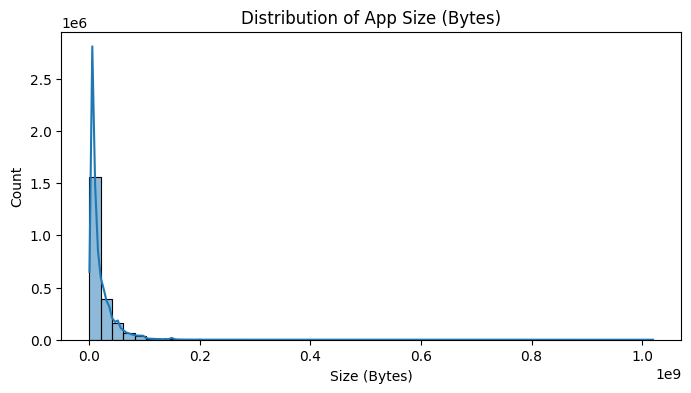

In [121]:
plt.figure(figsize=(8,4))
sns.histplot(df_size['Size_Bytes'], bins=50, kde=True)
plt.title('Distribution of App Size (Bytes)')
plt.xlabel('Size (Bytes)')
plt.ylabel('Count')
plt.show()

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
C:\Users\wjddn\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\wjddn\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io

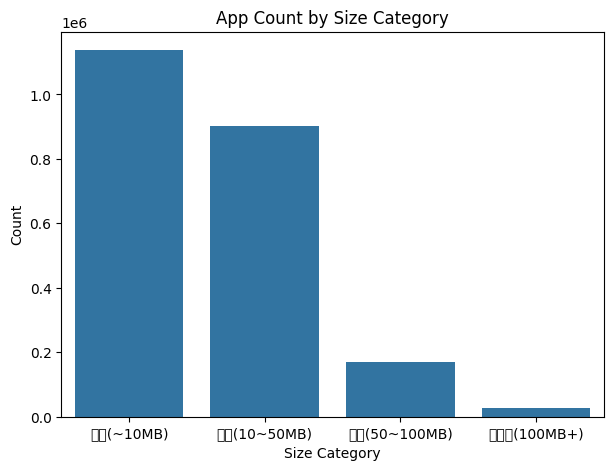

In [122]:
plt.figure(figsize=(7,5))
sns.countplot(
    x='size_category',
    data=df,
    order=['소형(~10MB)', '중형(10~50MB)', '대형(50~100MB)', '초대형(100MB+)']
)
plt.title('App Count by Size Category')
plt.xlabel('Size Category')
plt.ylabel('Count')
plt.show()


---
## 9. 앱 사이즈(Size) & 성능 패턴 분석

### 9-1. 앱 사이즈 분포

#### <span style="color: #1976D2; font-family: 'Malgun Gothic'; font-size: 17px;"><b>💡 인사이트</b></span>

- 앱 시장은 **"가벼운 앱"** 이 압도적으로 많음
- 대형 앱은 상대적으로 적지만 경쟁력이 높음
- 앱 용량은 카테고리와 강하게 연결됨

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 19px;"><b>🎯 결론</b></span>

**"앱스토어의 대부분은 50MB 이하의 소형·중형 앱으로 구성되며, 대형(50MB 이상) 앱은 극소수의 고사양 앱들이 차지한다."**


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

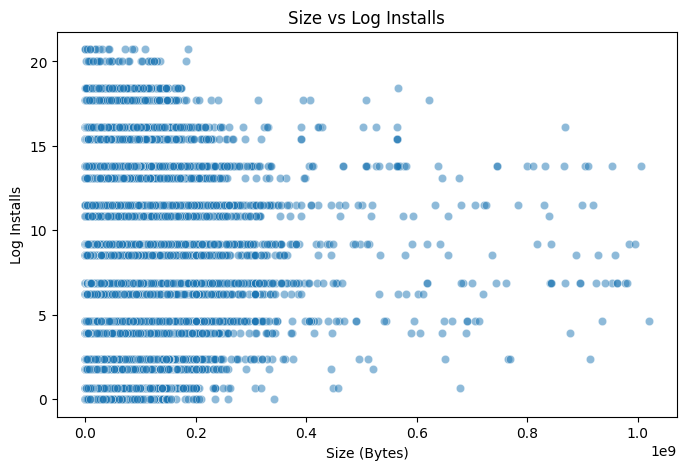

In [123]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Size_Bytes', y='Installs_log', data=df_size, alpha=0.5)
plt.title('Size vs Log Installs')
plt.xlabel('Size (Bytes)')
plt.ylabel('Log Installs')
plt.show()

### 9-2. 앱 사이즈 vs 설치수 관계

#### <span style="color: #1976D2; font-family: 'Malgun Gothic'; font-size: 17px;"><b>💡 인사이트</b></span>

- 설치 수가 높은 앱들은 크기와 무관하게 넓게 퍼져 있음
- 소형(~200MB 이하) 앱이 압도적으로 많음
- 대형 앱(500MB~1GB)의 수는 적지만 설치 수가 무조건 높은 것은 아님
- 전체적으로 산점도가 "구름처럼 넓게 퍼짐" → 상관관계 약함

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 19px;"><b>🎯 결론</b></span>

**"앱 용량은 설치 수와 직접적인 상관관계가 거의 없으며, 대형 앱이든 소형 앱이든 설치 수는 다양한 수준에 걸쳐 분포한다."**


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

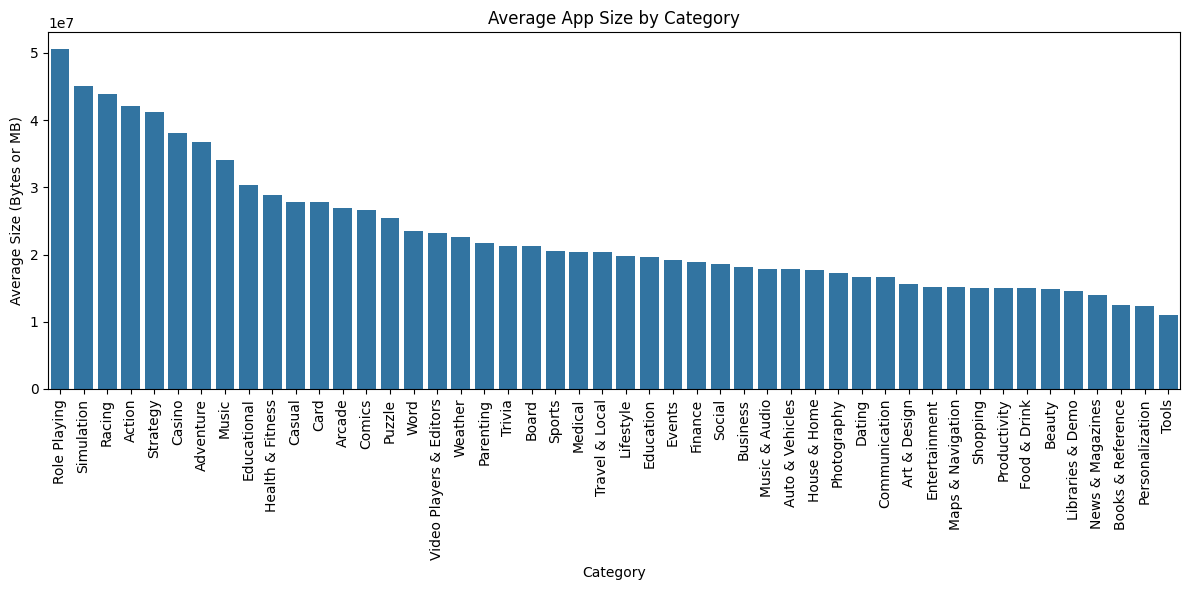

In [124]:


# 카테고리별 평균 사이즈 계산
category_mean_size = df.groupby('Category')['Size_Bytes'].mean().reset_index()

# 정렬 (옵션)
category_mean_size = category_mean_size.sort_values('Size_Bytes', ascending=False)

# 그래프 크기
plt.figure(figsize=(12, 6))

# 바차트
sns.barplot(data=category_mean_size, x='Category', y='Size_Bytes')

plt.xticks(rotation=90)
plt.title('Average App Size by Category')
plt.xlabel('Category')
plt.ylabel('Average Size (Bytes or MB)')
plt.tight_layout()
plt.show()


### 9-3. 카테고리별 평균 앱 사이즈 분석

#### <span style="color: #1976D2; font-family: 'Malgun Gothic'; font-size: 17px;"><b>💡 인사이트</b></span>

**게임 카테고리 = 평균 용량이 가장 큼**
- Action, Adventure, RPG, Racing, Simulation, Sports 등

**기능/유틸리티 앱 = 용량이 가장 작음**
- Tools, Books, Communication, Finance 등

**엔터테인먼트 및 멀티미디어 앱 = 중간 이상**
- Music, Video Editors, Maps 등

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 19px;"><b>🎯 결론</b></span>

**"앱 용량은 카테고리 성격에 의해 결정되며, 특히 게임과 영상·지도 앱이 가장 큰 반면, 유틸리티·텍스트 기반 앱은 가장 가볍다."**


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

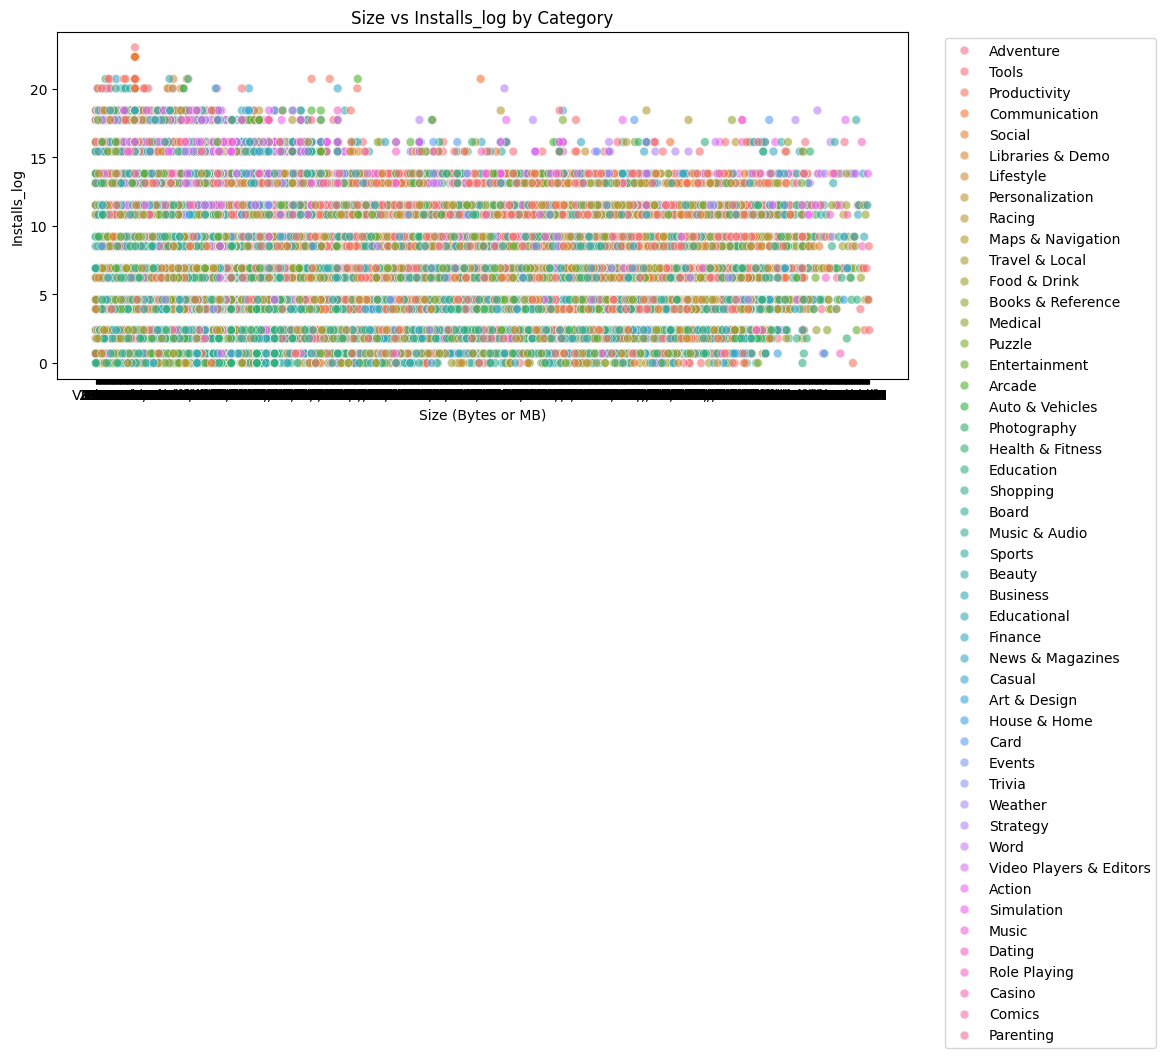

In [125]:


plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='Size',
    y='Installs_log',
    hue='Category',
    alpha=0.6,
    s=40
)

plt.title('Size vs Installs_log by Category')
plt.xlabel('Size (Bytes or MB)')
plt.ylabel('Installs_log')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()


### 9-4. 사이즈와 성공의 관계

#### <span style="color: #1976D2; font-family: 'Malgun Gothic'; font-size: 17px;"><b>💡 인사이트</b></span>

- 앱 크기(Size)는 설치수(Log Installs)와 매우 약한 상관관계만 가짐
- 메가 히트 앱은 특정 카테고리 또는 특정 크기에서만 나오지 않음

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 19px;"><b>🎯 결론</b></span>

**"앱 용량 최적화보다 콘텐츠 품질·기능 개선이 더 중요하다. 메가 히트 앱은 특정 카테고리/특정 크기에서만 나오지 않는다."**


In [126]:
corr_log = df['Size_Bytes'].corr(df['Installs_log'], method='pearson')
print("Size_Bytes vs Installs_log 상관계수:", corr_log)


Size_Bytes vs Installs_log 상관계수: 0.08739787561273517


---
### 9-5. 테마 9 종합 결론

#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 20px;"><b>📌 핵심 결론</b></span>

### **"앱 용량 최적화(사이즈 감소)가 설치수 증가와 직접 연결되지 않는다"**

### **"설치수는 '크기'보다 '앱 가치·기능·평점·카테고리 특성'이 좌우한다"**


In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_category_avg_size(df, category_col='Category', size_col='Size_Bytes'):
    """
    카테고리별 평균 사이즈를 계산하고 바 차트로 시각화하는 함수

    Parameters:
    df : pandas DataFrame
        분석 대상 데이터프레임
    category_col : str
        카테고리 컬럼명 (default: 'Category')
    size_col : str
        앱 크기 컬럼명 (default: 'Size_Bytes')
    """

    # 카테고리별 평균 사이즈 계산
    category_mean = df.groupby(category_col)[size_col].mean().reset_index()

    # 사이즈 큰 순서로 정렬 (선택)
    category_mean = category_mean.sort_values(size_col, ascending=False)

    # 시각화
    plt.figure(figsize=(16, 6))
    sns.barplot(data=category_mean, x=category_col, y=size_col)
    plt.xticks(rotation=90)
    plt.title('Average App Size by Category')
    plt.xlabel('Category')
    plt.ylabel('Average Size (Bytes)')
    plt.tight_layout()
    plt.show()

    return category_mean


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

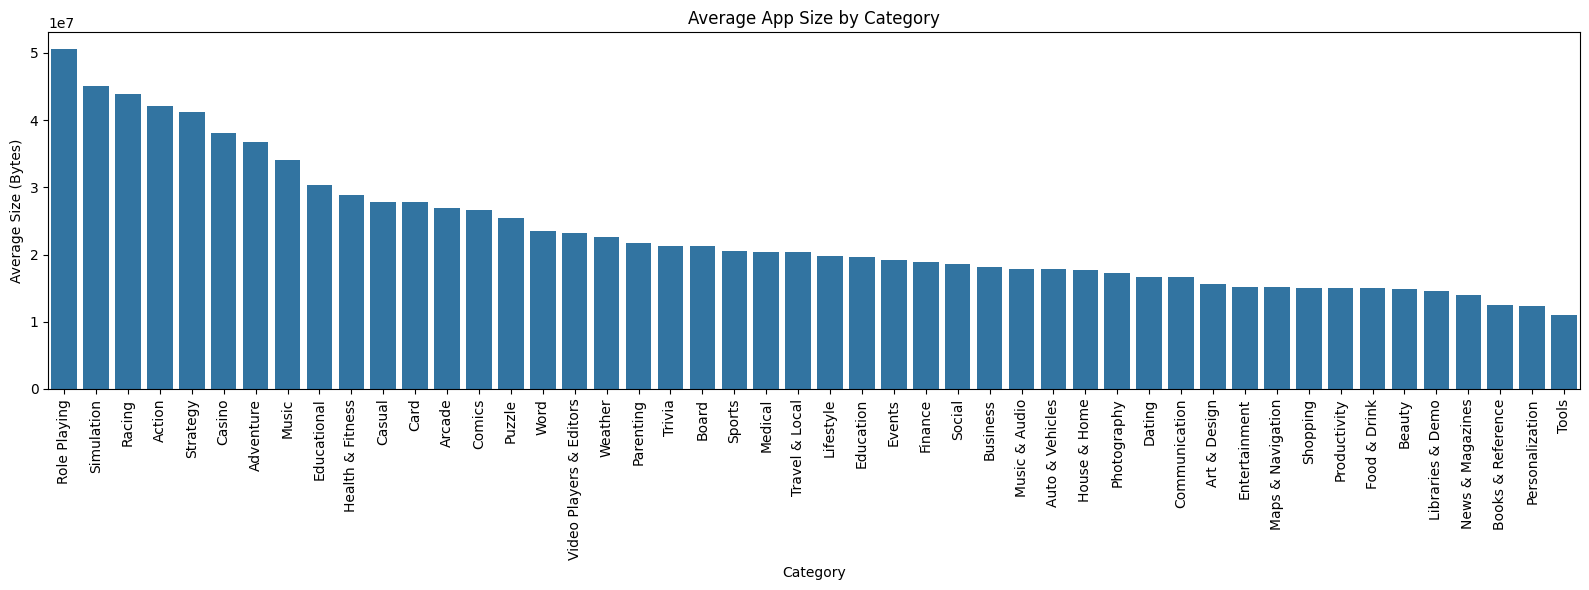

In [128]:
category_size = plot_category_avg_size(df)


#### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 19px;"><b>🎯 추가 결론</b></span>

**"앱 용량은 카테고리 성격이 결정한다. 비슷한 기능·구조를 가진 앱끼리 평균 용량이 비슷함 / 게임류는 큰 용량 / 기능성·텍스트 앱은 작은 용량"**


---
## EDA 테마 5, 6 종합 요약 (고명희)

### 🎯 **테마 5: 무료 vs 유료 앱 비교**

#### 핵심 결과
- 앱 시장의 98% 이상이 무료 앱
- 무료 앱의 평균 다운로드 수가 유료 앱 대비 압도적으로 높음
- 유료 앱은 대부분 다운로드가 극도로 적음 (1~100 수준 다수)

#### 평점 차이
- 유료 앱이 평균 평점·중앙값이 더 높음
- 무료 앱은 사용자 불만이 더 많고 평점 분포가 넓음

#### 핵심 인사이트
- 무료 전략은 다운로드를 폭발적으로 증가시킴
- 유료 전략은 소수의 충성 사용자를 기반으로 높은 평점을 유지

---

### 🎯 **테마 6: 유료 앱 가격, 광고, IAP, 사이즈 영향 분석**

#### 1) 유료 앱 가격(Price) vs Installs
- 가격과 설치수 상관관계 거의 없음
- 가격을 올리거나 낮춰도 설치수엔 큰 영향 없음

#### 2) 광고(Ad Supported) 영향
- 광고 있는 앱이 평점이 낮음 (약 0.5점 차이)
- 광고는 사용자 경험을 저해함

#### 3) IAP(In App Purchases) 영향
- IAP 있는 앱이 설치수와 평점 모두 높음
- 무료 + IAP 조합이 가장 효과적

#### 4) 앱 사이즈(Size) 영향
- 사이즈와 설치수는 상관관계 약함
- 카테고리 특성에 따라 적정 사이즈가 결정됨


---
---


In [129]:
print(df.columns)

Index(['App Name', 'App Id', 'Category', 'Rating', 'Rating Count', 'Installs',
       'Minimum Installs', 'Maximum Installs', 'Free', 'Price', 'Currency',
       'Size', 'Developer Id', 'Developer Website', 'Released', 'Last Updated',
       'Content Rating', 'Privacy Policy', 'Ad Supported', 'In App Purchases',
       'Editors Choice', 'Scraped Time', 'Installs_log', 'Installs_bin',
       'Size_Bytes', 'app_age_days', 'days_since_update', 'Price_clean',
       'is_free', 'has_ads', 'has_iap', 'is_editors_choice',
       'Installs_clipped', 'rating_category', 'size_category',
       'recently_updated', 'engagement_score', 'Rating_구간', '리뷰참여율(%)',
       'log10_installs', 'dl_group', 'update_bin', 'recently_updated_30d'],
      dtype='object')


In [130]:
pd.set_option('display.max_columns', None)

In [131]:
df[df['Size_Bytes'].isna()].head()

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,Currency,Size,Developer Id,Developer Website,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time,Installs_log,Installs_bin,Size_Bytes,app_age_days,days_since_update,Price_clean,is_free,has_ads,has_iap,is_editors_choice,Installs_clipped,rating_category,size_category,recently_updated,engagement_score,Rating_구간,리뷰참여율(%),log10_installs,dl_group,update_bin,recently_updated_30d
136,Grand Robot Lion Transform Simulator,com.grand.robot.fight.lion.tiger.transform.jet...,Travel & Local,4.8,450.0,100000,100000.0,152470,1,0.0,USD,Varies with device,Grand Robot Fight,https://grandrobotfight.blogspot.com/,2020-07-18,2020-12-15,Teen,https://grandrobotfight.travel.blog/privacy-po...,1,1,0,2021-06-15 20:19:43,11.512935,10K-100K,NaN,332.0,182.0,0.0,1,1,1,0,100000,매우높음(4.5~5),NaN,0,0.004500,4.5-5점,0.45,5.00000,top20,6mon_up,False
139,Mega Ramps Car Stunts: Ultimate Races Car Games,com.vg.speed.car.racing.furious.stunts.games,Weather,4.2,149.0,50000,50000.0,84421,1,0.0,USD,Varies with device,Vital Games Production,http://vitalgames.org,2019-07-30,2020-07-16,Everyone,http://vitalgames.org/privacy.html,1,1,0,2021-06-15 20:19:44,10.819798,10K-100K,NaN,686.0,334.0,0.0,1,1,1,0,50000,높음(4~4.5),NaN,0,0.002980,4-4.5점,0.30,4.69897,top20,6mon_up,False
153,Visage Haunted House,com.redmatrix.visage.haunted.house,Adventure,3.5,24.0,1000,1000.0,4820,1,0.0,USD,Varies with device,RedMatrix,NaN,2019-01-30,2021-04-16,Teen,http://redmatrix.raveninteractive.io/privacy.html,1,0,0,2021-06-15 20:19:45,6.908755,0-1K,NaN,867.0,60.0,0.0,1,1,0,0,1000,보통(3~4),NaN,1,0.023976,3-4점,2.40,3.00000,mid,1~3mon,False
179,Shop 13,com.shop1313,Shopping,4.3,18.0,1000,1000.0,2340,1,0.0,USD,Varies with device,Sahar Alizadehetemadi,http://131313.ir/,2019-07-10,2021-06-04,Everyone,http://131313.ir/policies/,0,0,0,2021-06-15 20:19:46,6.908755,0-1K,NaN,706.0,11.0,0.0,1,0,0,0,1000,높음(4~4.5),NaN,1,0.017982,4-4.5점,1.80,3.00000,mid,1week~1mon,True
181,"Swedish Game: Word Game, Vocabulary Game",swedish.funny.game.vocabulary.word,Education,4.4,53.0,10000,10000.0,12927,1,0.0,USD,Varies with device,Fun Word Games Studio,NaN,2017-10-29,2020-09-07,Everyone,http://chinhsachbaomatwordgame.blogspot.com/20...,1,1,0,2021-06-15 20:19:46,9.210440,1K-10K,NaN,1325.0,281.0,0.0,1,1,1,0,10000,높음(4~4.5),NaN,0,0.005299,4-4.5점,0.53,4.00000,top20,6mon_up,False


In [132]:

df1 = df.drop(['Installs','Minimum Installs','Maximum Installs','log10_installs','Installs_bin','Installs_clipped','dl_group',
 'App Name','App Id','Developer Id','Developer Website','Privacy Policy','Scraped Time',
 'Released','Last Updated','rating_category','size_category','Ad Supported','In App Purchases','Editors Choice','Size','engagement_score','리뷰참여율(%)','Free','Rating_구간'],axis=1)

---
## 모델링

### 컬럼 선택 및 전처리

#### 제거할 컬럼 결정
타깃변수를 `Installs_log`로 설정하고, 다음 컬럼들을 제거:
- `Installs`로 결과 값을 낸 컬럼들
- 영향이 없는 e-mail, 웹사이트, 시간
- 고유값인 App Name, App Id, Developer Id 등
- 이미 bool 값으로 있는 중복 컬럼인 Ad Supported, In App Purchases 등
- 같은 의미로 있는 컬럼들과 고유값인 컬럼들은 모델에 방해가 될 것 같아 모두 드롭


### 통화 통일
환율과 통화는 모두 동일하게 통일할 필요가 있어 가장 많은 값을 가진 **USD로 통일**하기로 결정


In [133]:
df1['Currency'].unique()

array(['USD', 'Free', 'CAD', 'EUR', 'INR', 'VND', 'GBP', 'BRL', 'KRW',
       nan, 'TRY', 'SGD', 'AUD', 'ZAR'], dtype=object)

In [134]:
exchange = {
    'USD': 1,
    'EUR': 1.07,
    'INR': 0.0113,
    'GBP': 1.31,
    'CAD': 0.71,
    'VND': 0.000038,
    'BRL': 0.19,
    'KRW': 0.00074,
    'TRY': 0.024,
    'SGD': 0.76,
    'AUD': 0.65,
    'ZAR': 0.058,
    'Free': 1   # Price=0 이므로 환율 1 적용해도 값은 그대로 0됨
}

df1.loc[df1['Currency'] == 'Free', 'Price'] = 0
df1['Price_USD'] = df1['Price'] * df1['Currency'].map(exchange)
df1['Currency'] = 'USD'

In [135]:
#환율 및 통화단위 동일로 변경 후 겹치는 컬럼들과 나머지 필요 없을만한 모델 전부 드랍
df1= df1.drop(['Price','Price_clean','Currency'],axis=1)


In [136]:
df1.head()

,Category,Rating,Rating Count,Content Rating,Installs_log,Size_Bytes,app_age_days,days_since_update,is_free,has_ads,has_iap,is_editors_choice,recently_updated,update_bin,recently_updated_30d,Price_USD
0,Adventure,0.0,0.0,Everyone,2.397895,10000000.0,475.0,475.0,1,0,0,0,0,6mon_up,False,0.0
1,Tools,4.4,64.0,Everyone,8.517393,2900000.0,390.0,40.0,1,1,0,0,1,1~3mon,False,0.0
2,Productivity,0.0,0.0,Everyone,3.931826,3700000.0,676.0,666.0,1,0,0,0,0,6mon_up,False,0.0
3,Communication,5.0,5.0,Everyone,2.397895,1800000.0,1009.0,976.0,1,1,0,0,0,6mon_up,False,0.0
4,Tools,0.0,0.0,Everyone,4.615121,6200000.0,480.0,946.0,1,0,0,0,0,6mon_up,False,0.0


In [137]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290056 entries, 0 to 2290055
Data columns (total 16 columns):
 #   Column                Dtype   
---  ------                -----   
 0   Category              object  
 1   Rating                float64 
 2   Rating Count          float64 
 3   Content Rating        object  
 4   Installs_log          float64 
 5   Size_Bytes            float64 
 6   app_age_days          float64 
 7   days_since_update     float64 
 8   is_free               int64   
 9   has_ads               int64   
 10  has_iap               int64   
 11  is_editors_choice     int64   
 12  recently_updated      int64   
 13  update_bin            category
 14  recently_updated_30d  bool    
 15  Price_USD             float64 
dtypes: bool(1), category(1), float64(7), int64(5), object(2)
memory usage: 249.0+ MB


---
## 자료형 변환

### 자료형 → 숫자형으로 변경


In [138]:
df['recently_updated_30d'] = df1['recently_updated_30d'].astype(int)

In [139]:
#Content Rating도 중요 변수로 사용될 것 같음 값이 그렇게 많지 않기에 하나 씩 바꾸기로 결정
df1['Content Rating'] = df1['Content Rating'].replace({
    'Everyone': 3,
    'Everyone 10+': 10,
    'Teen': 13,
    'Mature 17+': 17,
    'Adults only 18+': 18,
    'Unrated': np.nan
})

C:\Users\wjddn\AppData\Local\Temp\ipykernel_11040\4117980830.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['Content Rating'] = df1['Content Rating'].replace({


In [140]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290056 entries, 0 to 2290055
Data columns (total 16 columns):
 #   Column                Dtype   
---  ------                -----   
 0   Category              object  
 1   Rating                float64 
 2   Rating Count          float64 
 3   Content Rating        float64 
 4   Installs_log          float64 
 5   Size_Bytes            float64 
 6   app_age_days          float64 
 7   days_since_update     float64 
 8   is_free               int64   
 9   has_ads               int64   
 10  has_iap               int64   
 11  is_editors_choice     int64   
 12  recently_updated      int64   
 13  update_bin            category
 14  recently_updated_30d  bool    
 15  Price_USD             float64 
dtypes: bool(1), category(1), float64(8), int64(5), object(1)
memory usage: 249.0+ MB


---
## 범주형 인코딩

### 범주형 인코딩과 카테고리 타깃 인코딩


In [141]:
#update_bin을 원 핫 인코딩
df2 = pd.get_dummies(df1,columns= ['update_bin'])

In [142]:
df2.head()

,Category,Rating,Rating Count,Content Rating,Installs_log,Size_Bytes,app_age_days,days_since_update,is_free,has_ads,has_iap,is_editors_choice,recently_updated,recently_updated_30d,Price_USD,update_bin_~1week,update_bin_1week~1mon,update_bin_1~3mon,update_bin_3~6mon,update_bin_6mon_up
0,Adventure,0.0,0.0,3.0,2.397895,10000000.0,475.0,475.0,1,0,0,0,0,False,0.0,False,False,False,False,True
1,Tools,4.4,64.0,3.0,8.517393,2900000.0,390.0,40.0,1,1,0,0,1,False,0.0,False,False,True,False,False
2,Productivity,0.0,0.0,3.0,3.931826,3700000.0,676.0,666.0,1,0,0,0,0,False,0.0,False,False,False,False,True
3,Communication,5.0,5.0,3.0,2.397895,1800000.0,1009.0,976.0,1,1,0,0,0,False,0.0,False,False,False,False,True
4,Tools,0.0,0.0,3.0,4.615121,6200000.0,480.0,946.0,1,0,0,0,0,False,0.0,False,False,False,False,True


In [143]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290056 entries, 0 to 2290055
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Category               object 
 1   Rating                 float64
 2   Rating Count           float64
 3   Content Rating         float64
 4   Installs_log           float64
 5   Size_Bytes             float64
 6   app_age_days           float64
 7   days_since_update      float64
 8   is_free                int64  
 9   has_ads                int64  
 10  has_iap                int64  
 11  is_editors_choice      int64  
 12  recently_updated       int64  
 13  recently_updated_30d   bool   
 14  Price_USD              float64
 15  update_bin_~1week      bool   
 16  update_bin_1week~1mon  bool   
 17  update_bin_1~3mon      bool   
 18  update_bin_3~6mon      bool   
 19  update_bin_6mon_up     bool   
dtypes: bool(6), float64(8), int64(5), object(1)
memory usage: 257.7+ MB


In [144]:
#카테고리 원 핫인코딩을 사용할지 다른 인코딩을 사용할지 확인
df2['Category'].unique()

array(['Adventure', 'Tools', 'Productivity', 'Communication', 'Social',
       'Libraries & Demo', 'Lifestyle', 'Personalization', 'Racing',
       'Maps & Navigation', 'Travel & Local', 'Food & Drink',
       'Books & Reference', 'Medical', 'Puzzle', 'Entertainment',
       'Arcade', 'Auto & Vehicles', 'Photography', 'Health & Fitness',
       'Education', 'Shopping', 'Board', 'Music & Audio', 'Sports',
       'Beauty', 'Business', 'Educational', 'Finance', 'News & Magazines',
       'Casual', 'Art & Design', 'House & Home', 'Card', 'Events',
       'Trivia', 'Weather', 'Strategy', 'Word', 'Video Players & Editors',
       'Action', 'Simulation', 'Music', 'Dating', 'Role Playing',
       'Casino', 'Comics', 'Parenting'], dtype=object)

### 인코딩 방법 결정
생각보다 고유값이 많은 것을 확인. 원-핫을 하기엔 컬럼 수가 너무 많아질 것 같아 **타깃 인코딩**하기로 결정


In [145]:
from sklearn.model_selection import KFold

In [146]:
def target_encode_oof(train_df, test_df, cat_col, target_col, n_splits=5, alpha=10, random_state=42):
    train = train_df.copy()
    test = test_df.copy()

    global_mean = train[target_col].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_te = pd.Series(index=train.index, dtype=float)

    for tr_idx, val_idx in kf.split(train):
        tr, val = train.iloc[tr_idx], train.iloc[val_idx]

        stats = tr.groupby(cat_col)[target_col].agg(['mean', 'count'])
        smooth = (stats['count'] * stats['mean'] + alpha * global_mean) / (stats['count'] + alpha)

        oof_te.iloc[val_idx] = val[cat_col].map(smooth)

    train[f"{cat_col}_te"] = oof_te.fillna(global_mean)

    # test는 train 전체 통계로 매핑
    stats_full = train.groupby(cat_col)[target_col].agg(['mean', 'count'])
    smooth_full = (stats_full['count'] * stats_full['mean'] + alpha * global_mean) / (stats_full['count'] + alpha)
    test[f"{cat_col}_te"] = test[cat_col].map(smooth_full).fillna(global_mean)

    return train, test

In [147]:
train_te, _ = target_encode_oof(
    df2, df2,               
    cat_col="Category",
    target_col="Installs_log",
    n_splits=5,
    alpha=10
)
X = train_te.drop(columns=["Installs_log", "Category"])
y = train_te["Installs_log"]

In [148]:
#편의를 위해 df3 이라는 이름으로 copy
df3 = train_te.copy()

In [149]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290056 entries, 0 to 2290055
Data columns (total 21 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Category               object 
 1   Rating                 float64
 2   Rating Count           float64
 3   Content Rating         float64
 4   Installs_log           float64
 5   Size_Bytes             float64
 6   app_age_days           float64
 7   days_since_update      float64
 8   is_free                int64  
 9   has_ads                int64  
 10  has_iap                int64  
 11  is_editors_choice      int64  
 12  recently_updated       int64  
 13  recently_updated_30d   bool   
 14  Price_USD              float64
 15  update_bin_~1week      bool   
 16  update_bin_1week~1mon  bool   
 17  update_bin_1~3mon      bool   
 18  update_bin_3~6mon      bool   
 19  update_bin_6mon_up     bool   
 20  Category_te            float64
dtypes: bool(6), float64(9), int64(5), object(1)
memory usa

In [150]:
#인코딩이 끝났으니 기존 Category는 드랍
df3 = df3.drop('Category', axis =1)

In [151]:
#결측치 확인
df3.isna().mean()

Rating                   0.000000
Rating Count             0.002162
Content Rating           0.000067
Installs_log             0.000000
Size_Bytes               0.023170
app_age_days             0.021125
days_since_update        0.000000
is_free                  0.000000
has_ads                  0.000000
has_iap                  0.000000
is_editors_choice        0.000000
recently_updated         0.000000
recently_updated_30d     0.000000
Price_USD                0.000009
update_bin_~1week        0.000000
update_bin_1week~1mon    0.000000
update_bin_1~3mon        0.000000
update_bin_3~6mon        0.000000
update_bin_6mon_up       0.000000
Category_te              0.000000
dtype: float64

In [152]:
#나머지 결측치는 드랍해도 영향이 미미할거라 판단하고 나머지 결측치는 드랍
df3 = df3.dropna()

In [153]:
# bool형 컬럼들 숫자형으로 변경
bool_cols = ['update_bin_~1week','update_bin_1week~1mon','update_bin_1~3mon','update_bin_3~6mon','update_bin_6mon_up']
df3[bool_cols] = df3[bool_cols].astype(int)

In [154]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2185426 entries, 0 to 2290055
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Rating                 float64
 1   Rating Count           float64
 2   Content Rating         float64
 3   Installs_log           float64
 4   Size_Bytes             float64
 5   app_age_days           float64
 6   days_since_update      float64
 7   is_free                int64  
 8   has_ads                int64  
 9   has_iap                int64  
 10  is_editors_choice      int64  
 11  recently_updated       int64  
 12  recently_updated_30d   bool   
 13  Price_USD              float64
 14  update_bin_~1week      int64  
 15  update_bin_1week~1mon  int64  
 16  update_bin_1~3mon      int64  
 17  update_bin_3~6mon      int64  
 18  update_bin_6mon_up     int64  
 19  Category_te            float64
dtypes: bool(1), float64(9), int64(10)
memory usage: 335.6 MB


---
## 모델 학습 및 평가

### RandomForest 모델 사용 예측 / 검증


In [155]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [156]:
X = df3.drop('Installs_log',axis = 1) 
y = df3['Installs_log'] # 타깃변수

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42)

rf = RandomForestRegressor(
    n_estimators= 100,
    max_depth= 16,
    min_samples_split = 20,
    min_samples_leaf = 10,
    max_features="sqrt",
    random_state= 42,
)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,16
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 하이퍼파라미터 설정
200만 행이 넘는 모델이기에 학습하는데 시간이 너무 오래 걸려 수치에 제한을 걸어둠
- `max_depth`
- `min_samples_leaf`
- `min_samples_split`


In [157]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [158]:
pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)


print(f'RMSE:{rmse:.4f}')
print(f'MAE:{mae:.4f}')
print(f'R2:{r2:.4f}')


RMSE:1.3608
MAE:1.0477
R2:0.8084


In [159]:
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae  = mean_absolute_error(y_test, baseline_pred)

print("Baseline RMSE:", baseline_rmse)
print("Model RMSE   :", rmse)
print("Baseline MAE :", baseline_mae)
print("Model MAE    :", mae)

Baseline RMSE: 3.10898217051213
Model RMSE   : 1.3607620663854456
Baseline MAE : 2.5305268348076697
Model MAE    : 1.0476616707558737


In [160]:
fi = pd.Series(rf.feature_importances_, index = X_train.columns)
fi = fi.sort_values(ascending= False)

print(fi.head(20))

Rating Count             0.498541
Rating                   0.347749
app_age_days             0.054598
has_ads                  0.028773
has_iap                  0.020783
Category_te              0.017771
days_since_update        0.011564
Size_Bytes               0.008105
Price_USD                0.002718
is_free                  0.002241
update_bin_6mon_up       0.001658
Content Rating           0.001628
recently_updated         0.001440
recently_updated_30d     0.001242
update_bin_1~3mon        0.000310
update_bin_1week~1mon    0.000301
update_bin_3~6mon        0.000264
update_bin_~1week        0.000169
is_editors_choice        0.000147
dtype: float64


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

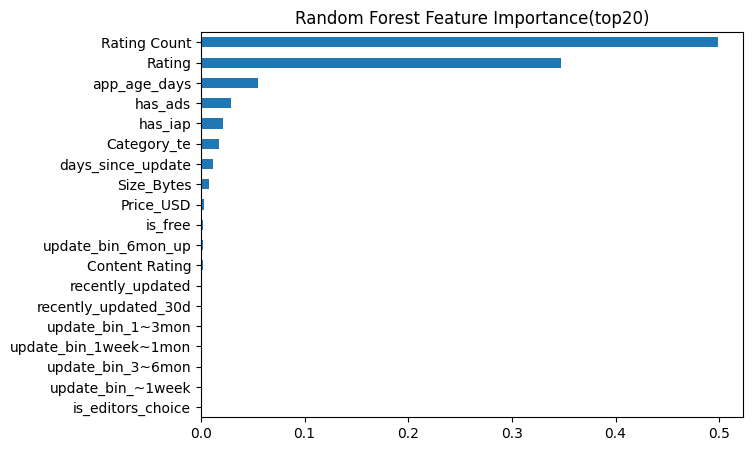

In [161]:
fi.head(20).plot(kind = 'barh', figsize = (7,5))
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance(top20)')
plt.show()

---
## Feature Importance 분석

### 주요 발견
**Rating Count / Rating / app_age_days** 가 가장 높은 연관성을 보임

#### 주의사항
MDI는 연속형/스케일 큰 피처를 과대평가하는 경향이 있음  
→ `permutation_importance`로 다시 한번 확인


In [162]:
from sklearn.inspection import permutation_importance

In [163]:
result = permutation_importance(
    rf, X_test, y_test,
    n_repeats=3,
    random_state= 42,   
)

perm_fi = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)

print(perm_fi.head(20))

Rating Count             0.561181
Rating                   0.223283
app_age_days             0.065721
has_ads                  0.021320
days_since_update        0.016474
Category_te              0.012561
Size_Bytes               0.007262
update_bin_6mon_up       0.003157
Content Rating           0.002811
has_iap                  0.002619
Price_USD                0.002459
is_free                  0.001991
recently_updated         0.001738
recently_updated_30d     0.000698
update_bin_1~3mon        0.000602
update_bin_3~6mon        0.000490
update_bin_1week~1mon    0.000301
update_bin_~1week        0.000158
is_editors_choice        0.000015
dtype: float64


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

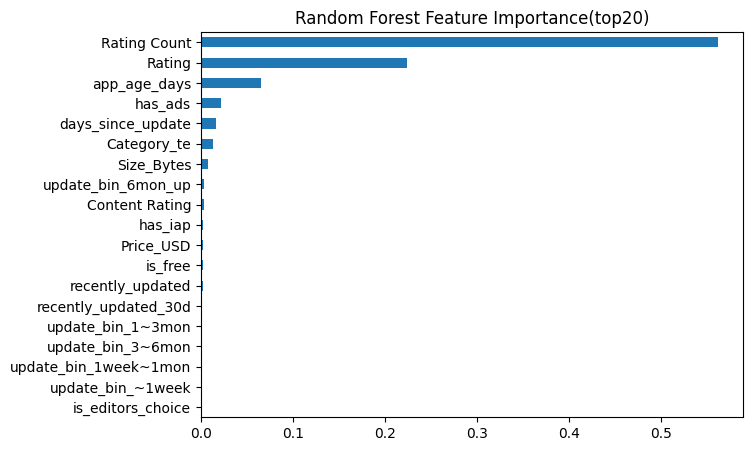

In [164]:
perm_fi.head(20).plot(kind = 'barh', figsize = (7,5))
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance(top20)')
plt.show()

---
## 최종 결론

### <span style="color: #D32F2F; font-family: 'Malgun Gothic'; font-size: 20px;"><b>📌 모델링 핵심 결론</b></span>

결과로 봤을 때 큰 차이가 없음. 분석한 결과 **앱의 다운로드는 리뷰 수와 리뷰 평점이 가장 큰 상관관계**를 가졌다는 결론을 낼 수 있다.

상관관계를 조금 더 직관적으로 보기에는 **heatmap**이 가장 나을 것 같음


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

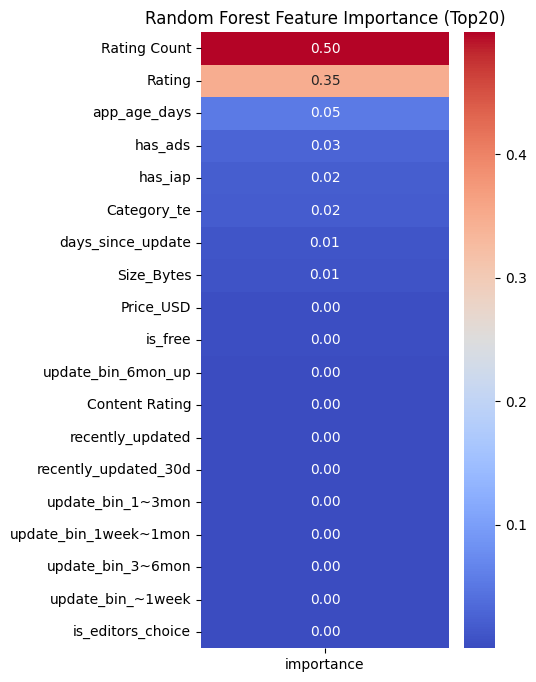

In [175]:
#heatmap 생성
top20 = fi.head(20).sort_values(ascending=False)
# heatmap용 DataFrame(20x1)
heat_df = top20.to_frame(name="importance")
plt.figure(figsize=(4, 8))
sns.heatmap(heat_df,annot=True, fmt=".2f",cmap="coolwarm",cbar=True)
plt.title("Random Forest Feature Importance (Top20)")
plt.ylabel("")
plt.show()